In [1]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import os 

os.chdir("../../../notebooks/ChopTFs/pipeline/")
import time_normalization_helpers

# Reading in data

In [2]:
dbd_norm_activities = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities.csv")
dbd_norm_activities = dbd_norm_activities[["ADseq", "AD_BC", "RPTR_BC", "time", "rep", "shifted_activity"]]
# dbd_norm_activities = dbd_norm_activities.groupby(["ADseq", "rep", "time"])[["shifted_activity"]].agg(["mean", "std"]).reset_index()
# dbd_norm_activities.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in dbd_norm_activities.columns]
# dbd_norm_activities = dbd_norm_activities[dbd_norm_activities["rep_"] == 2]
# dbd_norm_activities = dbd_norm_activities.dropna()
dbd_norm_activities

,ADseq,AD_BC,RPTR_BC,time,rep,shifted_activity
0,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS,GCATATAGAGA,CCTGCTATTCGTAA,10,1,1.798322
1,SNTQAVTGQHRRHSSNLPSASSLQNQRVAAIIQSTGHSIS,CCACAGACGGA,TACCTCCGACTGTC,10,1,-0.573827
2,AEIRGGTRLVCRRENGHQVLQGVSHPPWRSKRSSPPDTPL,CAGACCAAGAA,GTGGTCAAGGCTCG,10,1,-0.103823
3,EVGDFSVNKPPQADDMVMSSRQEKGKQPDVATWDAHSNKG,ATTTGTACTAG,CCATGTTTGGCGAA,10,1,-0.381749
4,LASPHLLLVNVHCHEPMLSLLYTTDQVQNSGSLLPVSSTP,AACGTTCCTCA,ATATAAAGCGATTG,10,1,-0.074264
...,...,...,...,...,...,...
342856,LGPTVSPKDIFNIDSVPPSTSLTNLTTPGSTYLDTPDDSF,CCCCCTCACGC,CCCTGCCCCGTTAG,15,1,1.533722
342857,SGSTRTVSPKDIFADAFGSAPPSAAFTNLTSPDIDASPFL,AATTGAGCAAA,TTCTTCGTACCTAA,15,1,6.393534
342858,QQTPSVAKMSIAELDDFTGFEGGASTAYSSPGAPAVFDVP,GAAGAATCTGA,TCTACAGATAAGTT,15,1,2.920016
342859,RFNSIAQNQSQHQQFYAPLSTSSSAAVVNQQTRIARPPIP,AGAATCAGTAA,TGAGAGCGAGGCGA,15,1,2.920016


In [3]:
def filter_df(df):
    # at least 2 tech reps per ADseq, AD_BC, RPTR_BC, time
    n_reps = df.groupby(["ADseq", "AD_BC", "RPTR_BC", "time"])["rep"].transform("nunique")
    df = df[n_reps >= 2]

    # at least 3 unique AD_BC + RPTR_BC combos per ADseq, time
    # drop_duplicates first, then count, then filter ADseqs that qualify
    combos = (
        df[["ADseq", "AD_BC", "RPTR_BC", "time"]]
        .drop_duplicates()
        .groupby(["ADseq", "time"])
        .size()
        .rename("n_combos")
        .reset_index()
    )
    valid = combos[combos["n_combos"] >= 2][["ADseq", "time"]]
    df = df.merge(valid, on=["ADseq", "time"])

    return df

In [4]:
len(dbd_norm_activities[dbd_norm_activities["time"] <=30]["ADseq"].unique())

11272

In [5]:
df_filtered = filter_df(dbd_norm_activities)
df_filtered

,ADseq,AD_BC,RPTR_BC,time,rep,shifted_activity
0,AAVDLNFEAAIPSSRARSHTAATIPPLDFSVFTTDSLQQS,GCATATAGAGA,CCTGCTATTCGTAA,10,1,1.798322
1,SNTQAVTGQHRRHSSNLPSASSLQNQRVAAIIQSTGHSIS,CCACAGACGGA,TACCTCCGACTGTC,10,1,-0.573827
2,DDSPTGLDTPLFGVDDAALDDWTPLFSSEEQMDFAANQPA,TAGGCCGGAAG,GAGGCTACTCTCGC,10,1,4.244856
3,FPRRHSVNQQQQLPTSQVPRVPRLNTQPTGYHLSTTLRSS,TTCCTATTGTT,GGAGGACTGGTGCG,10,1,0.224387
4,VSASVSPASSSVGPESLGGMDVNPLKRPRDGSESPSFENK,GACTATGAATA,AGAACCTAGTTTGG,10,1,2.300641
...,...,...,...,...,...,...
194458,ATTNLASPQSLFDSPSESYDTSPLFNGDDVSSDGPWFSLF,GCCCTCTTTGT,TGTTGATCTTATGC,15,1,5.660856
194459,LGPTVSPKDIFNIDSVPPSTSLTNLTTPGSTYLDTPDDSF,CCCCCTCACGC,CCCTGCCCCGTTAG,15,1,1.533722
194460,SGSTRTVSPKDIFADAFGSAPPSAAFTNLTSPDIDASPFL,AATTGAGCAAA,TTCTTCGTACCTAA,15,1,6.393534
194461,RFNSIAQNQSQHQQFYAPLSTSSSAAVVNQQTRIARPPIP,AGAATCAGTAA,TGAGAGCGAGGCGA,15,1,2.920016


In [6]:
len(df_filtered[df_filtered["time"] <=30]["ADseq"].unique())

4042

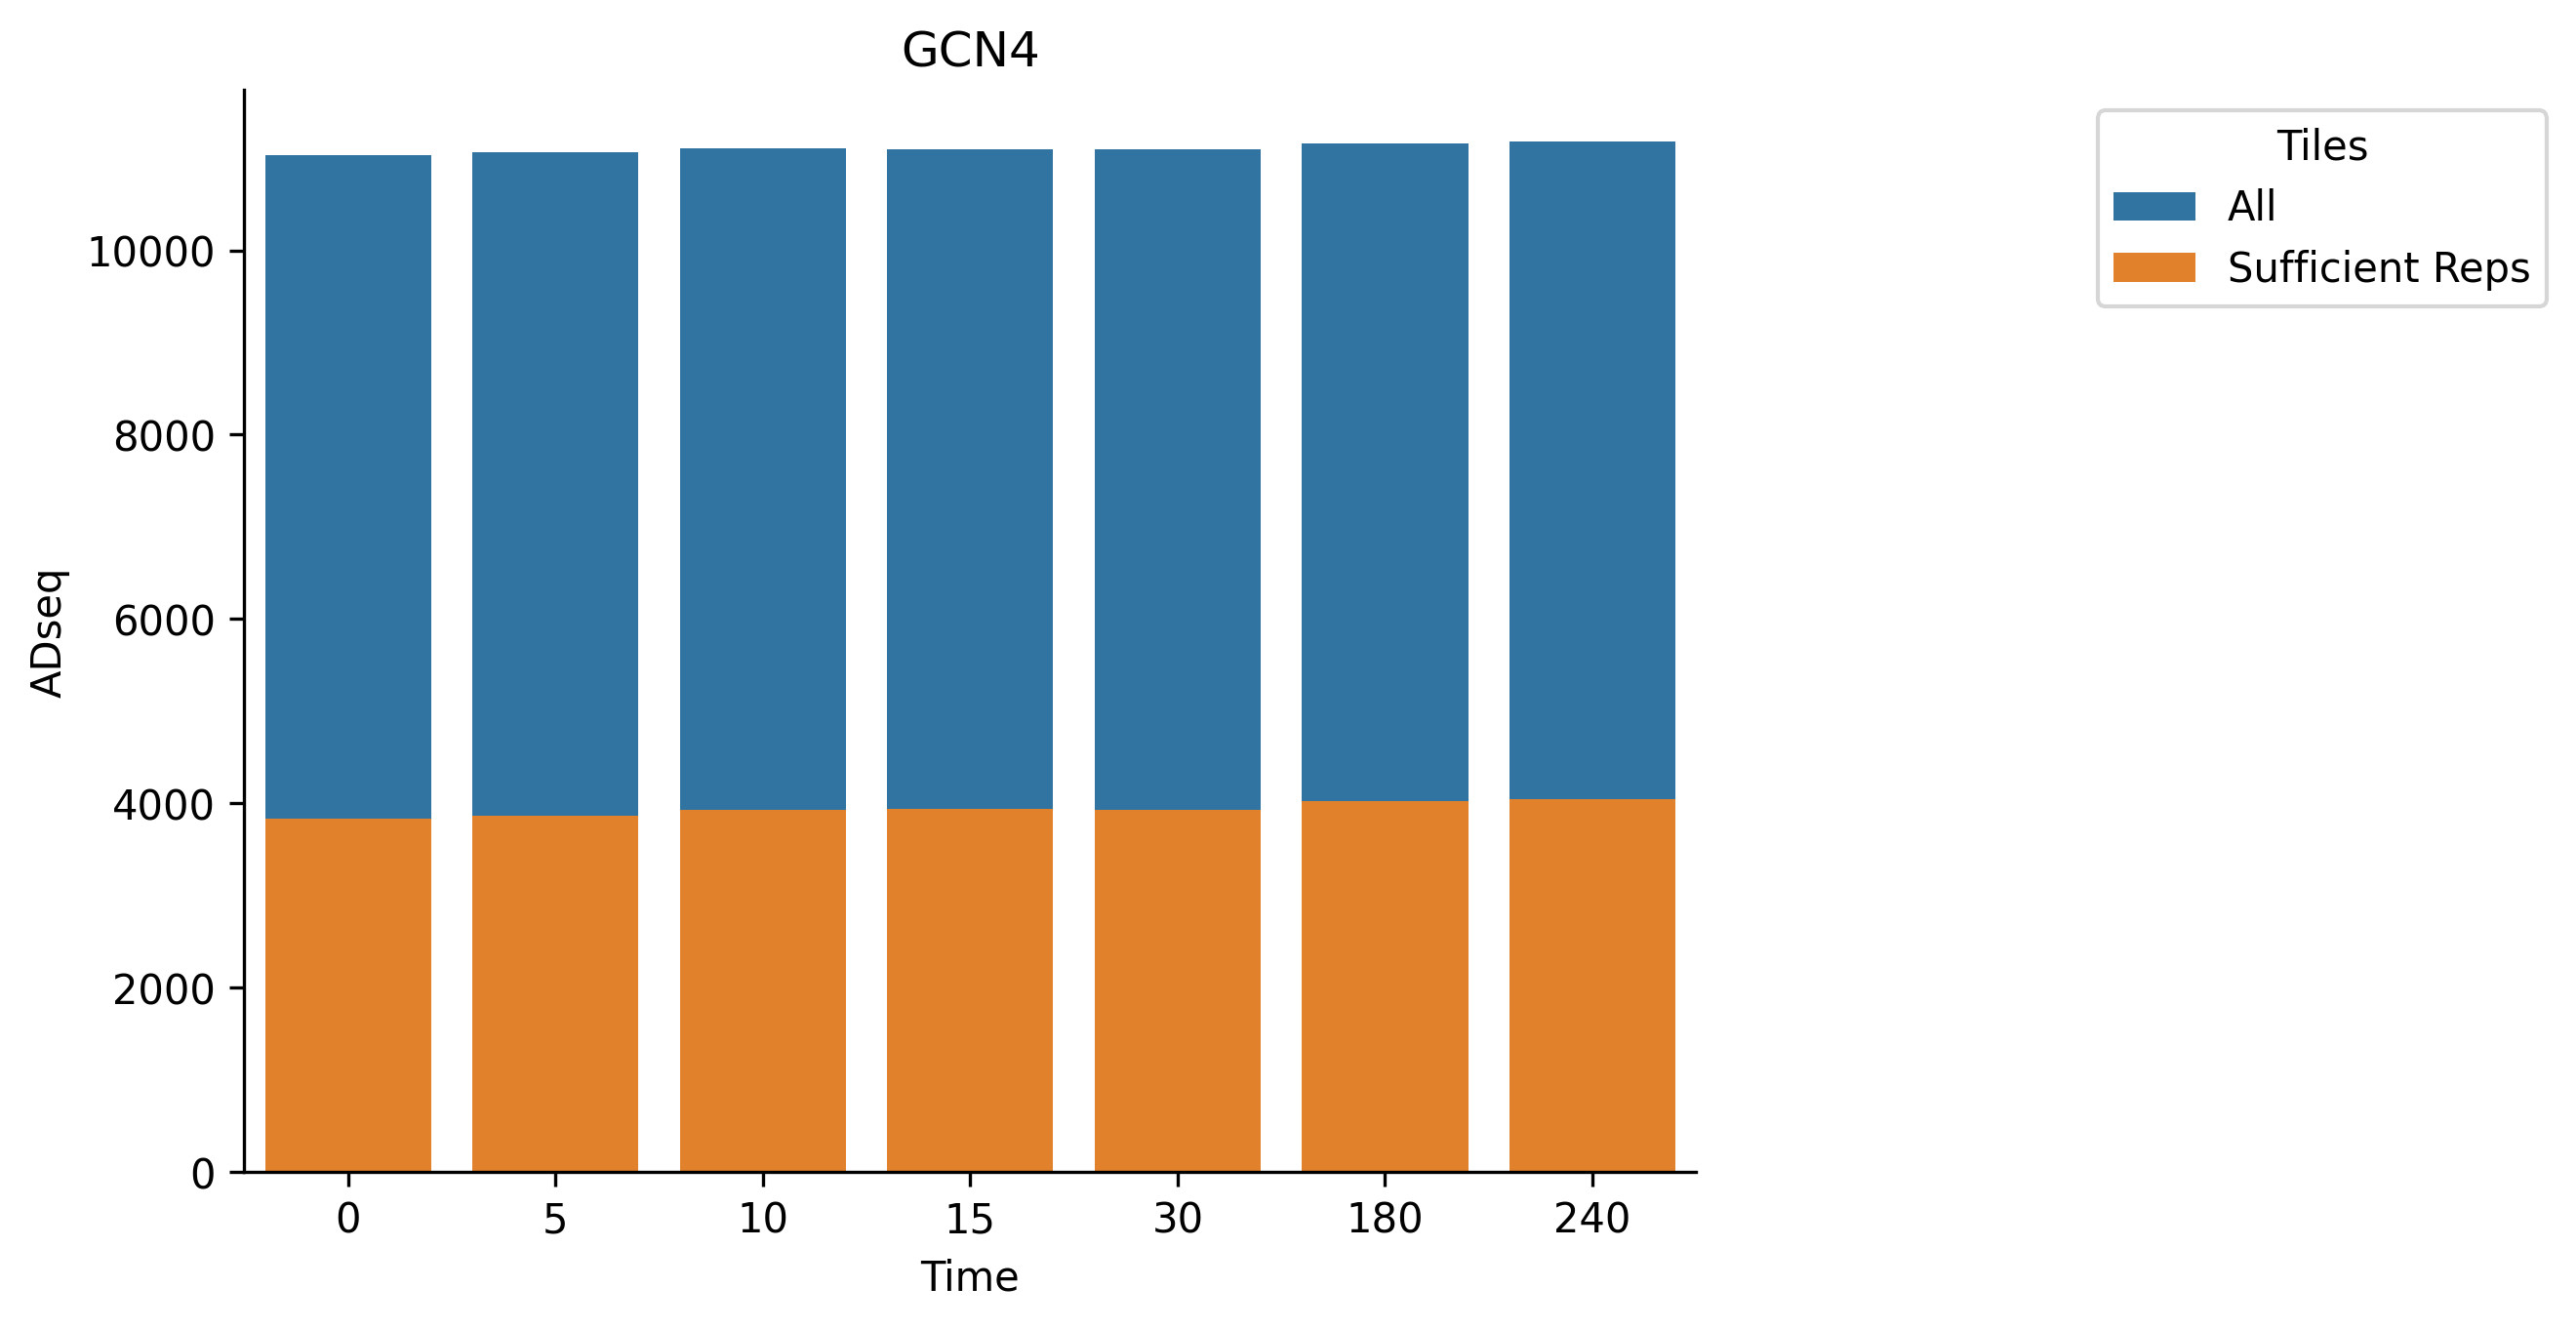

In [7]:
plt.figure(dpi = 300)
sns.barplot(data = dbd_norm_activities[["ADseq", "time"]].drop_duplicates().groupby(["time"]).count().reset_index(), x = "time", y = "ADseq", label = "All")
sns.barplot(data = df_filtered[["ADseq", "time"]].drop_duplicates().groupby(["time"]).count().reset_index(), x = "time", y = "ADseq", label = "Sufficient Reps")
plt.legend(loc = 'upper right', bbox_to_anchor = (1.6,1), title = "Tiles")
plt.title("GCN4")
plt.xlabel("Time")
sns.despine()

In [8]:
df_filtered[["ADseq", "time"]].groupby(["time"]).count().reset_index()

,time,ADseq
0,0,26650
1,5,27149
2,10,27660
3,15,27752
4,30,27716
5,180,28674
6,240,28862


In [9]:
# how much dropout per AD across timepoints?
df_filtered["barcode"] = df_filtered["AD_BC"].astype(str) + "||" + df_filtered["RPTR_BC"].astype(str)

dropout = (
    df_filtered.groupby(["ADseq", "time"])["barcode"]
    .nunique()
    .unstack("time")
)
dropout.div(dropout[0], axis=0).describe()  # fraction retained vs t=0

time,0,5,10,15,30,180,240
count,3830.0,3744.000000,3772.000000,3775.000000,3767.000000,3809.000000,3812.000000
mean,1.0,1.006468,1.007830,1.007991,1.010371,1.016912,1.018778
std,0.0,0.078220,0.079453,0.081399,0.086445,0.095543,0.098412
min,1.0,0.666667,0.500000,0.500000,0.666667,0.666667,0.666667
25%,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.0,2.000000,1.666667,2.000000,2.000000,2.000000,2.000000


# Bootstrapping

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm

def _bootstrap_one_ad(ad, ad_df, n_boot, seed, plot=False):
    rng = np.random.default_rng(seed)
    times = np.sort(ad_df["time"].unique())
    ad_df = ad_df.copy()
    ad_df["barcode"] = ad_df["AD_BC"].astype(str) + "||" + ad_df["RPTR_BC"].astype(str)

    bc_mats = []
    n_reps_list = []
    max_reps = 0
    for bc, g in ad_df.groupby("barcode"):
        pivot = g.pivot_table(
            index="rep",
            columns="time",
            values="shifted_activity",
            aggfunc="mean"
        ).reindex(columns=times)
        pivot = pivot.dropna(how="all")
        if pivot.shape[0] == 0:
            continue
        arr = pivot.to_numpy(dtype=np.float32)
        bc_mats.append(arr)
        n_reps = arr.shape[0]
        n_reps_list.append(n_reps)
        max_reps = max(max_reps, n_reps)

    if len(bc_mats) < 2:
        return None

    n_bcs = len(bc_mats)
    n_times = len(times)

    data = np.full((n_bcs, max_reps, n_times), np.nan, dtype=np.float32)
    for i, arr in enumerate(bc_mats):
        data[i, :arr.shape[0], :] = arr
    n_reps_arr = np.array(n_reps_list)

    bc_means_true = np.nanmean(data, axis=1)
    true_means = np.nanmean(bc_means_true, axis=0)

    # --- VECTORIZED FIXED BOOTSTRAP ---
    bc_idx = rng.integers(0, n_bcs, size=(n_boot, n_bcs))
    raw = rng.random(size=(n_boot, n_bcs, max_reps))
    n_reps_drawn = n_reps_arr[bc_idx]
    rep_idx = (raw * n_reps_drawn[:, :, None]).astype(np.int32)
    sampled = data[bc_idx[:, :, None], rep_idx]
    bc_means = np.nanmean(sampled, axis=2)
    boot_vals = np.nanmean(bc_means, axis=1)
    # --- END BOOTSTRAP ---

    if plot:
        sns.set_style("ticks")
        sns.set_context("talk")

        n_cols = 1
        n_rows = int(np.ceil(len(times) / n_cols))

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(15 * n_cols, 1.5 * n_rows),
            dpi=300,
            sharey=True,
            sharex=True
        )
        axes = np.array(axes).flatten()

        palette = sns.color_palette("tab10", n_colors=n_bcs)
        bc_color = dict(zip(range(n_bcs), palette))

        rep_vals = sorted(ad_df["rep"].unique())
        shapes = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
        rep_marker = {r: shapes[i % len(shapes)] for i, r in enumerate(rep_vals)}

        from matplotlib.lines import Line2D

        bc_handles = [
            Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=palette[i], markersize=8,
                   label=f"bc {i}")
            for i in range(min(n_bcs, 10))
        ]
        rep_handles = [
            Line2D([0], [0], marker=rep_marker[r], color='black',
                   linestyle='None', markersize=8, label=f"rep {r}")
            for r in rep_vals
        ]

        for ti, t in enumerate(times):
            ax = axes[ti]
            vals = boot_vals[:, ti]

            # bootstrap distribution
            sns.histplot(
                vals,
                bins=40,
                stat="density",
                alpha=0.5,
                ax=ax,
                element="step",
                color="gray"
            )

            # raw data points — fixed: use bc_mats directly, single loop
            for bc_i in range(n_bcs):
                bc_data = bc_mats[bc_i]          # (n_reps, n_times) array
                t_idx = np.where(times == t)[0][0]

                for rep_i in range(bc_data.shape[0]):
                    val = bc_data[rep_i, t_idx]
                    if np.isnan(val):
                        continue

                    rep_label = rep_vals[rep_i] if rep_i < len(rep_vals) else rep_i
                    y_jitter = 3 + rng.normal(0, 0.5)

                    ax.scatter(
                        val,
                        y_jitter,
                        edgecolors=bc_color[bc_i],
                        facecolors="none",
                        marker=rep_marker.get(rep_label, "o"),
                        alpha=0.8,
                        s=100,
                        linewidths=2
                    )

            tm = true_means[ti]
            bm = np.nanmean(vals)

            if not np.isnan(tm):
                ax.axvline(tm, linestyle="--", linewidth=2, color="C0", label="true mean")
            if not np.isnan(bm):
                ax.axvline(bm, linestyle=":", linewidth=2, color="black", label="boot mean")

            ax.set_title(f"t={t}", x=0.05, y=0.5)
            ax.set_ylabel("")

        for j in range(len(times), len(axes)):
            fig.delaxes(axes[j])

        fig.legend(
            handles=bc_handles + rep_handles,
            loc="upper right",
            bbox_to_anchor=(1.2, 1),
            ncols=1
        )

        plt.suptitle(f"AD: {ad}", y=1.01)
        fig.supylabel("Density", x=-0.01)
        fig.supxlabel("Activity", y=-0.001)

        sns.despine()
        plt.tight_layout(pad=0)
        plt.show()

    out = []
    for ti, t in enumerate(times):
        vals = boot_vals[:, ti]
        # in _bootstrap_one_ad, add to each out dict:
        out.append({
            "ADseq": ad,
            "time": t,
            "mean": np.nanmean(vals),
            "ci_low": np.nanquantile(vals, 0.025),
            "ci_hi": np.nanquantile(vals, 0.975),
            "boot_samples": vals.copy(),
            "n_barcodes": n_bcs,  # add this
        })
    return pd.DataFrame(out)
    
def bootstrap_full_hierarchical_parallel(df, n_boot=1000, seed=42, n_jobs=-1):

    ad_groups = list(df.groupby("ADseq"))
    rng = np.random.default_rng(seed)

    seeds = rng.integers(0, 1e9, size=len(ad_groups))

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_bootstrap_one_ad)(ad, ad_df, n_boot, int(s))
        for (ad, ad_df), s in tqdm(zip(ad_groups, seeds), total=len(ad_groups))
    )

    results = [r for r in results if r is not None]

    return pd.concat(results, ignore_index=True)

In [11]:
summary = bootstrap_full_hierarchical_parallel(df_filtered, n_boot=10000)
summary

  0%|          | 0/4089 [00:00<?, ?it/s]/global/home/users/sanjanakotha/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/global/home/users/sanjanakotha/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/global/home/users/sanjanakotha/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/global/home/users/sanjanakotha/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarni

,ADseq,time,mean,ci_low,ci_hi,boot_samples,n_barcodes
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,"[-0.2008878, -0.015304606, -0.32382935, -0.120...",2
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,"[0.20202915, 0.17487152, 0.38542524, 0.2113351...",2
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,"[0.54796124, 0.59519506, 0.5511138, 0.62744856...",2
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,"[0.3063501, 0.45152777, 0.6874338, 0.39934307,...",2
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,"[0.5196667, 0.44921988, 1.1465678, 0.4846542, ...",2
...,...,...,...,...,...,...,...
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,0.009890,-0.883891,0.659086,"[0.010301136, 0.08250949, -0.42100772, -0.0228...",2
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,0.082184,-0.211983,0.440839,"[0.08036585, 0.06853164, 0.039140906, -0.16345...",2
27553,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,0.110792,-0.227290,0.771827,"[0.10780283, 0.0013732016, -0.16929616, -0.122...",2
27554,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,180,0.424809,0.353305,0.538222,"[0.42434907, 0.41014904, 0.37571436, 0.3845587...",2


In [12]:
summary = summary.dropna()
summary

,ADseq,time,mean,ci_low,ci_hi,boot_samples,n_barcodes
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,"[-0.2008878, -0.015304606, -0.32382935, -0.120...",2
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,"[0.20202915, 0.17487152, 0.38542524, 0.2113351...",2
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,"[0.54796124, 0.59519506, 0.5511138, 0.62744856...",2
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,"[0.3063501, 0.45152777, 0.6874338, 0.39934307,...",2
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,"[0.5196667, 0.44921988, 1.1465678, 0.4846542, ...",2
...,...,...,...,...,...,...,...
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,0.009890,-0.883891,0.659086,"[0.010301136, 0.08250949, -0.42100772, -0.0228...",2
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,0.082184,-0.211983,0.440839,"[0.08036585, 0.06853164, 0.039140906, -0.16345...",2
27553,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,0.110792,-0.227290,0.771827,"[0.10780283, 0.0013732016, -0.16929616, -0.122...",2
27554,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,180,0.424809,0.353305,0.538222,"[0.42434907, 0.41014904, 0.37571436, 0.3845587...",2


In [13]:
summary.drop(columns = "boot_samples").to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities_bootstrapped_error.csv")

# Volcano plot

In [14]:
df = summary
df

,ADseq,time,mean,ci_low,ci_hi,boot_samples,n_barcodes
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,"[-0.2008878, -0.015304606, -0.32382935, -0.120...",2
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,"[0.20202915, 0.17487152, 0.38542524, 0.2113351...",2
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,"[0.54796124, 0.59519506, 0.5511138, 0.62744856...",2
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,"[0.3063501, 0.45152777, 0.6874338, 0.39934307,...",2
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,"[0.5196667, 0.44921988, 1.1465678, 0.4846542, ...",2
...,...,...,...,...,...,...,...
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,0.009890,-0.883891,0.659086,"[0.010301136, 0.08250949, -0.42100772, -0.0228...",2
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,0.082184,-0.211983,0.440839,"[0.08036585, 0.06853164, 0.039140906, -0.16345...",2
27553,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,0.110792,-0.227290,0.771827,"[0.10780283, 0.0013732016, -0.16929616, -0.122...",2
27554,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,180,0.424809,0.353305,0.538222,"[0.42434907, 0.41014904, 0.37571436, 0.3845587...",2


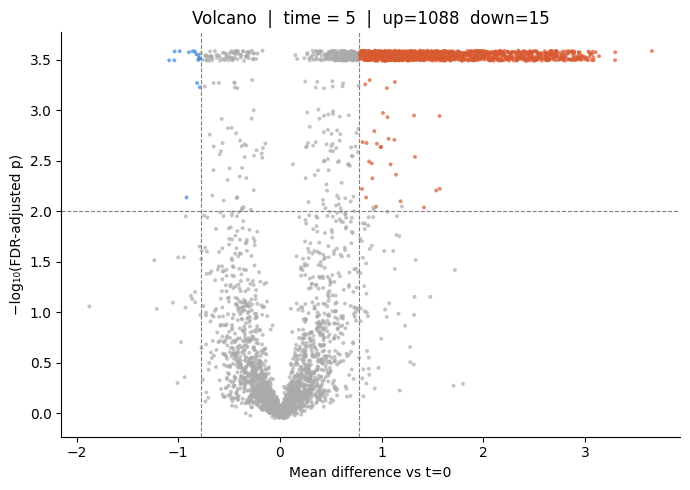

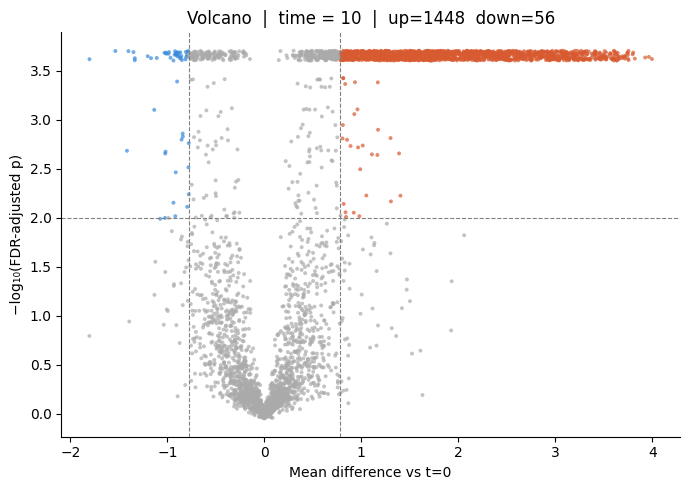

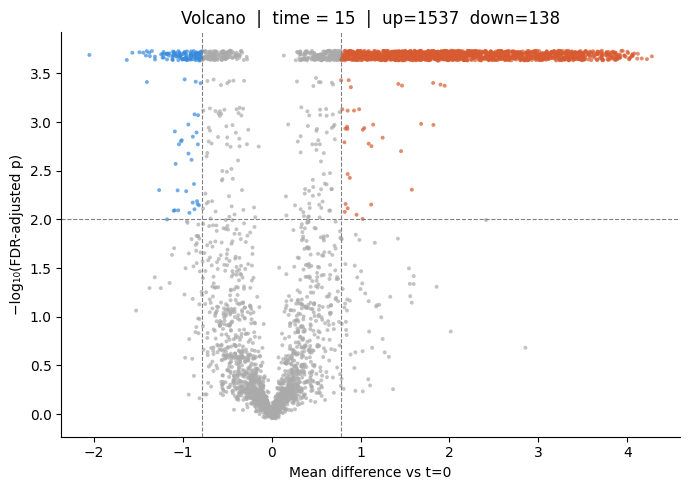

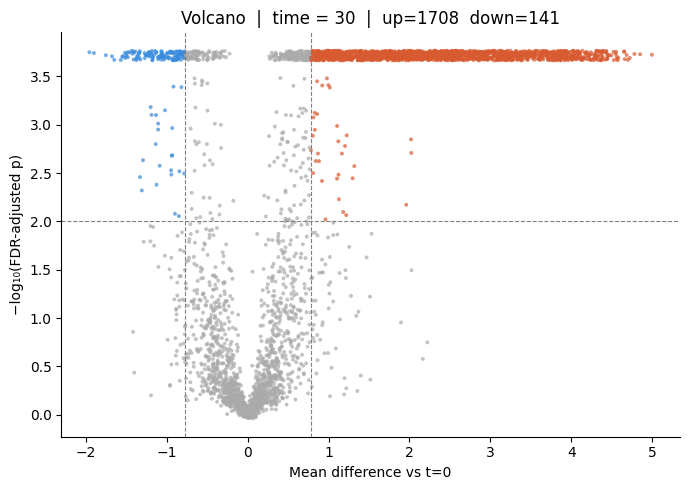

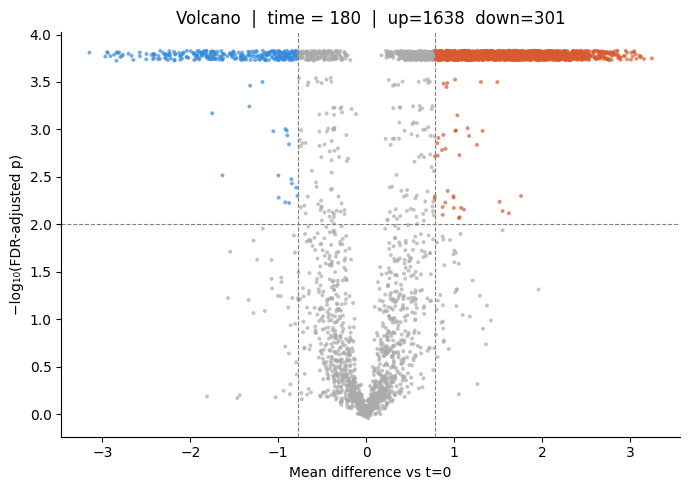

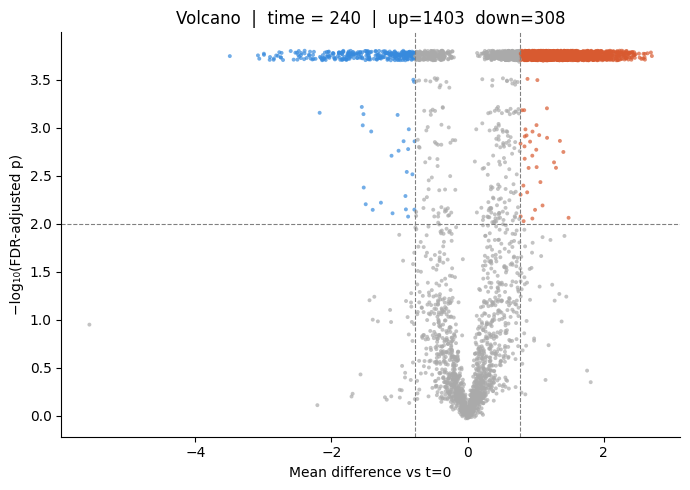

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── p-value from bootstrap difference distribution ───────────────────────────
def empirical_pval(boot_diff):
    samples = np.array(boot_diff, dtype=float)
    samples = samples[~np.isnan(samples)]
    if len(samples) == 0:
        return np.nan
    p = min(np.mean(samples <= 0), np.mean(samples >= 0))
    return np.clip(2 * p, 1 / len(samples), 1.0)

# ── join t=0 onto every other timepoint ─────────────────────────────────────
t0 = (
    df[df["time"] == 0]
    .set_index("ADseq")[["mean", "boot_samples"]]
    .rename(columns={"mean": "mean_t0", "boot_samples": "boot_t0"})
)

df_diff = df[df["time"] != 0].join(t0, on="ADseq")

# ── effect size: mean difference ─────────────────────────────────────────────
df_diff["mean_diff"] = df_diff["mean"] - df_diff["mean_t0"]

# ── bootstrap difference distribution (element-wise, NaN-aware) ──────────────
def safe_diff(a, b):
    # guard against scalar NaN from failed join
    if np.isscalar(a) or np.isscalar(b):
        return np.array([], dtype=float)
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    mask = ~(np.isnan(a) | np.isnan(b))
    return a[mask] - b[mask]

df_diff["boot_diff"] = df_diff.apply(
    lambda row: safe_diff(row["boot_samples"], row["boot_t0"]), axis=1
)

# ── p-values ─────────────────────────────────────────────────────────────────
df_diff["pval"]      = df_diff["boot_diff"].apply(empirical_pval)
df_diff["neglog10p"] = -np.log10(df_diff["pval"].clip(lower=1e-300))

# ── volcano plot ──────────────────────────────────────────────────────────────
from statsmodels.stats.multitest import multipletests

def add_fdr(df_diff, pval_thresh=0.05, diff_thresh=0.5):
    results = []
    
    for t, sub in df_diff.groupby("time"):
        sub = sub.copy()
        sub = sub.dropna(subset=["pval", "mean_diff"])
        
        # BH correction per timepoint
        reject, pval_fdr, _, _ = multipletests(sub["pval"], alpha=pval_thresh, method="fdr_bh")
        sub["pval_fdr"] = pval_fdr
        sub["reject"]   = reject
        results.append(sub)
    
    return pd.concat(results)

df_diff = add_fdr(df_diff)

# then in plot_volcano, swap pval for pval_fdr
def plot_volcano(df, timepoint, pval_thresh=0.01, diff_thresh=0.778, jitter=0.05, seed=42):
    sub = df[df["time"] == timepoint].copy()
    sub = sub.dropna(subset=["mean_diff", "neglog10p"])
    sub = sub[np.isfinite(sub["mean_diff"]) & np.isfinite(sub["neglog10p"])]

    up   = (sub["pval_fdr"] < pval_thresh) & (sub["mean_diff"] >  diff_thresh)
    down = (sub["pval_fdr"] < pval_thresh) & (sub["mean_diff"] < -diff_thresh)
    ns   = ~(up | down)

    colors = np.where(up, "#D85A30", np.where(down, "#378ADD", "#AAAAAA"))

    rng    = np.random.default_rng(seed)
    y_plot = -np.log10(sub["pval_fdr"].clip(lower=1e-300))
    y_plot = y_plot + rng.uniform(-jitter, jitter, size=len(sub))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(sub["mean_diff"], y_plot, c=colors, s=8, alpha=0.7, linewidths=0)
    # ax.scatter(sub["mean_diff"], y_plot, c=colors, s=1 + (sub["n_barcodes"] - 2) * 4, alpha=0.7, linewidths=0)

    ax.axhline(-np.log10(pval_thresh), color="gray", lw=0.8, ls="--")
    ax.axvline( diff_thresh,           color="gray", lw=0.8, ls="--")
    ax.axvline(-diff_thresh,           color="gray", lw=0.8, ls="--")

    ax.set_xlabel("Mean difference vs t=0")
    ax.set_ylabel("−log₁₀(FDR-adjusted p)")
    ax.set_title(f"Volcano  |  time = {timepoint}  |  up={up.sum()}  down={down.sum()}")

    sns.despine()
    plt.tight_layout()
    plt.show()

for t in sorted(df_diff["time"].unique()):
    plot_volcano(df_diff, t)

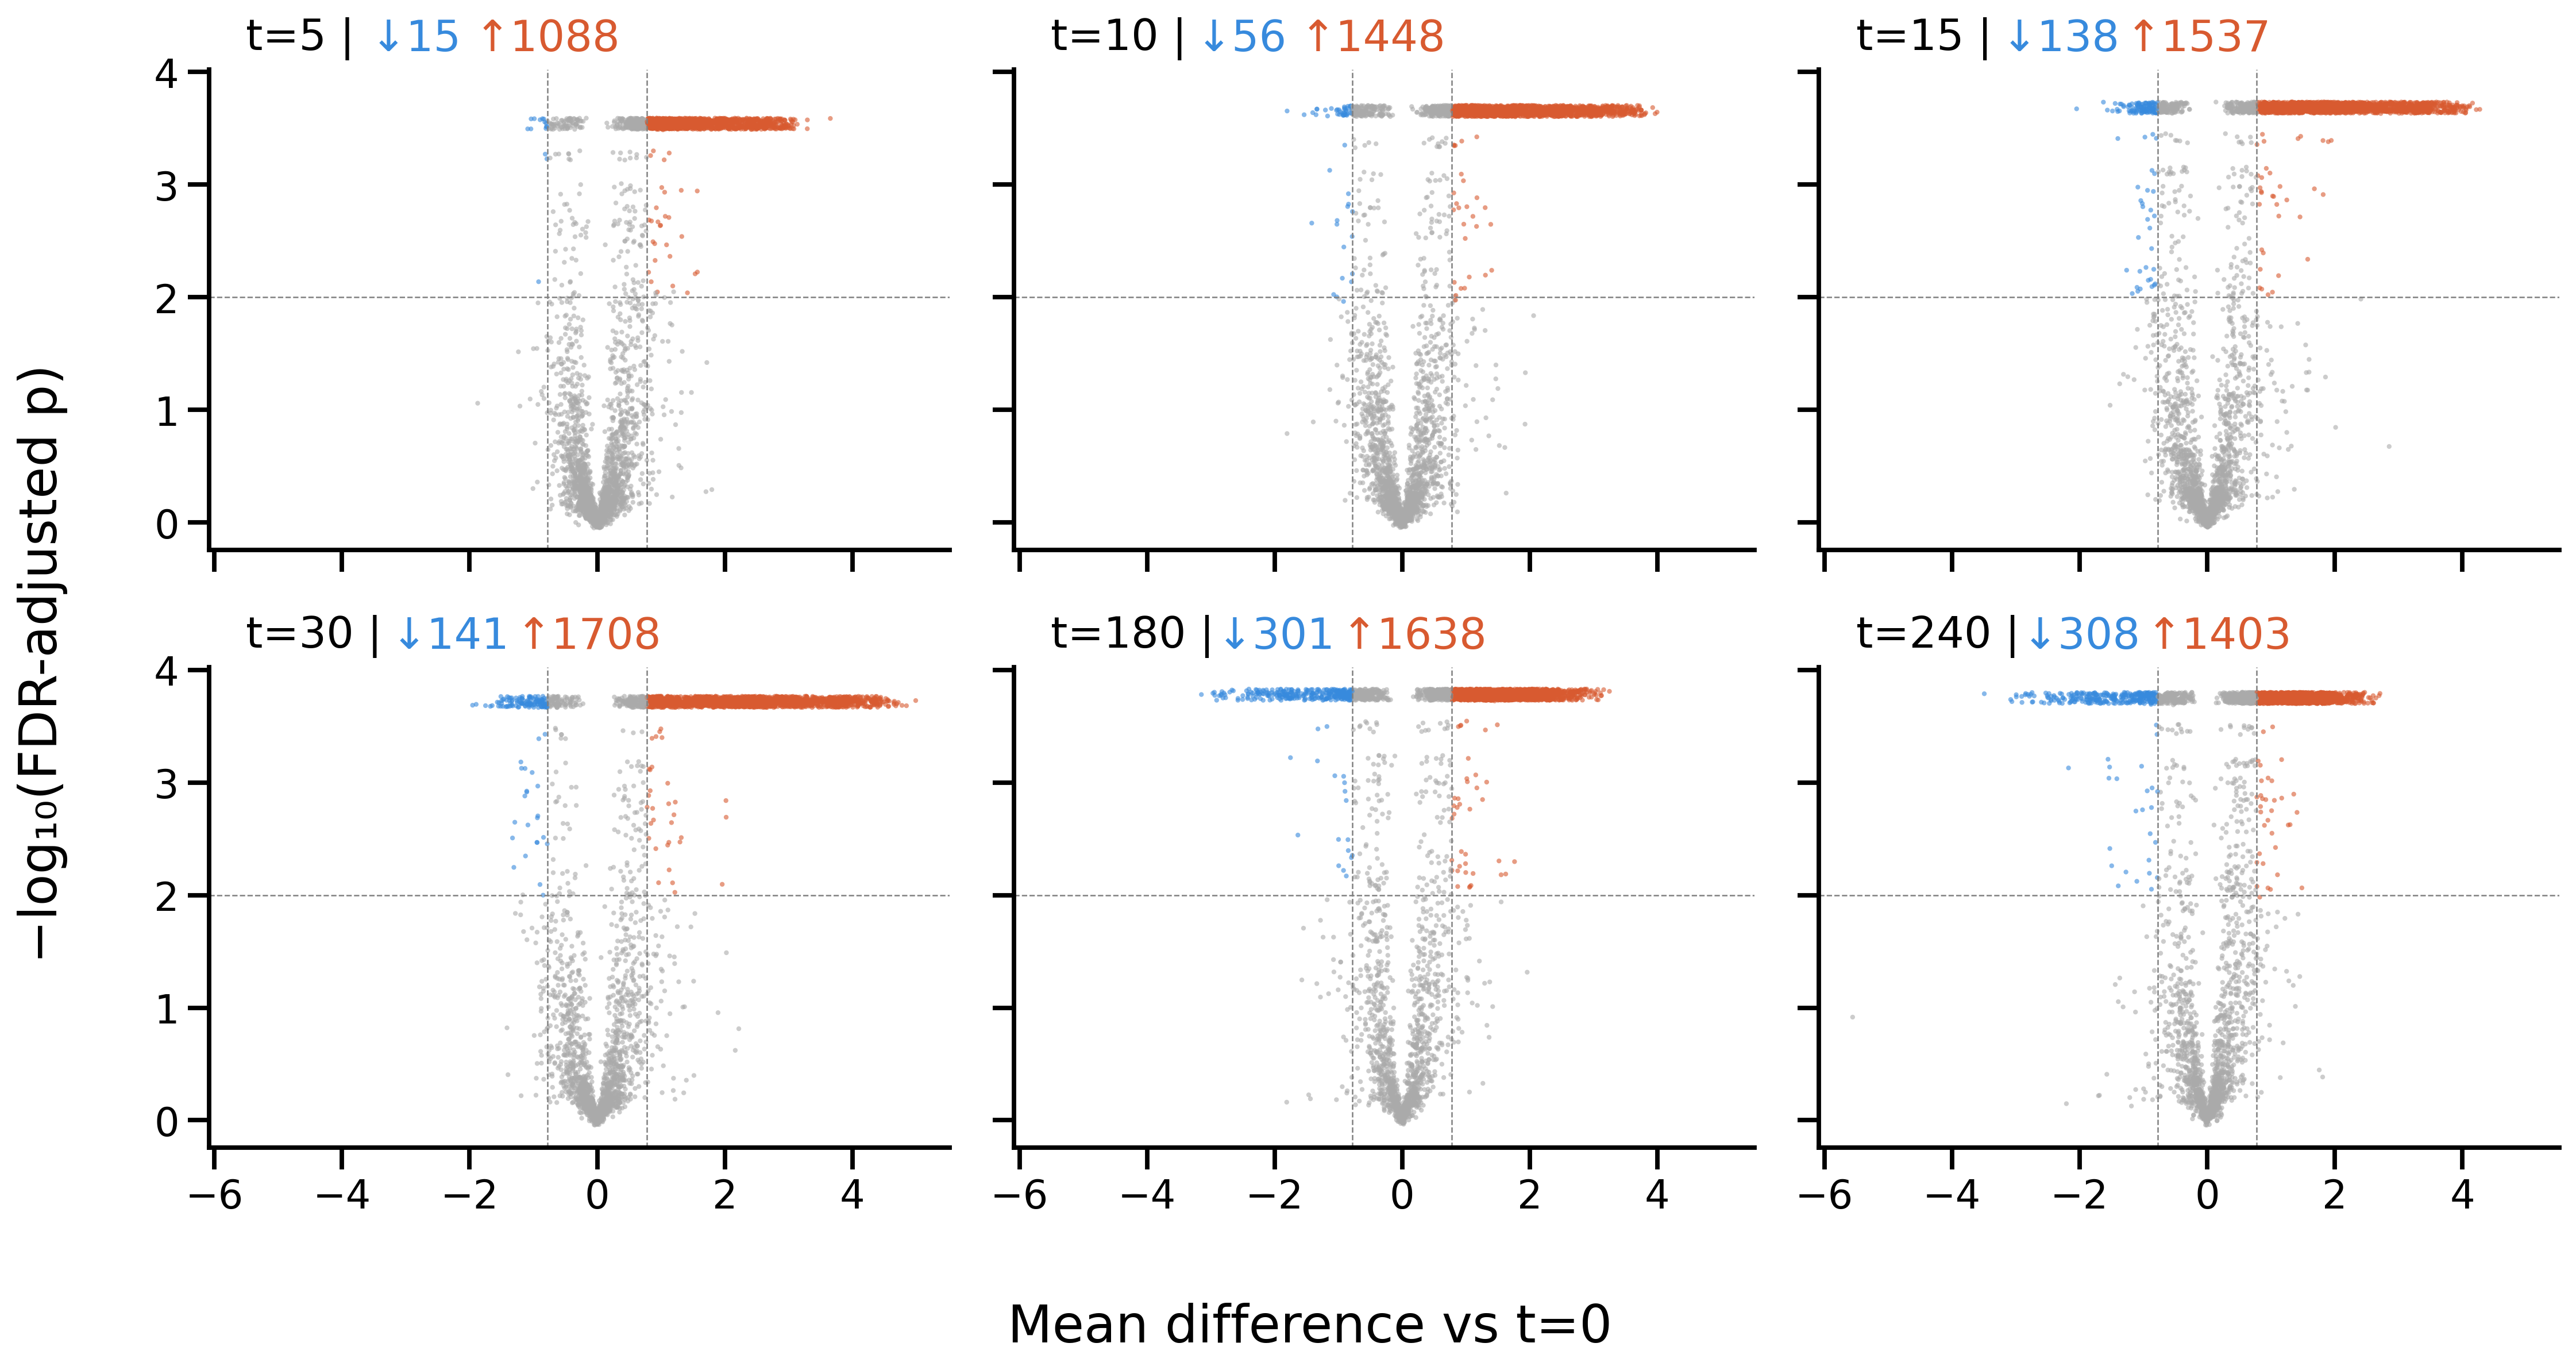

In [16]:
sns.set_context('talk')
def plot_volcano_subplots(df, pval_thresh=0.01, diff_thresh=0.778, jitter=0.05, seed=42):
    timepoints = sorted(df["time"].unique())
    n = len(timepoints)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(5 * ncols, 4 * nrows),
        sharex=True, sharey=True, dpi = 300
    )
    axes = axes.flatten()
    rng = np.random.default_rng(seed)
    for i, t in enumerate(timepoints):
        ax = axes[i]
        sub = df[df["time"] == t].copy()
        sub = sub.dropna(subset=["mean_diff", "pval_fdr"])
        sub = sub[np.isfinite(sub["mean_diff"])]
        up   = (sub["pval_fdr"] < pval_thresh) & (sub["mean_diff"] >  diff_thresh)
        down = (sub["pval_fdr"] < pval_thresh) & (sub["mean_diff"] < -diff_thresh)
        ns   = ~(up | down)
        colors = np.where(up, "#D85A30", np.where(down, "#378ADD", "#AAAAAA"))
        y_plot = -np.log10(sub["pval_fdr"].clip(lower=1e-300))
        y_plot = y_plot + rng.uniform(-jitter, jitter, size=len(sub))
        ax.scatter(sub["mean_diff"], y_plot, c=colors, s=4, alpha=0.6, linewidths=0)
        # ax.scatter(sub["mean_diff"], y_plot, c=colors, s=1 + (sub["n_barcodes"] - 2) * 4, alpha=0.7, linewidths=0)

        ax.axhline(-np.log10(pval_thresh), color="gray", lw=0.6, ls="--")
        if diff_thresh > 0:
            ax.axvline( diff_thresh, color="gray", lw=0.6, ls="--")
            ax.axvline(-diff_thresh, color="gray", lw=0.6, ls="--")

        # colored title: down first, up second
        title_y = 1.02
        prefix    = f"t={t} | "
        down_str  = f"↓{down.sum()}"
        sep       = "  "
        up_str    = f"↑{up.sum()}"

        x0 = 0.05
        cw = 0.028  # approximate character width in axes fraction
        ax.text(x0, title_y, prefix, transform=ax.transAxes,
                ha="left", va="bottom", fontsize="medium")
        x1 = x0 + len(prefix) * cw
        ax.text(x1, title_y, down_str, transform=ax.transAxes,
                ha="left", va="bottom", fontsize="medium", color="#378ADD")
        x2 = x1 + len(down_str) * cw
        ax.text(x2, title_y, sep, transform=ax.transAxes,
                ha="left", va="bottom", fontsize="medium")
        x3 = x2 + len(sep) * cw
        ax.text(x3, title_y, up_str, transform=ax.transAxes,
                ha="left", va="bottom", fontsize="medium", color="#D85A30")

    for j in range(len(timepoints), len(axes)):
        fig.delaxes(axes[j])
    fig.supxlabel("Mean difference vs t=0", y=0)
    fig.supylabel("−log₁₀(FDR-adjusted p)", x=0)
    sns.despine()
    plt.tight_layout(pad=1)
    plt.show()

plot_volcano_subplots(df_diff)

In [17]:
def classify_tiles(df_diff, diff_thresh=0.778, pval_thresh=0.01):
    sub = df_diff#[df_diff["time"] == timepoint].copy()

    sub["class"] = "ns"  # default

    up   = (sub["pval_fdr"] < pval_thresh) & (sub["mean_diff"] >  diff_thresh)
    down = (sub["pval_fdr"] < pval_thresh) & (sub["mean_diff"] < -diff_thresh)

    sub.loc[up, "class"] = "activator"
    sub.loc[down, "class"] = "repressor"

    return sub
    
df_diff_classified = classify_tiles(df_diff)
df_diff_classified

,ADseq,time,mean,ci_low,ci_hi,boot_samples,n_barcodes,mean_t0,boot_t0,mean_diff,boot_diff,pval,neglog10p,pval_fdr,reject,class
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,"[0.20202915, 0.17487152, 0.38542524, 0.2113351...",2,-0.533217,"[-0.2008878, -0.015304606, -0.32382935, -0.120...",0.569780,"[0.40291695296764374, 0.1901761256158352, 0.70...",0.0692,1.159894,0.137227,False,ns
8,AAAYSVEPKKPIVQTPASPASPRAKRSVASSPVPASGGVK,5,-0.567039,-1.235150,-0.067901,"[-0.88796026, -0.018196477, -0.26833534, -0.79...",3,-0.206253,"[-0.31071272, -0.041665714, 0.104156256, -0.10...",-0.360786,"[-0.5772475302219391, 0.023469237610697746, -0...",0.2752,0.560352,0.433466,False,ns
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,"[1.3950139, 0.838286, 0.6816617, 0.1572529, 1....",2,0.603252,"[0.651544, 0.55847883, 0.54688746, 0.56472474,...",0.246383,"[0.7434699535369873, 0.2798071503639221, 0.134...",0.5008,0.300335,0.659281,False,ns
22,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,5,1.024861,0.816313,1.189509,"[0.87451494, 0.97834414, 1.0768696, 0.95641226...",2,-0.068038,"[-0.07438486, -0.10344183, -0.034684062, -0.09...",1.092899,"[0.9488997980952263, 1.0817859694361687, 1.111...",0.0001,4.000000,0.000288,True,activator
29,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,5,0.816623,0.692523,0.958316,"[0.91827434, 0.9067343, 0.9477156, 0.76899654,...",3,-0.303746,"[-0.09549763, -0.41179726, -0.13458185, -0.349...",1.120368,"[1.0137719735503197, 1.3185315430164337, 1.082...",0.0001,4.000000,0.000288,True,activator
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27527,YTRRHSHLSASAHGQAGRPHRPPVPLFPHGLPSVPRTANA,240,0.169240,-0.029605,0.345518,"[0.11648306, 0.112231076, 0.13822804, 0.349048...",2,0.123822,"[0.08809781, 0.10917163, 0.014512181, 0.397342...",0.045418,"[0.028385251760482788, 0.0030594468116760254, ...",0.6628,0.178618,0.712720,False,ns
27534,YVPSFQKAFEDAATAANATDSTRLISLAIPPGEVSKSRQT,240,0.223250,0.151310,0.298678,"[0.22543684, 0.25779605, 0.2510087, 0.18470792...",2,0.363170,"[0.3718899, 0.19889095, 0.19755846, 0.30933362...",-0.139919,"[-0.14645305275917053, 0.05890509486198425, 0....",0.2234,0.650917,0.282361,False,ns
27541,YVYYLPIRWVWYFPLNHSQRQSSQRRESKEEPCRRLLRNS,240,-1.698865,-2.288556,-1.196391,"[-1.6924372, -1.2968328, -1.3336965, -2.052194...",2,0.188305,"[0.21150799, 0.077523455, 0.046093274, 0.20180...",-1.887170,"[-1.9039451628923416, -1.3743562549352646, -1....",0.0001,4.000000,0.000178,True,repressor
27548,YYGLYHTNHFEDALVVFRGRRSSMFRCYVLARADANRISA,240,-0.483511,-0.620323,-0.316526,"[-0.49774143, -0.6131679, -0.61674565, -0.6001...",2,0.193786,"[0.22897246, 0.19963166, 0.23936784, 0.1490656...",-0.677297,"[-0.7267138957977295, -0.8127995431423187, -0....",0.0001,4.000000,0.000178,True,ns


In [18]:
summary_with_class = pd.merge(summary, df_diff_classified[["ADseq", "time", "mean", "class"]], how = "left")
summary_with_class["class"] = summary_with_class["class"].fillna("ns")
summary_with_class

,ADseq,time,mean,ci_low,ci_hi,boot_samples,n_barcodes,class
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,"[-0.2008878, -0.015304606, -0.32382935, -0.120...",2,ns
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,"[0.20202915, 0.17487152, 0.38542524, 0.2113351...",2,ns
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,"[0.54796124, 0.59519506, 0.5511138, 0.62744856...",2,activator
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,"[0.3063501, 0.45152777, 0.6874338, 0.39934307,...",2,ns
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,"[0.5196667, 0.44921988, 1.1465678, 0.4846542, ...",2,ns
...,...,...,...,...,...,...,...,...
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,0.009890,-0.883891,0.659086,"[0.010301136, 0.08250949, -0.42100772, -0.0228...",2,ns
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,0.082184,-0.211983,0.440839,"[0.08036585, 0.06853164, 0.039140906, -0.16345...",2,ns
27553,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,0.110792,-0.227290,0.771827,"[0.10780283, 0.0013732016, -0.16929616, -0.122...",2,ns
27554,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,180,0.424809,0.353305,0.538222,"[0.42434907, 0.41014904, 0.37571436, 0.3845587...",2,ns


In [19]:
summary_with_class.drop(columns = "boot_samples").to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities_bootstrapped_error_active_pval.csv")

In [20]:
summary_with_class["class"].value_counts()

class
ns           17775
activator     8822
repressor      959
Name: count, dtype: int64

In [21]:
def get_hits(df_diff, timepoint, diff_thresh=0, pval_thresh=0.05, direction="both"):
    """
    direction: "up", "down", or "both"
    uses FDR-adjusted p-value (pval_fdr) and mean_diff vs t=0
    """
    sub = df_diff[df_diff["time"] == timepoint].copy()
    sub = sub.dropna(subset=["mean_diff", "pval_fdr"])

    up   = (sub["pval_fdr"] < pval_thresh) & (sub["mean_diff"] >  diff_thresh)
    down = (sub["pval_fdr"] < pval_thresh) & (sub["mean_diff"] < -diff_thresh)

    if direction == "up":
        mask = up
    elif direction == "down":
        mask = down
    else:
        mask = up | down

    hits = sub[mask].copy()
    hits["direction"] = np.where(up[mask], "up", "down")

    return (hits[["ADseq", "time", "mean", "mean_t0", "mean_diff", "pval", "pval_fdr", "direction"]]
            .sort_values("mean_diff")
            .reset_index(drop=True))

# usage
repressors  = get_hits(df_diff, timepoint=30, direction="down")
activators  = get_hits(df_diff, timepoint=30, direction="up")
all_hits    = get_hits(df_diff, timepoint=30, direction="both")

print(f"repressors:  {len(repressors)}")
print(f"activators:  {len(activators)}")
print(f"total hits:  {len(all_hits)}")

repressors.head(20)

repressors:  331
activators:  2014
total hits:  2345


,ADseq,time,mean,mean_t0,mean_diff,pval,pval_fdr,direction
0,ARISTVPQPPQPRRVSQIVHSLGYATSPASFSYRSPSSYS,30,-1.010764,0.942586,-1.953350,0.000104,0.000194,down
1,SSAAALQNQRVAAIIQSTGHSINTSALTNRFTPQQSSIQQ,30,-1.769317,0.128126,-1.897442,0.000100,0.000193,down
2,HPYLVQSQYQPRRHSLSLYQHLQQQKLARSPVQVPRVTRL,30,-1.560932,0.189639,-1.750571,0.000100,0.000193,down
3,THTAIGLNQRRHSSHQLRQNLQGRVHLQQKHRLAQIQASG,30,-1.461314,0.212767,-1.674080,0.000100,0.000193,down
4,QQASSPSLQNQRVANIIQATGHQTTSSAFTNRFSSSAQNP,30,-1.535782,0.110664,-1.646446,0.000100,0.000193,down
5,QHPRSASIPQPRRVSEIVSGLGYSTSPSSFSHRTNPPPSY,30,-1.309290,0.256333,-1.565622,0.000100,0.000193,down
6,QQFYPPGSVSPSLQGTRVANIIQATGHPHSPAFTNRLSSP,30,-1.501155,0.045585,-1.546740,0.000100,0.000193,down
7,RQIKCRTSSLHFDPSSDVLIAKSHRRVHLHLSSVYQTSSP,30,-1.621700,-0.081362,-1.540338,0.000100,0.000193,down
8,QRVAAIIQSTGHSINTSALTNRFTPQQSSIQQFYASSAPN,30,-0.730728,0.782502,-1.513230,0.000100,0.000193,down
9,SAQSLQNQRVAAIIQSTGHSITTSALTNRFNPAQSPQQFY,30,-0.507652,1.002301,-1.509953,0.000100,0.000193,down


<Axes: xlabel='time', ylabel='mean'>

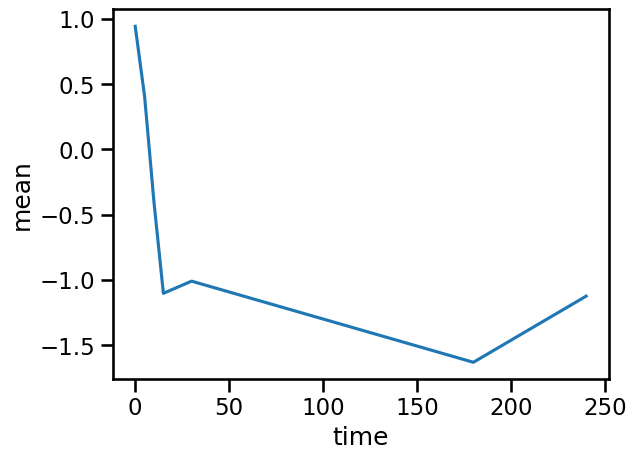

In [22]:
sns.lineplot(data = summary[summary["ADseq"] == "ARISTVPQPPQPRRVSQIVHSLGYATSPASFSYRSPSSYS"], x = "time", y = "mean")

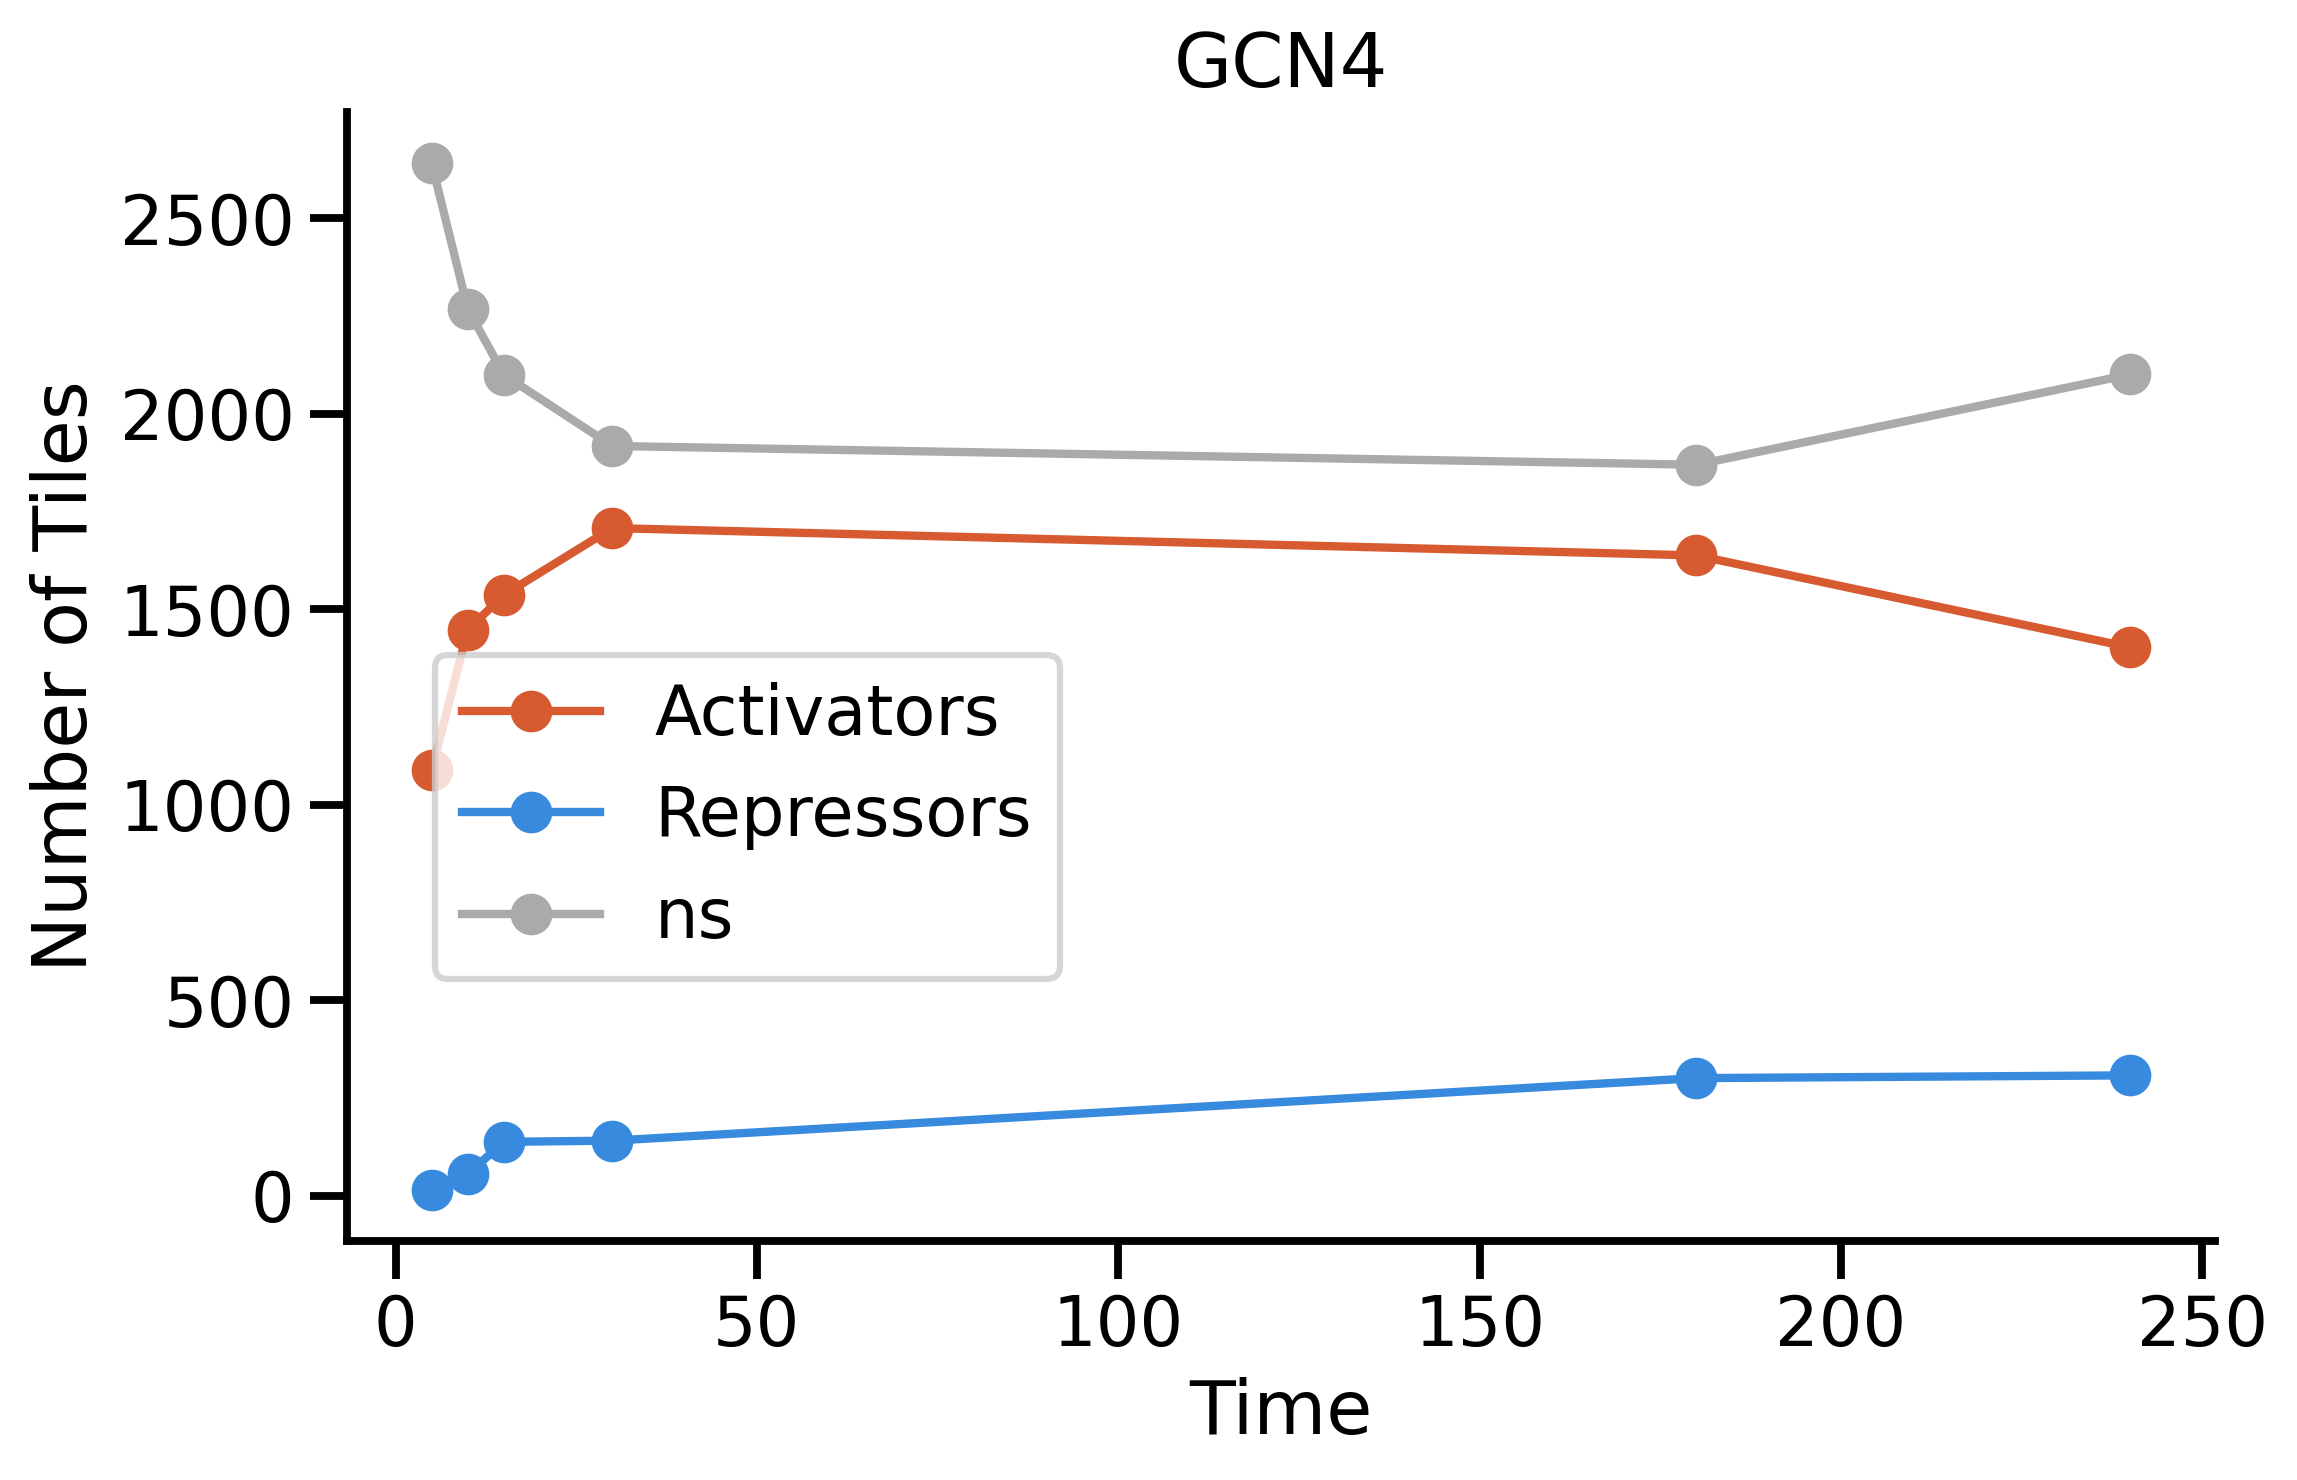

In [24]:
def plot_trajectories(df_diff, pval_thresh=0.01, diff_thresh=0.778):
    timepoints = sorted(df_diff["time"].unique())

    # classify each AD at each timepoint
    df_diff = df_diff.copy()
    df_diff["sig_up"]   = (df_diff["pval_fdr"] < pval_thresh) & (df_diff["mean_diff"] >  diff_thresh)
    df_diff["sig_down"] = (df_diff["pval_fdr"] < pval_thresh) & (df_diff["mean_diff"] < -diff_thresh)

    # count per timepoint
    counts = df_diff.groupby("time").agg(
        n_up   = ("sig_up",   "sum"),
        n_down = ("sig_down", "sum"),
    ).reset_index()
    counts["n_ns"] = df_diff.groupby("time").size().values - counts["n_up"] - counts["n_down"]

    fig, ax = plt.subplots(figsize=(8, 5), dpi = 300)

    ax.plot(counts["time"], counts["n_up"],   color="#D85A30", lw=2, marker="o", label="Activators")
    ax.plot(counts["time"], counts["n_down"], color="#378ADD", lw=2, marker="o", label="Repressors")
    ax.plot(counts["time"], counts["n_ns"],   color="#AAAAAA", lw=2, marker="o", label="ns")

    ax.set_xlabel("Time")
    ax.set_ylabel("Number of Tiles")
    ax.legend(loc = 'upper right', bbox_to_anchor = (0.4, 0.55))
    sns.despine()
    plt.tight_layout()
    plt.title("GCN4")
    plt.show()

    # # ── also plot fraction ───────────────────────────────────────────────────
    # total = counts["n_up"] + counts["n_down"] + counts["n_ns"]
    # fig, ax = plt.subplots(figsize=(8, 5))

    # ax.plot(counts["time"], counts["n_up"]   / total * 100, color="#D85A30", lw=2, marker="o", label="Activators")
    # ax.plot(counts["time"], counts["n_down"] / total * 100, color="#378ADD", lw=2, marker="o", label="Repressors")

    # ax.set_xlabel("Time")
    # ax.set_ylabel("% of Tiles")
    # ax.legend()
    # sns.despine()
    # plt.tight_layout()
    # plt.show()

plot_trajectories(df_diff)

# Plotting trajectories

In [25]:
df_diff

,ADseq,time,mean,ci_low,ci_hi,boot_samples,n_barcodes,mean_t0,boot_t0,mean_diff,boot_diff,pval,neglog10p,pval_fdr,reject,class
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,"[0.20202915, 0.17487152, 0.38542524, 0.2113351...",2,-0.533217,"[-0.2008878, -0.015304606, -0.32382935, -0.120...",0.569780,"[0.40291695296764374, 0.1901761256158352, 0.70...",0.0692,1.159894,0.137227,False,ns
8,AAAYSVEPKKPIVQTPASPASPRAKRSVASSPVPASGGVK,5,-0.567039,-1.235150,-0.067901,"[-0.88796026, -0.018196477, -0.26833534, -0.79...",3,-0.206253,"[-0.31071272, -0.041665714, 0.104156256, -0.10...",-0.360786,"[-0.5772475302219391, 0.023469237610697746, -0...",0.2752,0.560352,0.433466,False,ns
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,"[1.3950139, 0.838286, 0.6816617, 0.1572529, 1....",2,0.603252,"[0.651544, 0.55847883, 0.54688746, 0.56472474,...",0.246383,"[0.7434699535369873, 0.2798071503639221, 0.134...",0.5008,0.300335,0.659281,False,ns
22,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,5,1.024861,0.816313,1.189509,"[0.87451494, 0.97834414, 1.0768696, 0.95641226...",2,-0.068038,"[-0.07438486, -0.10344183, -0.034684062, -0.09...",1.092899,"[0.9488997980952263, 1.0817859694361687, 1.111...",0.0001,4.000000,0.000288,True,activator
29,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,5,0.816623,0.692523,0.958316,"[0.91827434, 0.9067343, 0.9477156, 0.76899654,...",3,-0.303746,"[-0.09549763, -0.41179726, -0.13458185, -0.349...",1.120368,"[1.0137719735503197, 1.3185315430164337, 1.082...",0.0001,4.000000,0.000288,True,activator
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27527,YTRRHSHLSASAHGQAGRPHRPPVPLFPHGLPSVPRTANA,240,0.169240,-0.029605,0.345518,"[0.11648306, 0.112231076, 0.13822804, 0.349048...",2,0.123822,"[0.08809781, 0.10917163, 0.014512181, 0.397342...",0.045418,"[0.028385251760482788, 0.0030594468116760254, ...",0.6628,0.178618,0.712720,False,ns
27534,YVPSFQKAFEDAATAANATDSTRLISLAIPPGEVSKSRQT,240,0.223250,0.151310,0.298678,"[0.22543684, 0.25779605, 0.2510087, 0.18470792...",2,0.363170,"[0.3718899, 0.19889095, 0.19755846, 0.30933362...",-0.139919,"[-0.14645305275917053, 0.05890509486198425, 0....",0.2234,0.650917,0.282361,False,ns
27541,YVYYLPIRWVWYFPLNHSQRQSSQRRESKEEPCRRLLRNS,240,-1.698865,-2.288556,-1.196391,"[-1.6924372, -1.2968328, -1.3336965, -2.052194...",2,0.188305,"[0.21150799, 0.077523455, 0.046093274, 0.20180...",-1.887170,"[-1.9039451628923416, -1.3743562549352646, -1....",0.0001,4.000000,0.000178,True,repressor
27548,YYGLYHTNHFEDALVVFRGRRSSMFRCYVLARADANRISA,240,-0.483511,-0.620323,-0.316526,"[-0.49774143, -0.6131679, -0.61674565, -0.6001...",2,0.193786,"[0.22897246, 0.19963166, 0.23936784, 0.1490656...",-0.677297,"[-0.7267138957977295, -0.8127995431423187, -0....",0.0001,4.000000,0.000178,True,ns


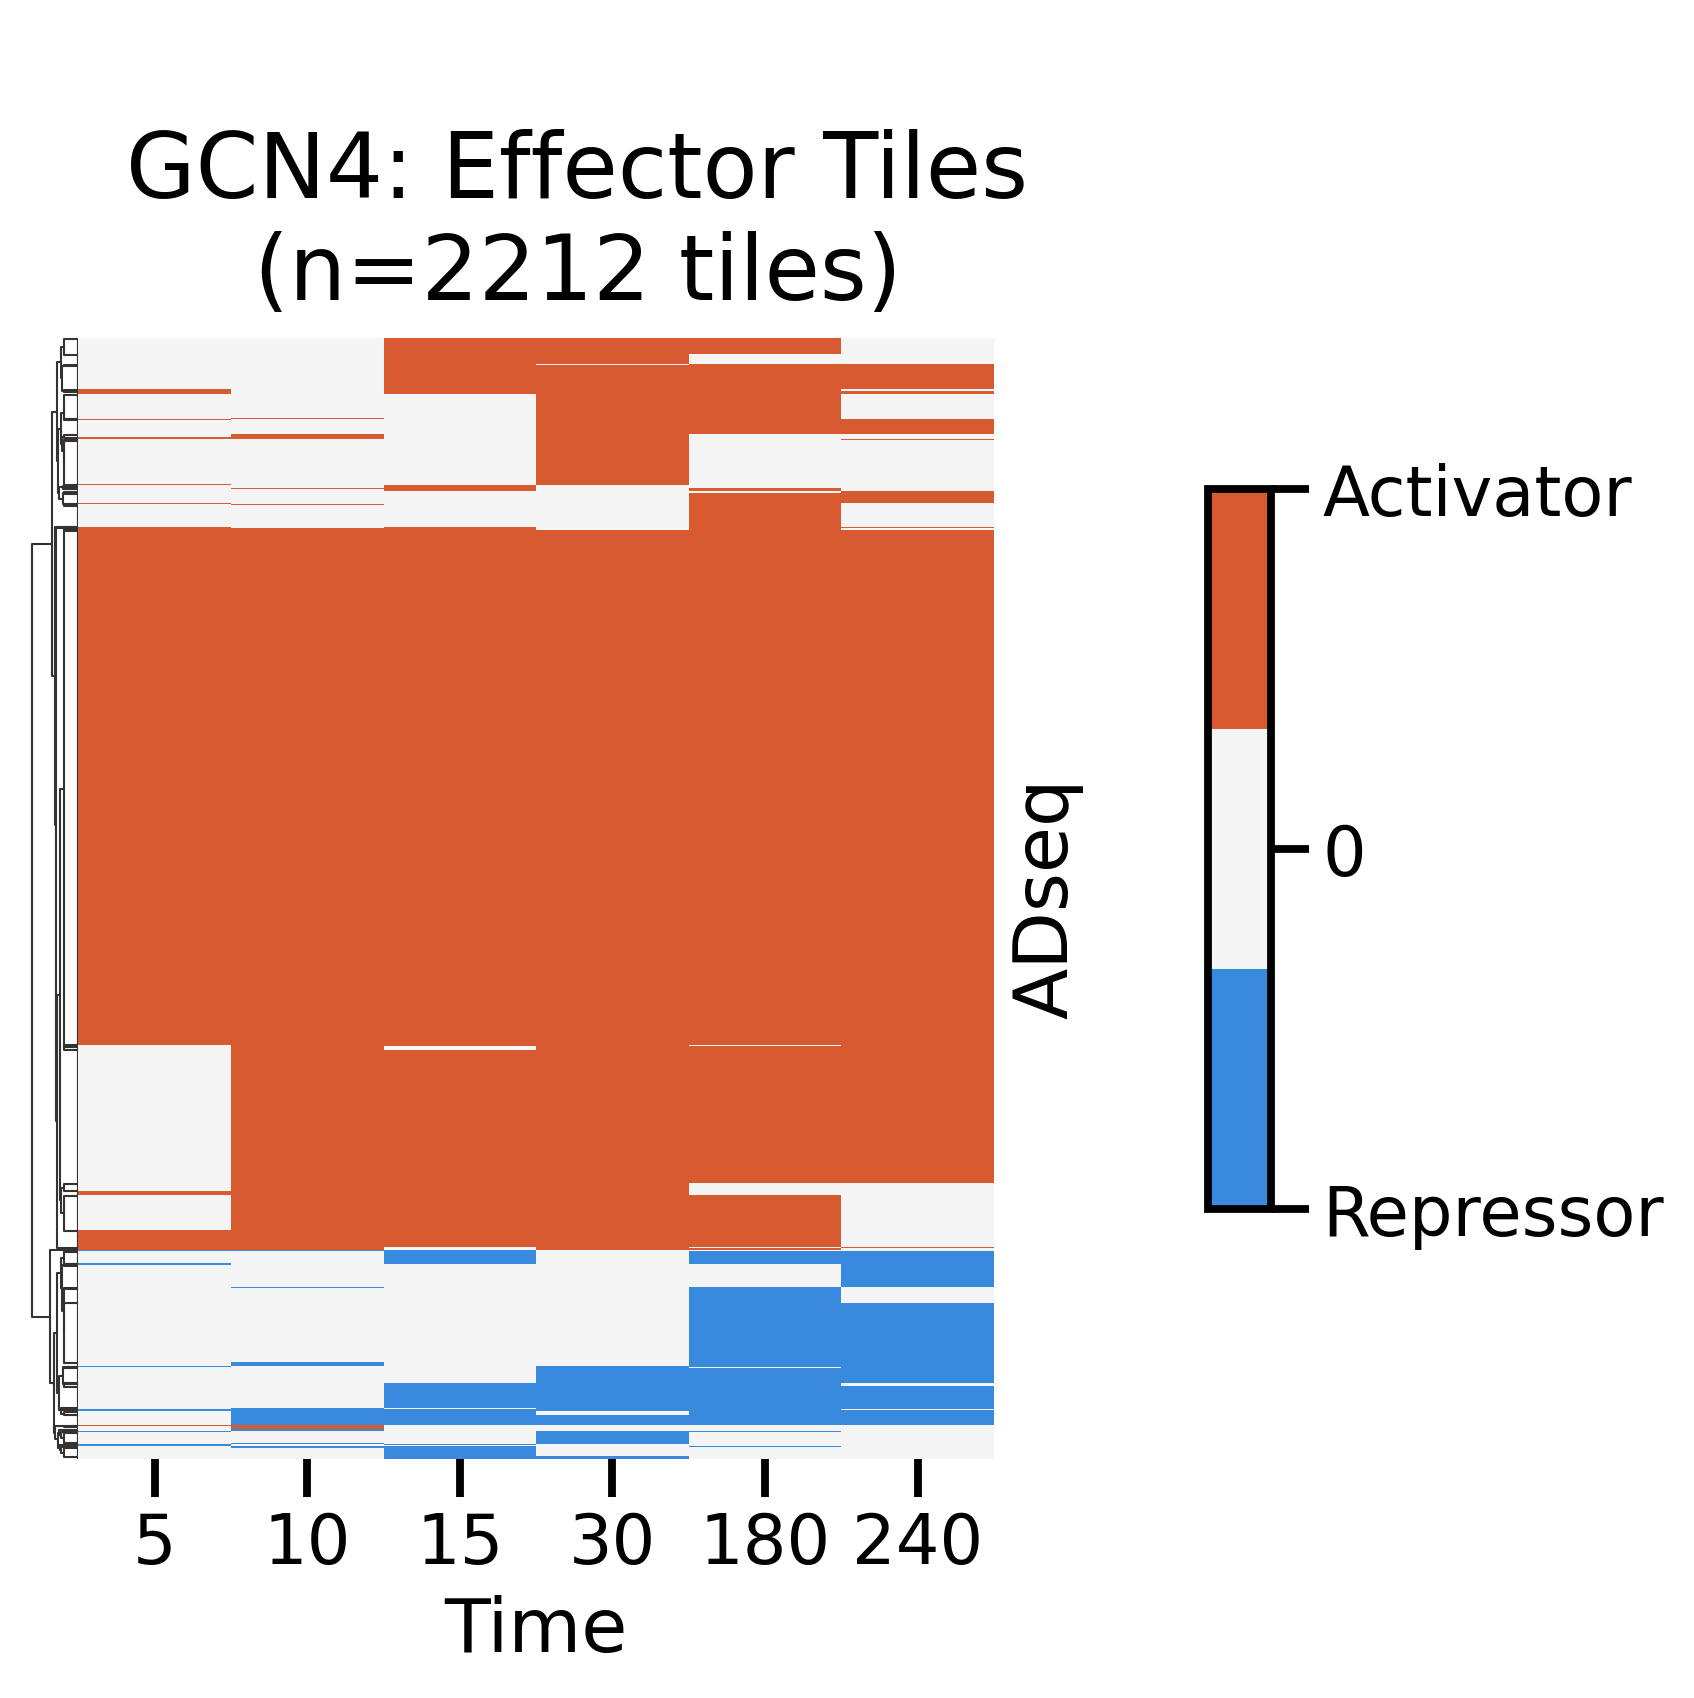

In [26]:
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 300

def plot_trajectory_heatmap(df_diff, pval_thresh=0.01, diff_thresh=0.778):
    timepoints = sorted(df_diff["time"].unique())
    df_diff = df_diff.copy()
    df_diff["state"] = np.where(
        (df_diff["pval_fdr"] < pval_thresh) & (df_diff["mean_diff"] >  diff_thresh),  1,
        np.where(
        (df_diff["pval_fdr"] < pval_thresh) & (df_diff["mean_diff"] < -diff_thresh), -1, 0))

    state_wide = df_diff.pivot(index="ADseq", columns="time", values="state").fillna(0)
    state_wide = state_wide[(state_wide != 0).any(axis=1)]

    cmap = LinearSegmentedColormap.from_list("volcano", ["#378ADD", "#F5F5F5", "#D85A30"], N=3)

    g = sns.clustermap(
        state_wide[timepoints],
        cmap=cmap, vmin=-1, vmax=1,
        row_cluster=True, col_cluster=False,
        figsize=(10.5, 6),
        dendrogram_ratio=(.05, .2),
        cbar_pos=None
    )

    # remove gap between dendrogram and heatmap
    g.ax_row_dendrogram.set_position(
        g.ax_row_dendrogram.get_position().translated(
            g.ax_heatmap.get_position().x0 - g.ax_row_dendrogram.get_position().x1, 0
        )
    )

    g.ax_heatmap.set_xticklabels([f"t={t}" for t in timepoints], rotation=0)
    g.ax_heatmap.set_xlabel("Time")
    g.ax_heatmap.set_yticks([])
    g.ax_heatmap.set_xticklabels(
        [f"{t}" for t in timepoints],
        rotation=0
    )

    cbar_ax = g.fig.add_axes([0.4, 0.3, 0.02, 0.4])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
    sm.set_array([])
    g.fig.colorbar(sm, cax=cbar_ax, ticks=[-1, 0, 1]).ax.set_yticklabels(["Repressor", "0", "Activator"])
    g.fig.suptitle(f"GCN4: Effector Tiles\n(n={len(state_wide)} tiles)", x = 0.20, y = 0.9)

plot_trajectory_heatmap(df_diff)

# Activity vs error

In [27]:
summary["error"] = (summary["ci_hi"] - summary["ci_low"])
summary

,ADseq,time,mean,ci_low,ci_hi,boot_samples,n_barcodes,error
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,"[-0.2008878, -0.015304606, -0.32382935, -0.120...",2,1.331737
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,"[0.20202915, 0.17487152, 0.38542524, 0.2113351...",2,1.041080
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,"[0.54796124, 0.59519506, 0.5511138, 0.62744856...",2,0.668632
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,"[0.3063501, 0.45152777, 0.6874338, 0.39934307,...",2,1.005177
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,"[0.5196667, 0.44921988, 1.1465678, 0.4846542, ...",2,1.444178
...,...,...,...,...,...,...,...,...
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,0.009890,-0.883891,0.659086,"[0.010301136, 0.08250949, -0.42100772, -0.0228...",2,1.542976
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,0.082184,-0.211983,0.440839,"[0.08036585, 0.06853164, 0.039140906, -0.16345...",2,0.652822
27553,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,0.110792,-0.227290,0.771827,"[0.10780283, 0.0013732016, -0.16929616, -0.122...",2,0.999117
27554,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,180,0.424809,0.353305,0.538222,"[0.42434907, 0.41014904, 0.37571436, 0.3845587...",2,0.184916


In [28]:
summary.sort_values(by = 'error')

,ADseq,time,mean,ci_low,ci_hi,boot_samples,n_barcodes,error
20923,SPALNGDDLEVVEFASTSGRRKSVNSSPTSSARHSSVSGV,240,-0.268976,-0.284917,-0.249938,"[-0.25752947, -0.2645996, -0.26293463, -0.2534...",2,0.034979
12376,LTSPSTYNESPEYNDNFDVSPFVGNNGDIDQALAGDPWYP,10,3.106393,3.086802,3.124685,"[3.1063895, 3.1044054, 3.1010785, 3.1111178, 3...",2,0.037883
23271,SVPRGTWAFPAMANAPMPCLQQVSVSAAHAPHPRLFKIQS,240,-0.088057,-0.104780,-0.066328,"[-0.08039121, -0.09097807, -0.091840506, -0.07...",2,0.038452
24040,THVADLHSNNSFDSGASLMPAFAQAGGFTLEQVSAFTAIN,10,1.357490,1.326440,1.381178,"[1.3566675, 1.3457463, 1.3634624, 1.365525, 1....",2,0.054739
11471,LPDHIVVSPAAVSTKLEAPATTHLTLDAILGSASSMPALD,5,-0.370420,-0.399034,-0.342664,"[-0.3720176, -0.39068308, -0.37606406, -0.3940...",2,0.056370
...,...,...,...,...,...,...,...,...
13557,NESPEFDGYDVSPNFGSADFDGAADPWFPLFPQDNNVAPA,240,-1.623608,-5.897300,2.525595,"[-1.4030993, -6.0180116, 2.4087815, 2.4504418,...",2,8.422894
12922,MLDMQNSPVDFGSPVFSGNFSAAGESLFDLPTSTISPYDI,180,0.203038,-5.372956,3.056126,"[0.11941624, -5.3333635, 2.8936808, 2.8512332,...",3,8.429082
22814,STDYTPMFEYETYEDNFKEWTSLFDNDIPVTTDDVSLADR,180,0.757072,-4.872251,3.562887,"[0.5184531, 0.5932887, 3.485958, 0.61177254, 0...",3,8.435138
22815,STDYTPMFEYETYEDNFKEWTSLFDNDIPVTTDDVSLADR,240,0.359971,-5.466536,3.202173,"[3.0867825, 0.2401123, 3.212263, 0.21430993, 0...",3,8.668709


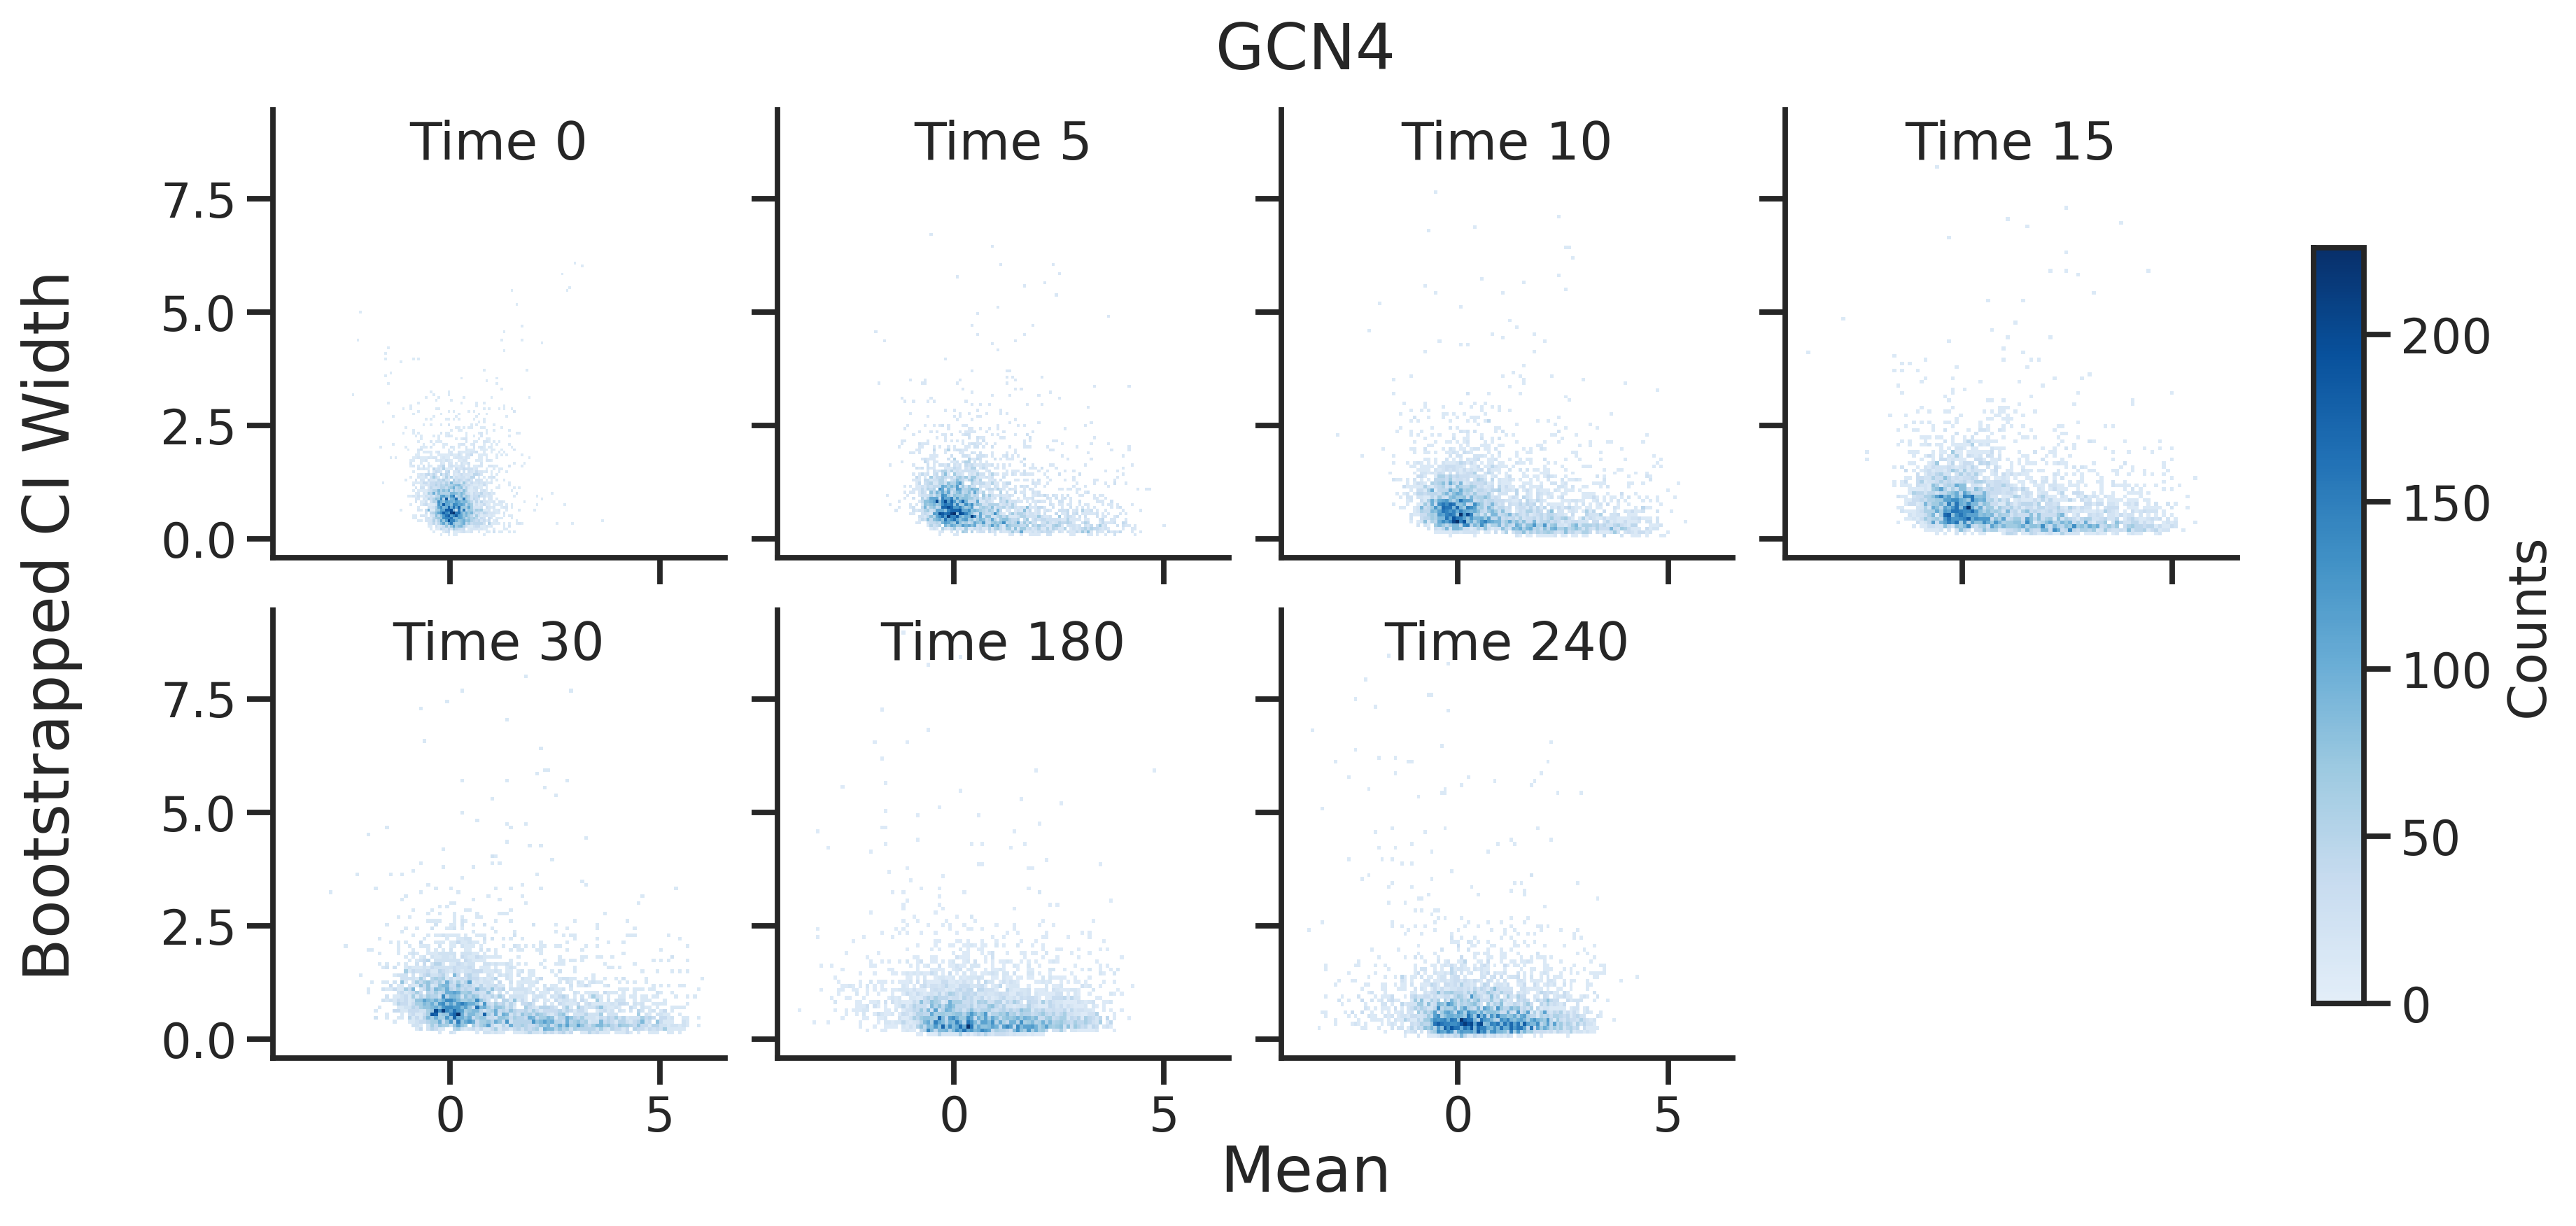

In [199]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

sns.set_context("talk")
sns.set_style('ticks')

df = summary.copy()

# --- Truncate colormap (same as yours) ---
def truncate_colormap(cmap, minval=0.15, maxval=1.0, n=256):
    new_colors = cmap(np.linspace(minval, maxval, n))
    return mpl.colors.LinearSegmentedColormap.from_list("trunc", new_colors)

cmap = truncate_colormap(mpl.cm.Blues, 0.1, 1.0)

# --- Global max for consistent color scaling ---
# Drop NaNs and infs for histogram calculation
clean = df[["mean", "error"]].replace([np.inf, -np.inf], np.nan).dropna()

counts, _, _ = np.histogram2d(clean["mean"], clean["error"], bins=80)
global_max = counts.max()
global_max = counts.max()

# --- Sort times ---
times = sorted(df["time"].unique())

# --- Layout ---
n = len(times)
cols = min(4, n)
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows),
                         sharex=True, sharey=True, dpi=300)

axes = np.array(axes).reshape(-1)

# --- Global axis limits ---
xmin, xmax = df["mean"].min(), df["mean"].max()
ymin, ymax = df["error"].min(), df["error"].max()

xpad, ypad = 1, 1
ymin, ymax = ymin - ypad, ymax + ypad

# --- Plot ---
for i, time in enumerate(times):
    ax = axes[i]
    subset = df[df["time"] == time]

    sns.histplot(
        data=subset,
        x="mean",
        y="error",
        bins=100,
        cmap=cmap,
        cbar=False,
        ax=ax
    )

    ax.set_title(f"Time {time}", y=0.85)
    # ax.set_xlim(xmin, xmax)
    #ax.set_ylim(-0.05,1.5)
    ax.set_xlabel("")
    ax.set_ylabel("")

# --- Turn off unused axes ---
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# --- Shared labels ---
fig.supxlabel("Mean", y=0.04)
fig.supylabel("Bootstrapped CI Width", x = -0.01)

# --- Shared colorbar ---
sm = mpl.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=0, vmax=global_max),
    cmap=cmap
)
sm.set_array([])

cbar_ax = fig.add_axes([0.9, 0.2, 0.02, 0.6])
fig.colorbar(sm, cax=cbar_ax, label="Counts")
fig.suptitle("GCN4")

# --- Layout polish ---
plt.tight_layout(rect=[0, 0, 0.88, 1], pad = 0.5)
sns.despine()
plt.show()

In [30]:
summary_with_class["error"] = (summary_with_class["ci_hi"] - summary_with_class["ci_low"])
summary_with_class

,ADseq,time,mean,ci_low,ci_hi,boot_samples,n_barcodes,class,error
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,"[-0.2008878, -0.015304606, -0.32382935, -0.120...",2,ns,1.331737
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,"[0.20202915, 0.17487152, 0.38542524, 0.2113351...",2,ns,1.041080
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,"[0.54796124, 0.59519506, 0.5511138, 0.62744856...",2,activator,0.668632
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,"[0.3063501, 0.45152777, 0.6874338, 0.39934307,...",2,ns,1.005177
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,"[0.5196667, 0.44921988, 1.1465678, 0.4846542, ...",2,ns,1.444178
...,...,...,...,...,...,...,...,...,...
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,0.009890,-0.883891,0.659086,"[0.010301136, 0.08250949, -0.42100772, -0.0228...",2,ns,1.542976
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,0.082184,-0.211983,0.440839,"[0.08036585, 0.06853164, 0.039140906, -0.16345...",2,ns,0.652822
27553,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,0.110792,-0.227290,0.771827,"[0.10780283, 0.0013732016, -0.16929616, -0.122...",2,ns,0.999117
27554,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,180,0.424809,0.353305,0.538222,"[0.42434907, 0.41014904, 0.37571436, 0.3845587...",2,ns,0.184916


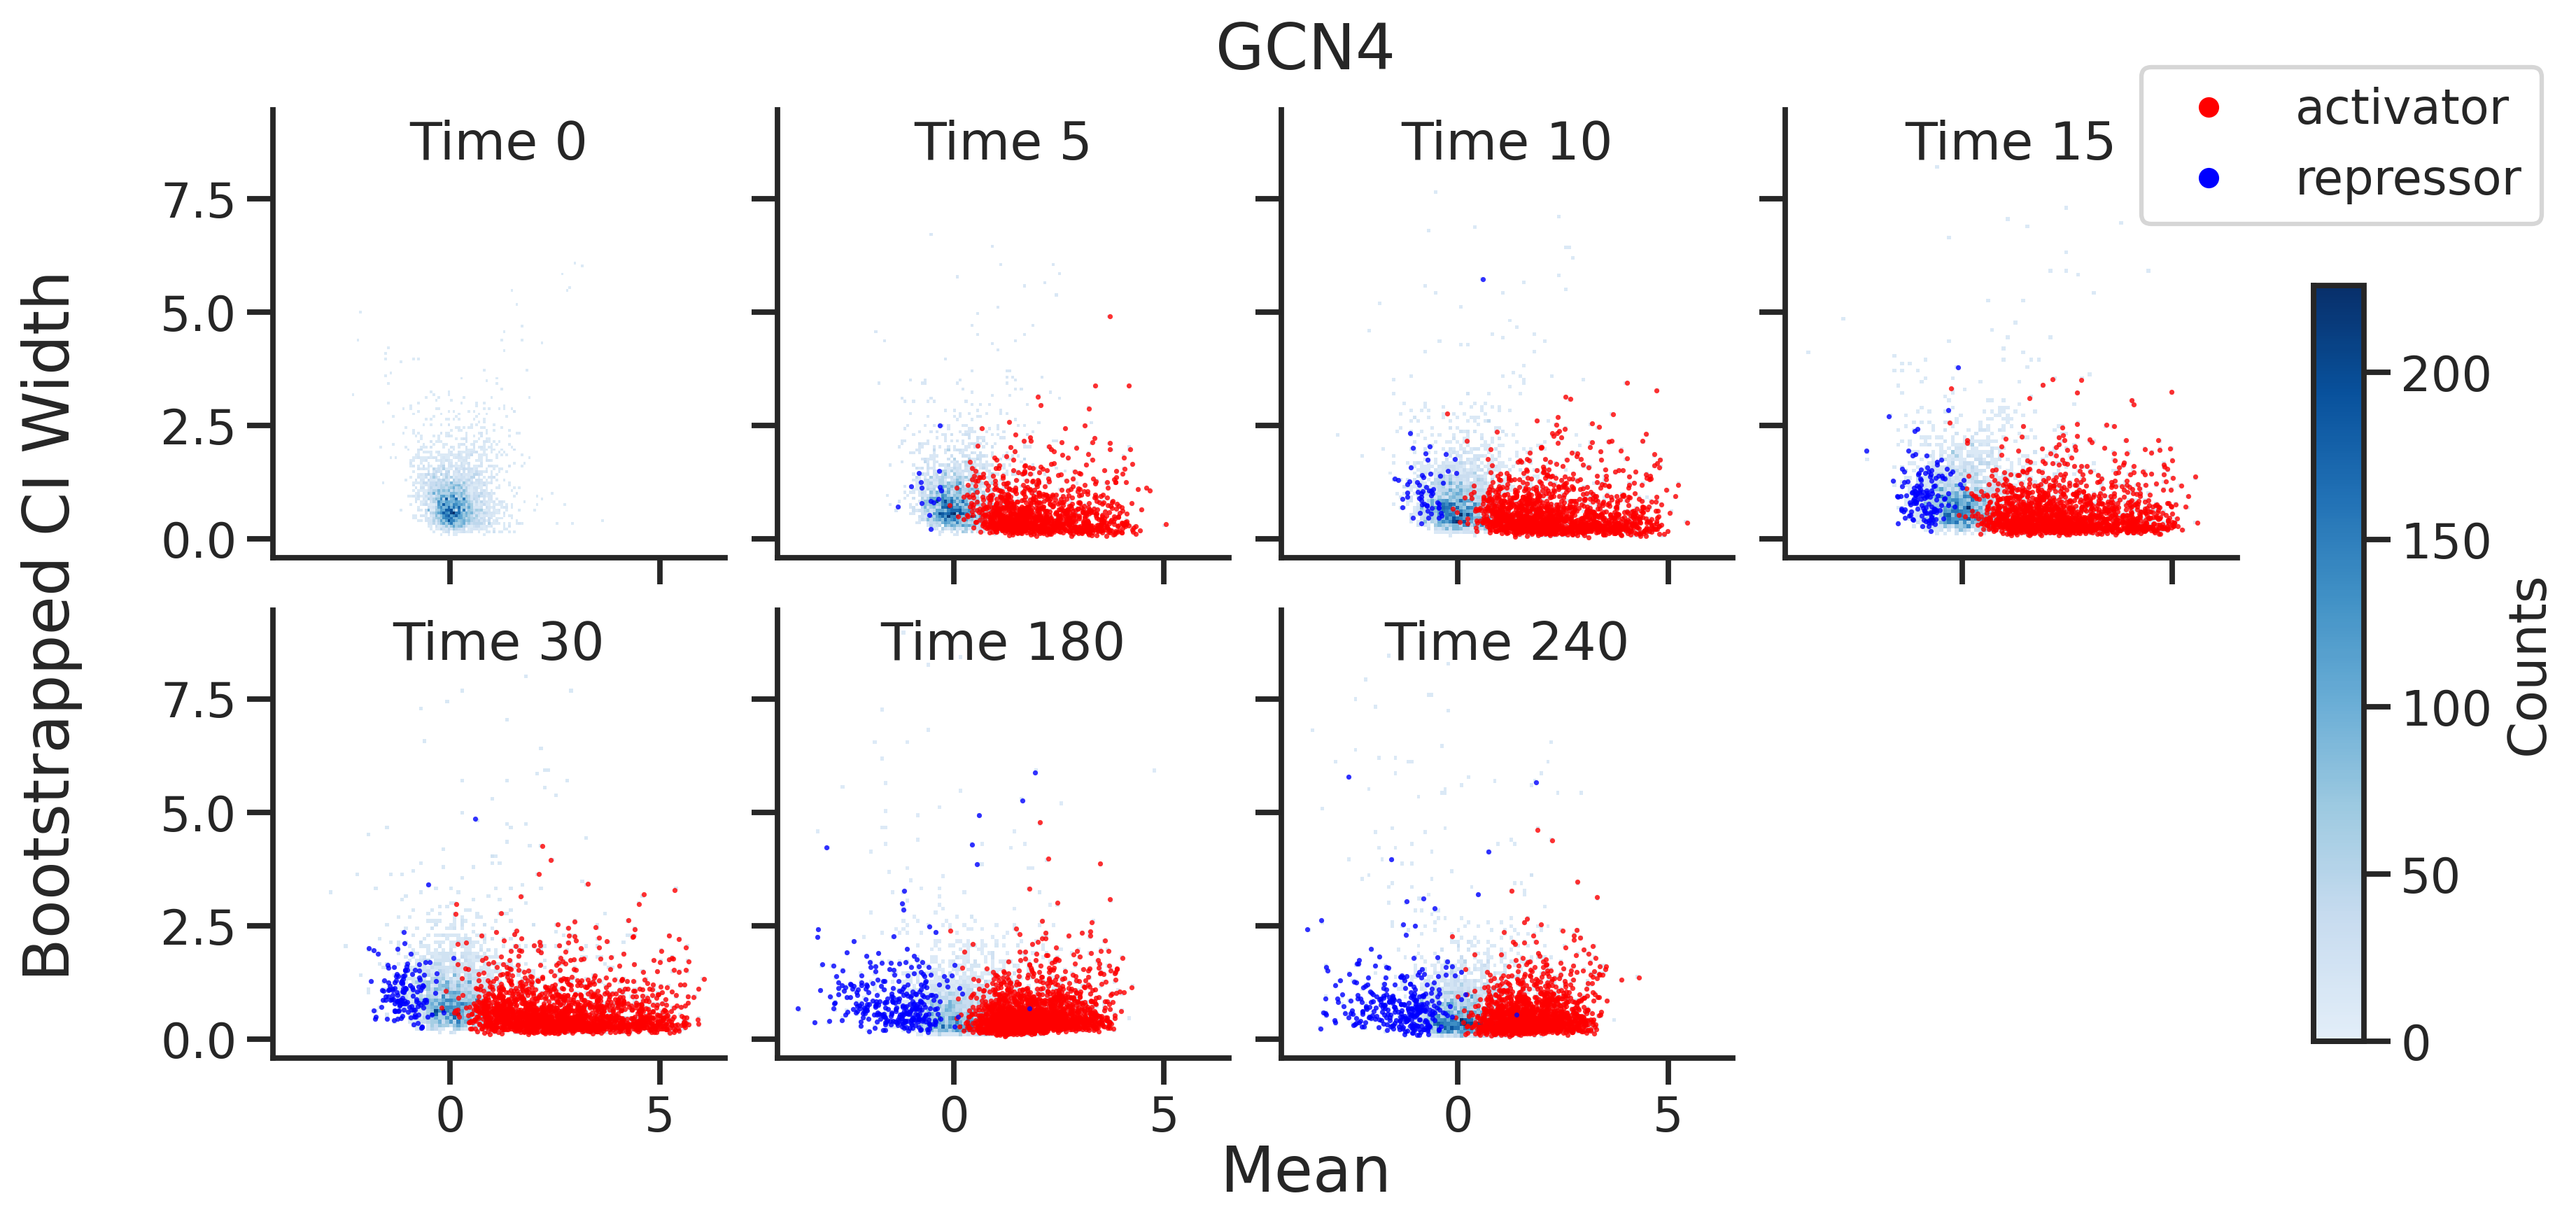

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib.lines import Line2D

sns.set_context("talk")
sns.set_style('ticks')

df = summary_with_class.copy()

def truncate_colormap(cmap, minval=0.15, maxval=1.0, n=256):
    new_colors = cmap(np.linspace(minval, maxval, n))
    return mpl.colors.LinearSegmentedColormap.from_list("trunc", new_colors)

cmap = truncate_colormap(mpl.cm.Blues, 0.1, 1.0)

clean = df[["mean", "error"]].replace([np.inf, -np.inf], np.nan).dropna()
counts, _, _ = np.histogram2d(clean["mean"], clean["error"], bins=80)
global_max = counts.max()

times = sorted(df["time"].unique())
n = len(times)
cols = min(4, n)
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows),
                         sharex=True, sharey=True, dpi=300)
axes = np.array(axes).reshape(-1)

for i, time in enumerate(times):
    ax = axes[i]
    subset = df[df["time"] == time]

    sns.histplot(
        data=subset,
        x="mean", y="error",
        bins=100, cmap=cmap, cbar=False,
        ax=ax
    )

    for cls, color in [("activator", "red"), ("repressor", "blue")]:
        grp = subset[subset["class"] == cls]
        if grp.empty:
            continue
        ax.scatter(
            grp["mean"], grp["error"],
            color=color, alpha=0.8, s=3,
            linewidths=0, zorder=5
        )

    ax.set_title(f"Time {time}", y=0.85)
    ax.set_xlabel("")
    ax.set_ylabel("")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.supxlabel("Mean", y=0.04)
fig.supylabel("Bootstrapped CI Width", x=-0.01)

sm = mpl.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=0, vmax=global_max),
    cmap=cmap
)
sm.set_array([])
cbar_ax = fig.add_axes([0.9, 0.17, 0.02, 0.6])
fig.colorbar(sm, cax=cbar_ax, label="Counts")

# legend for scatter classes
fig.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',   markersize=8, label='activator'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',  markersize=8, label='repressor'),
], loc="lower right", bbox_to_anchor=(1,0.8), frameon=True)

fig.suptitle("GCN4")
plt.tight_layout(rect=[0, 0, 0.88, 1], pad=0.5)
sns.despine()
plt.show()

# one sampling example# one sampling example

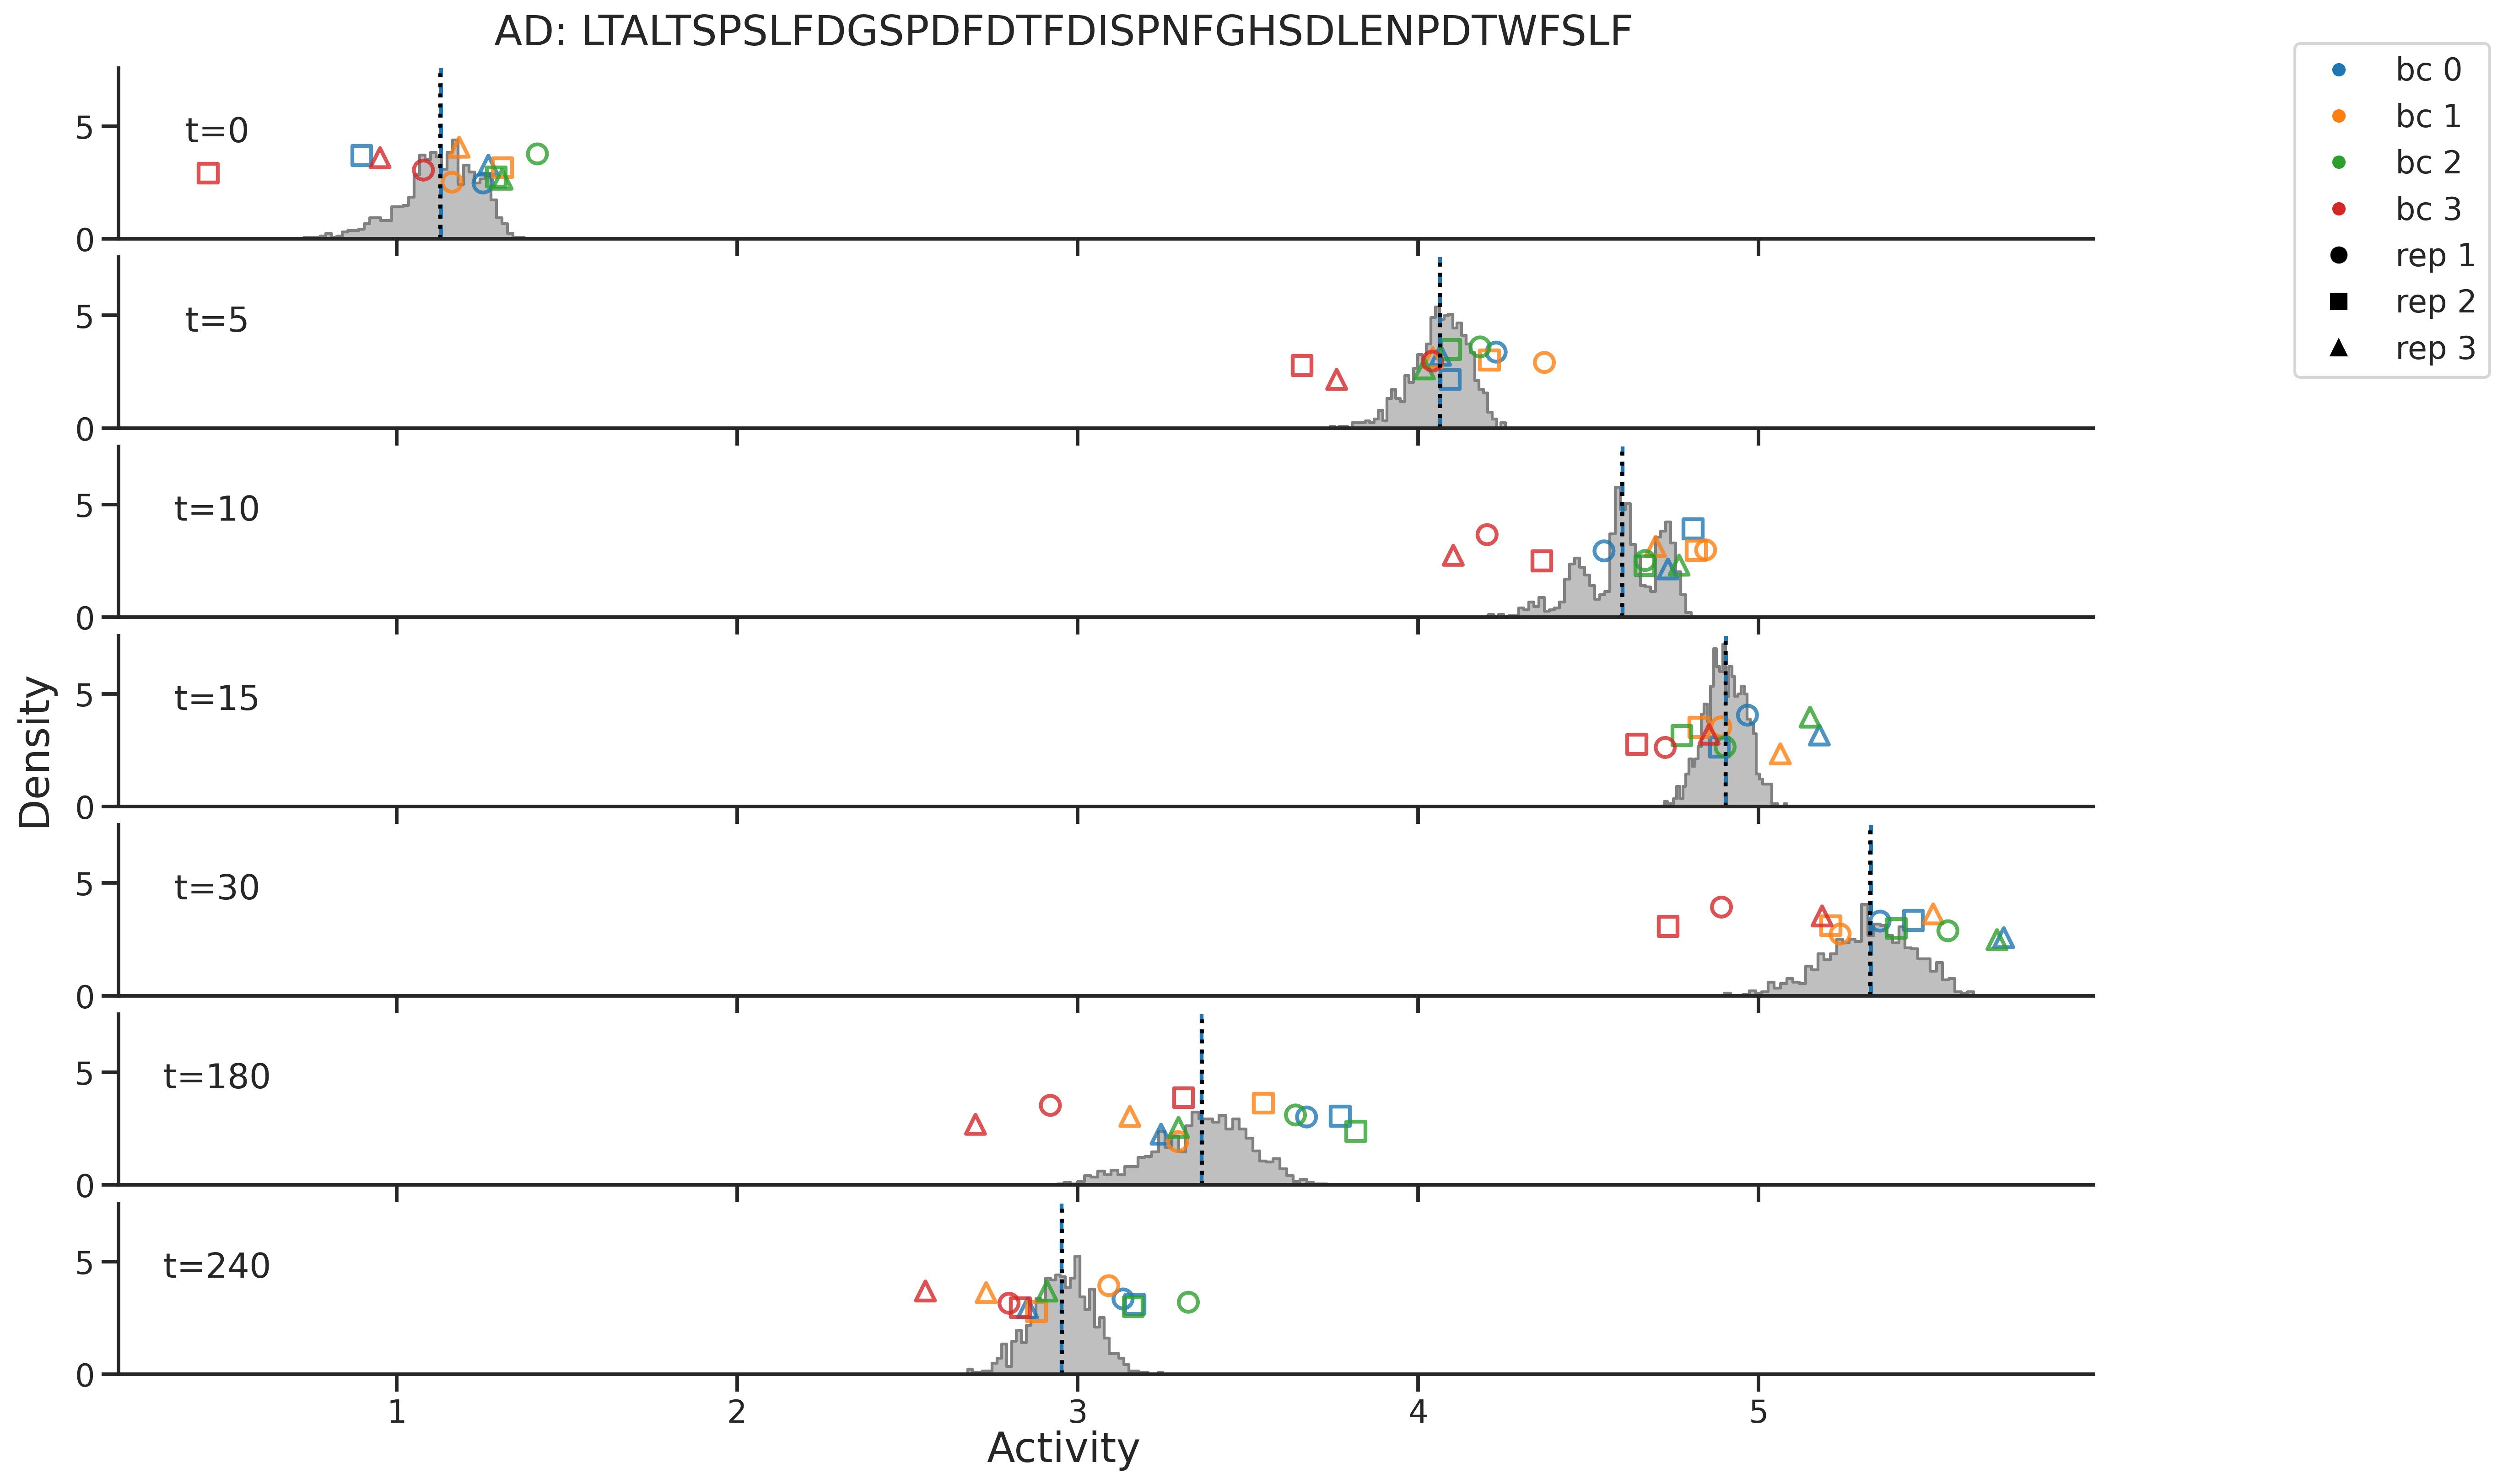

,ADseq,time,mean,ci_low,ci_hi,boot_samples,n_barcodes
0,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,0,1.127670,0.877033,1.299667,"[1.1279902, 1.109609, 1.0188614, 1.0730325, 1....",4
1,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,5,4.063951,3.886202,4.198459,"[4.0772862, 4.1130495, 4.0304074, 3.9456832, 4...",4
2,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,10,4.598917,4.333840,4.766784,"[4.610563, 4.638996, 4.6197033, 4.4694443, 4.6...",4
3,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,15,4.902380,4.785529,5.016091,"[4.9068213, 4.8325043, 4.85608, 4.8623066, 4.8...",4
4,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,30,5.327139,5.054395,5.553947,"[5.3509927, 5.2674356, 5.347261, 5.2571707, 5....",4
5,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,180,3.365460,3.062225,3.601419,"[3.3356647, 3.4805803, 3.5255058, 3.2518127, 3...",4
6,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,240,2.954624,2.771605,3.116772,"[2.9818668, 3.062927, 3.0437398, 2.8954546, 2....",4


In [200]:
AD = "LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF"
AD_df = df_filtered[df_filtered["ADseq"] ==AD]
_bootstrap_one_ad(AD, AD_df, 1000, 42, plot = True)

# Mean activity over time

In [201]:
summary.groupby("time")["mean"].mean()

time
0      0.138461
5      0.666671
10     0.904980
15     0.978951
30     1.213183
180    0.740397
240    0.577656
Name: mean, dtype: float32

100%|██████████| 7/7 [00:00<00:00, 40.01it/s]


(<Figure size 2400x3600 with 7 Axes>,
 array([<Axes: ylabel='0 min.'>, <Axes: ylabel='5 min.'>,
        <Axes: ylabel='10 min.'>, <Axes: ylabel='15 min.'>,
        <Axes: ylabel='30 min.'>, <Axes: ylabel='180 min.'>,
        <Axes: ylabel='240 min.'>], dtype=object))

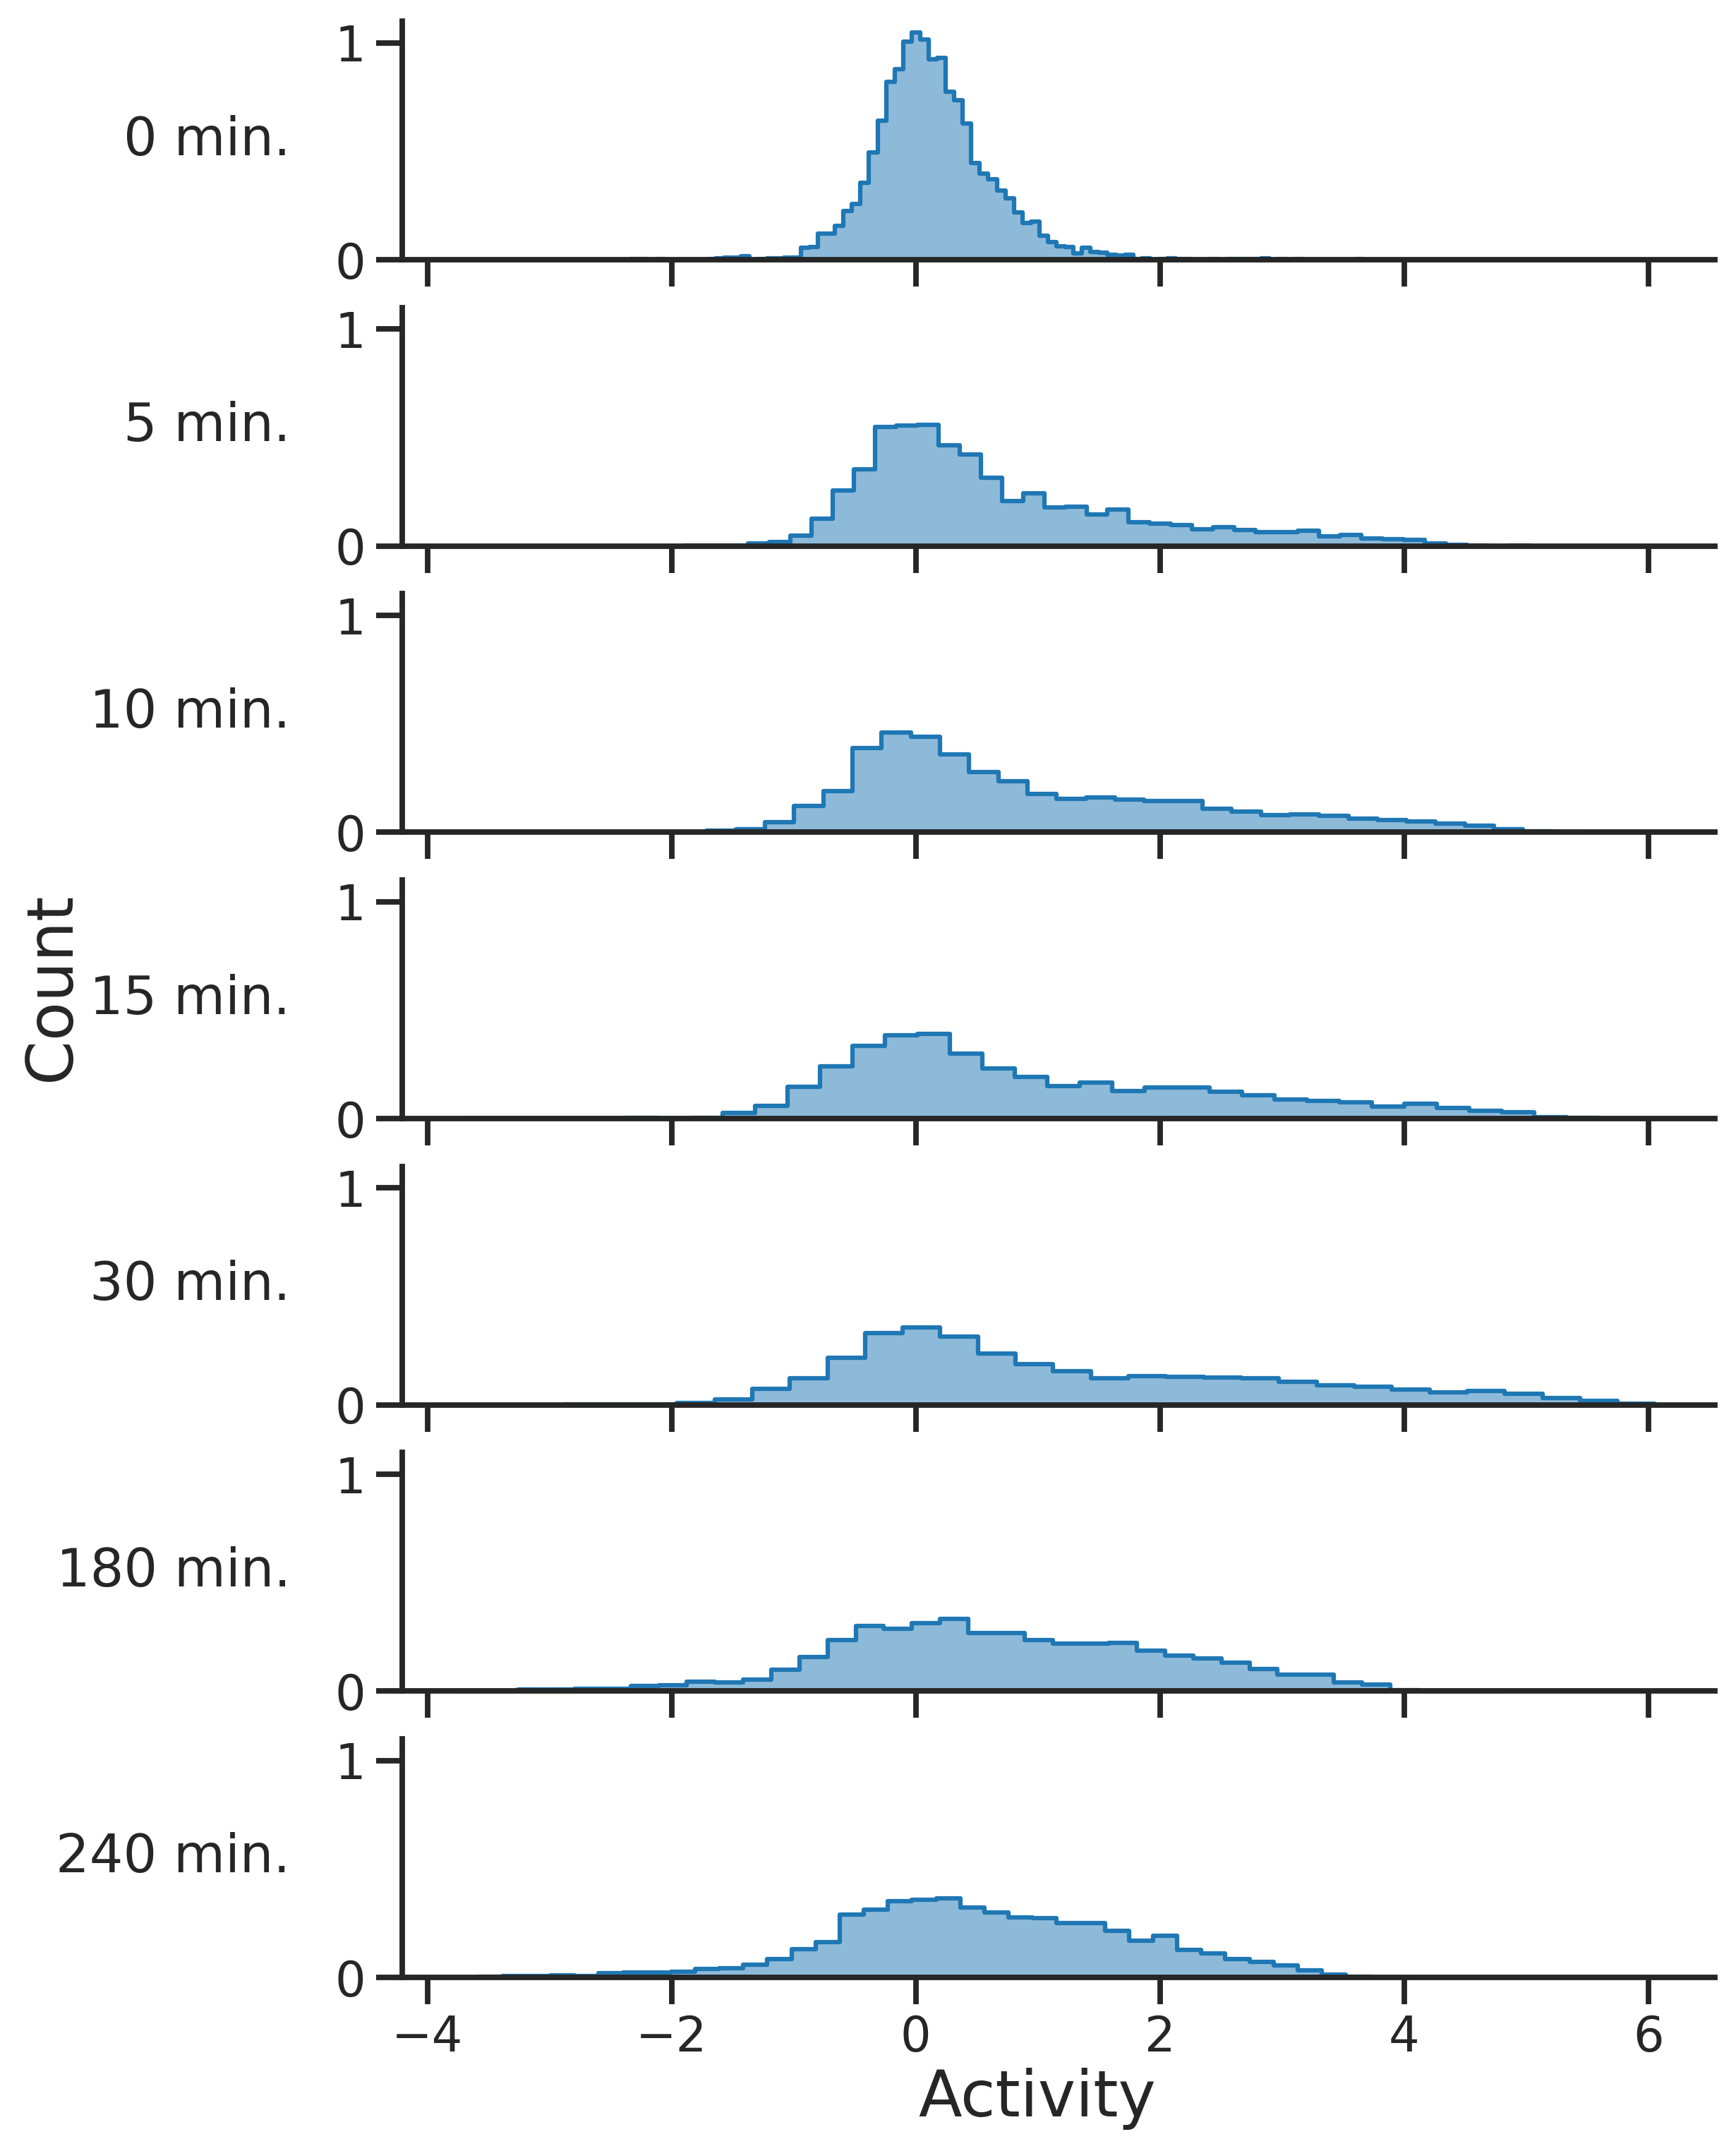

In [202]:
time_normalization_helpers.plot_hists_over_time(summary, column = "mean")

# Plotting controls

In [203]:
chopTF_controls = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/chopTFs_controls.csv", index_col = 0)
chopTF_controls.head()

,ADseq,Name,group
59,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2
65,TDAIDEEVLMSLVIEMGLDRIKELPELALGQNEADAMTDA,CITED2_ARO2A_0,CITED2
63,TDFIDEEVAMSAVIEMGADRIKEAPEAWAGQNEFDFMTDF,CITED2_L2A_0,CITED2
61,TDFIDEEVIMSIVIEMGIDRIKEIPEIWIGQNEFDFMTDF,CITED2_L2I_0,CITED2
67,TDAIDEEVAMSAVIEMGADRIKEAPEAAAGQNEADAMTDA,CITED2_LWF2A_0,CITED2


CITED2_0


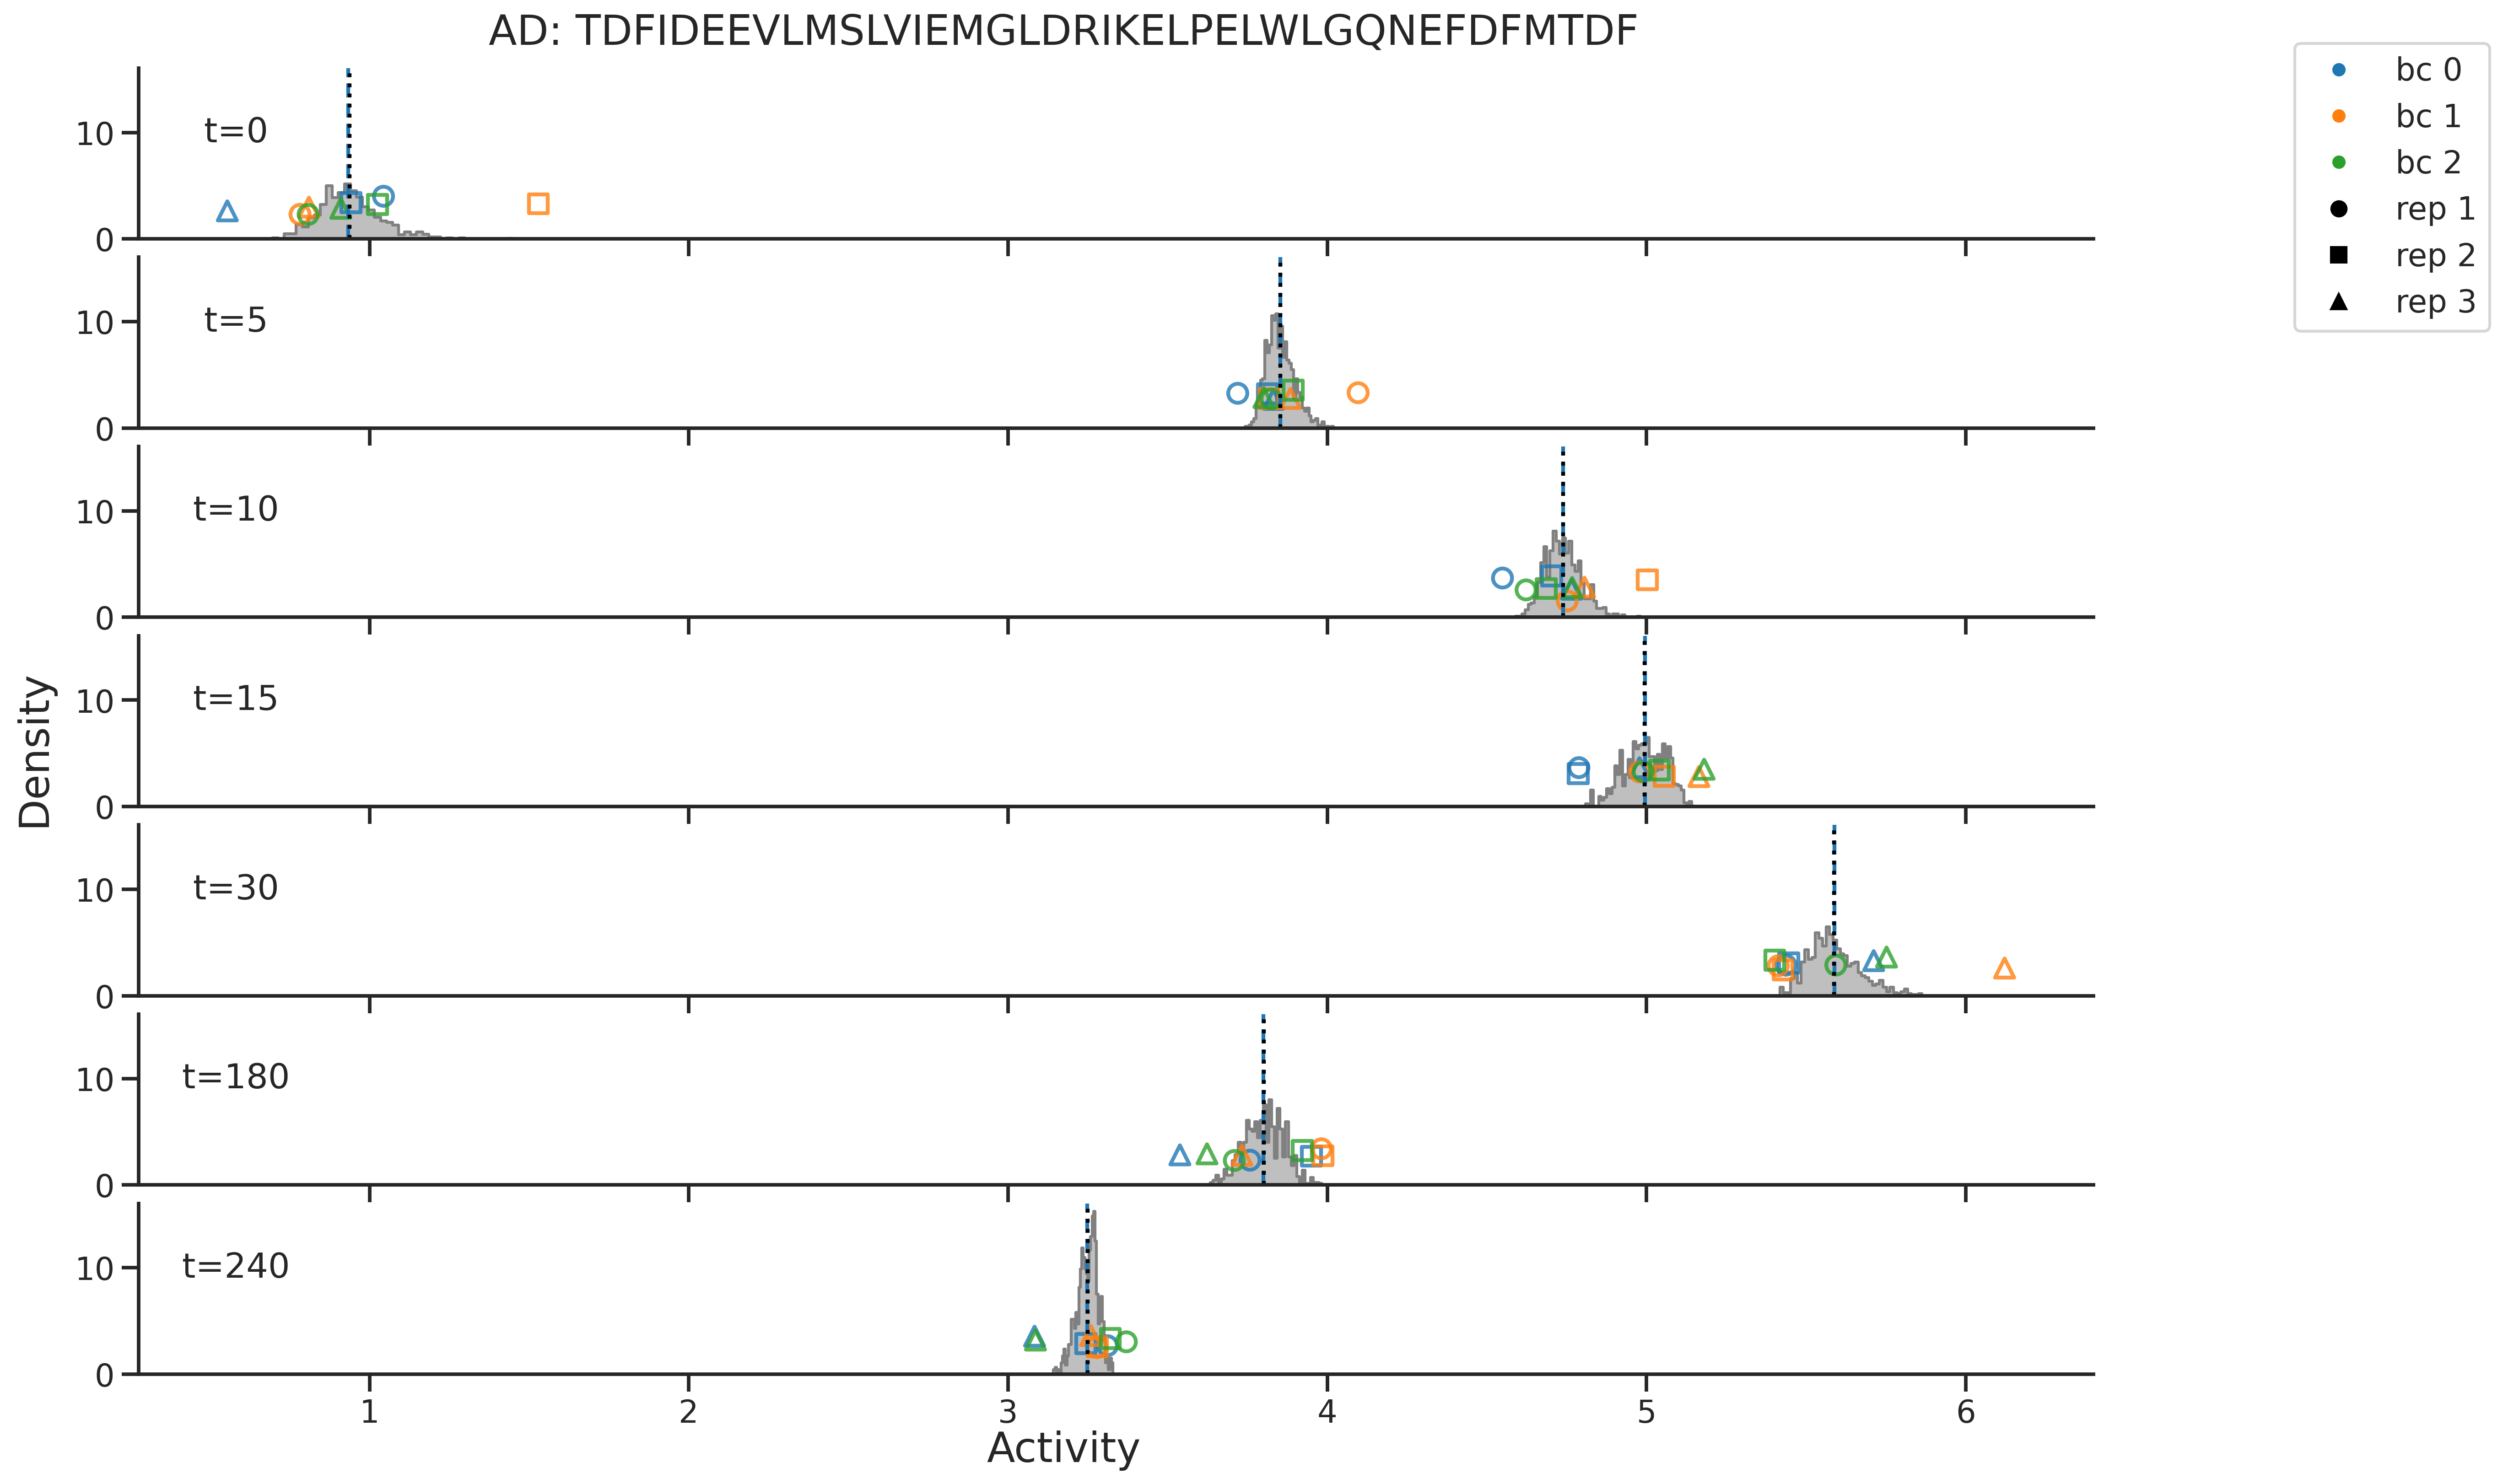

CITED2_ARO2A_0


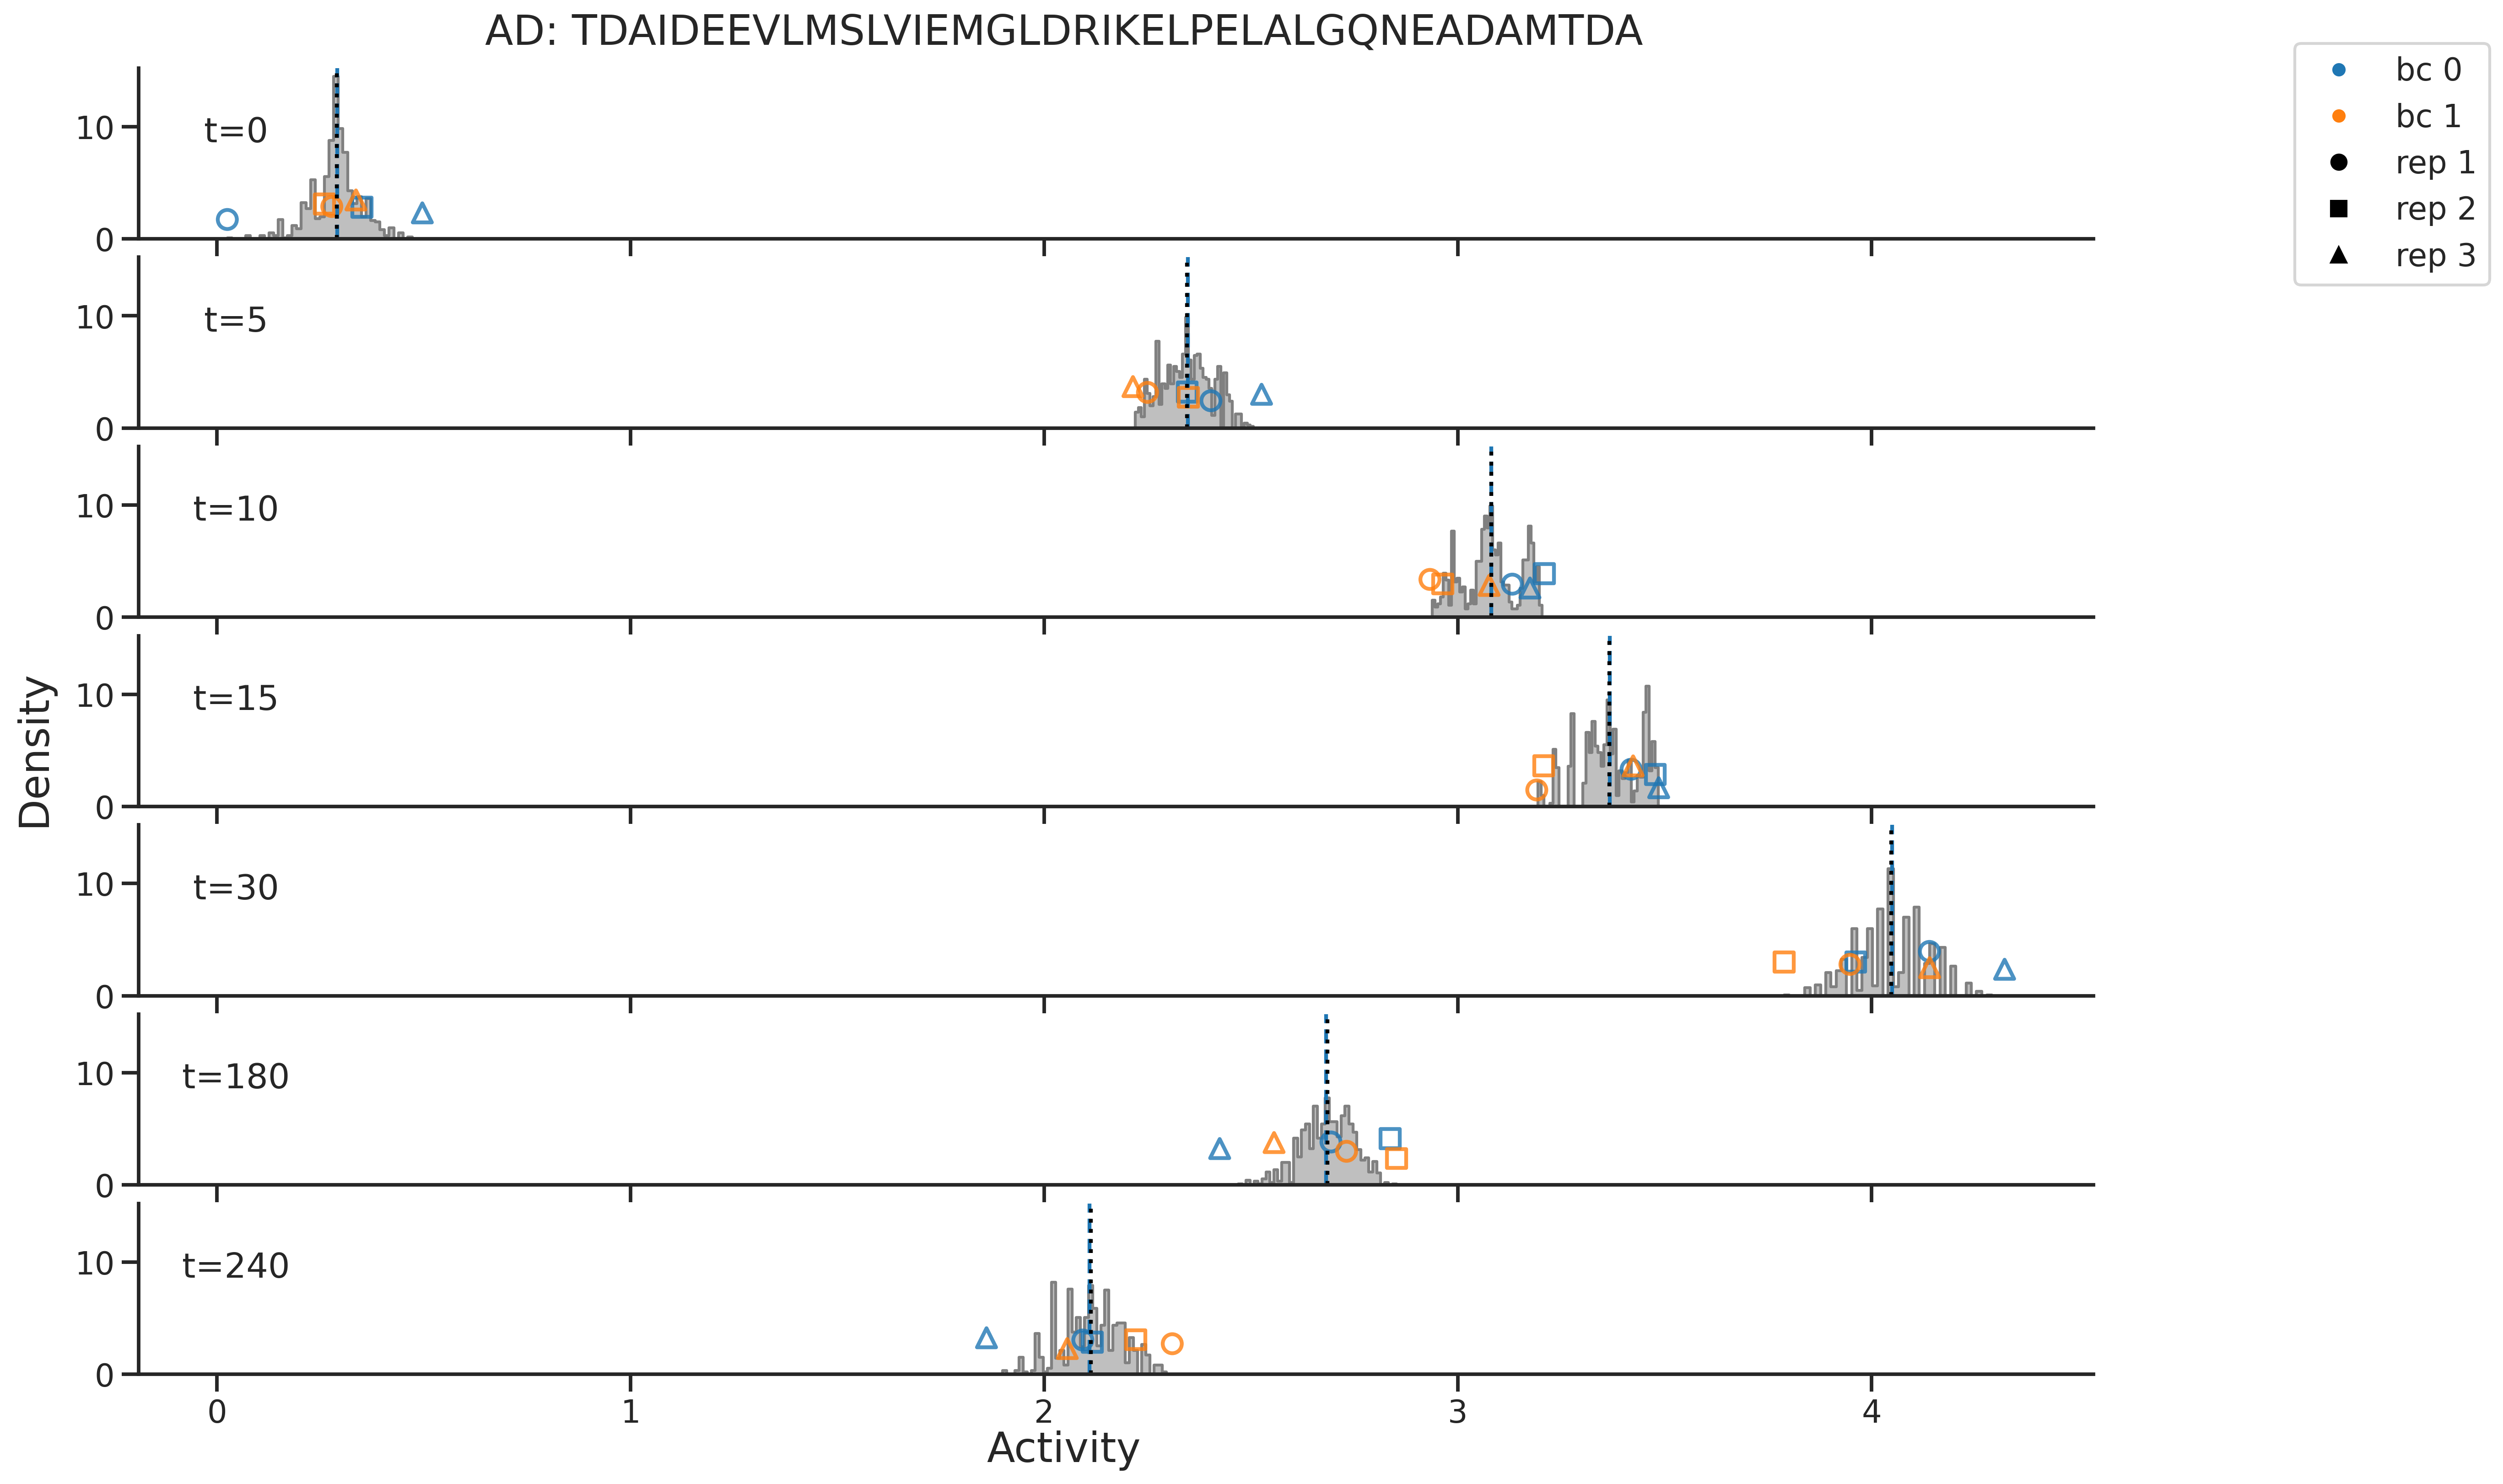

CITED2_L2A_0
CITED2_L2I_0


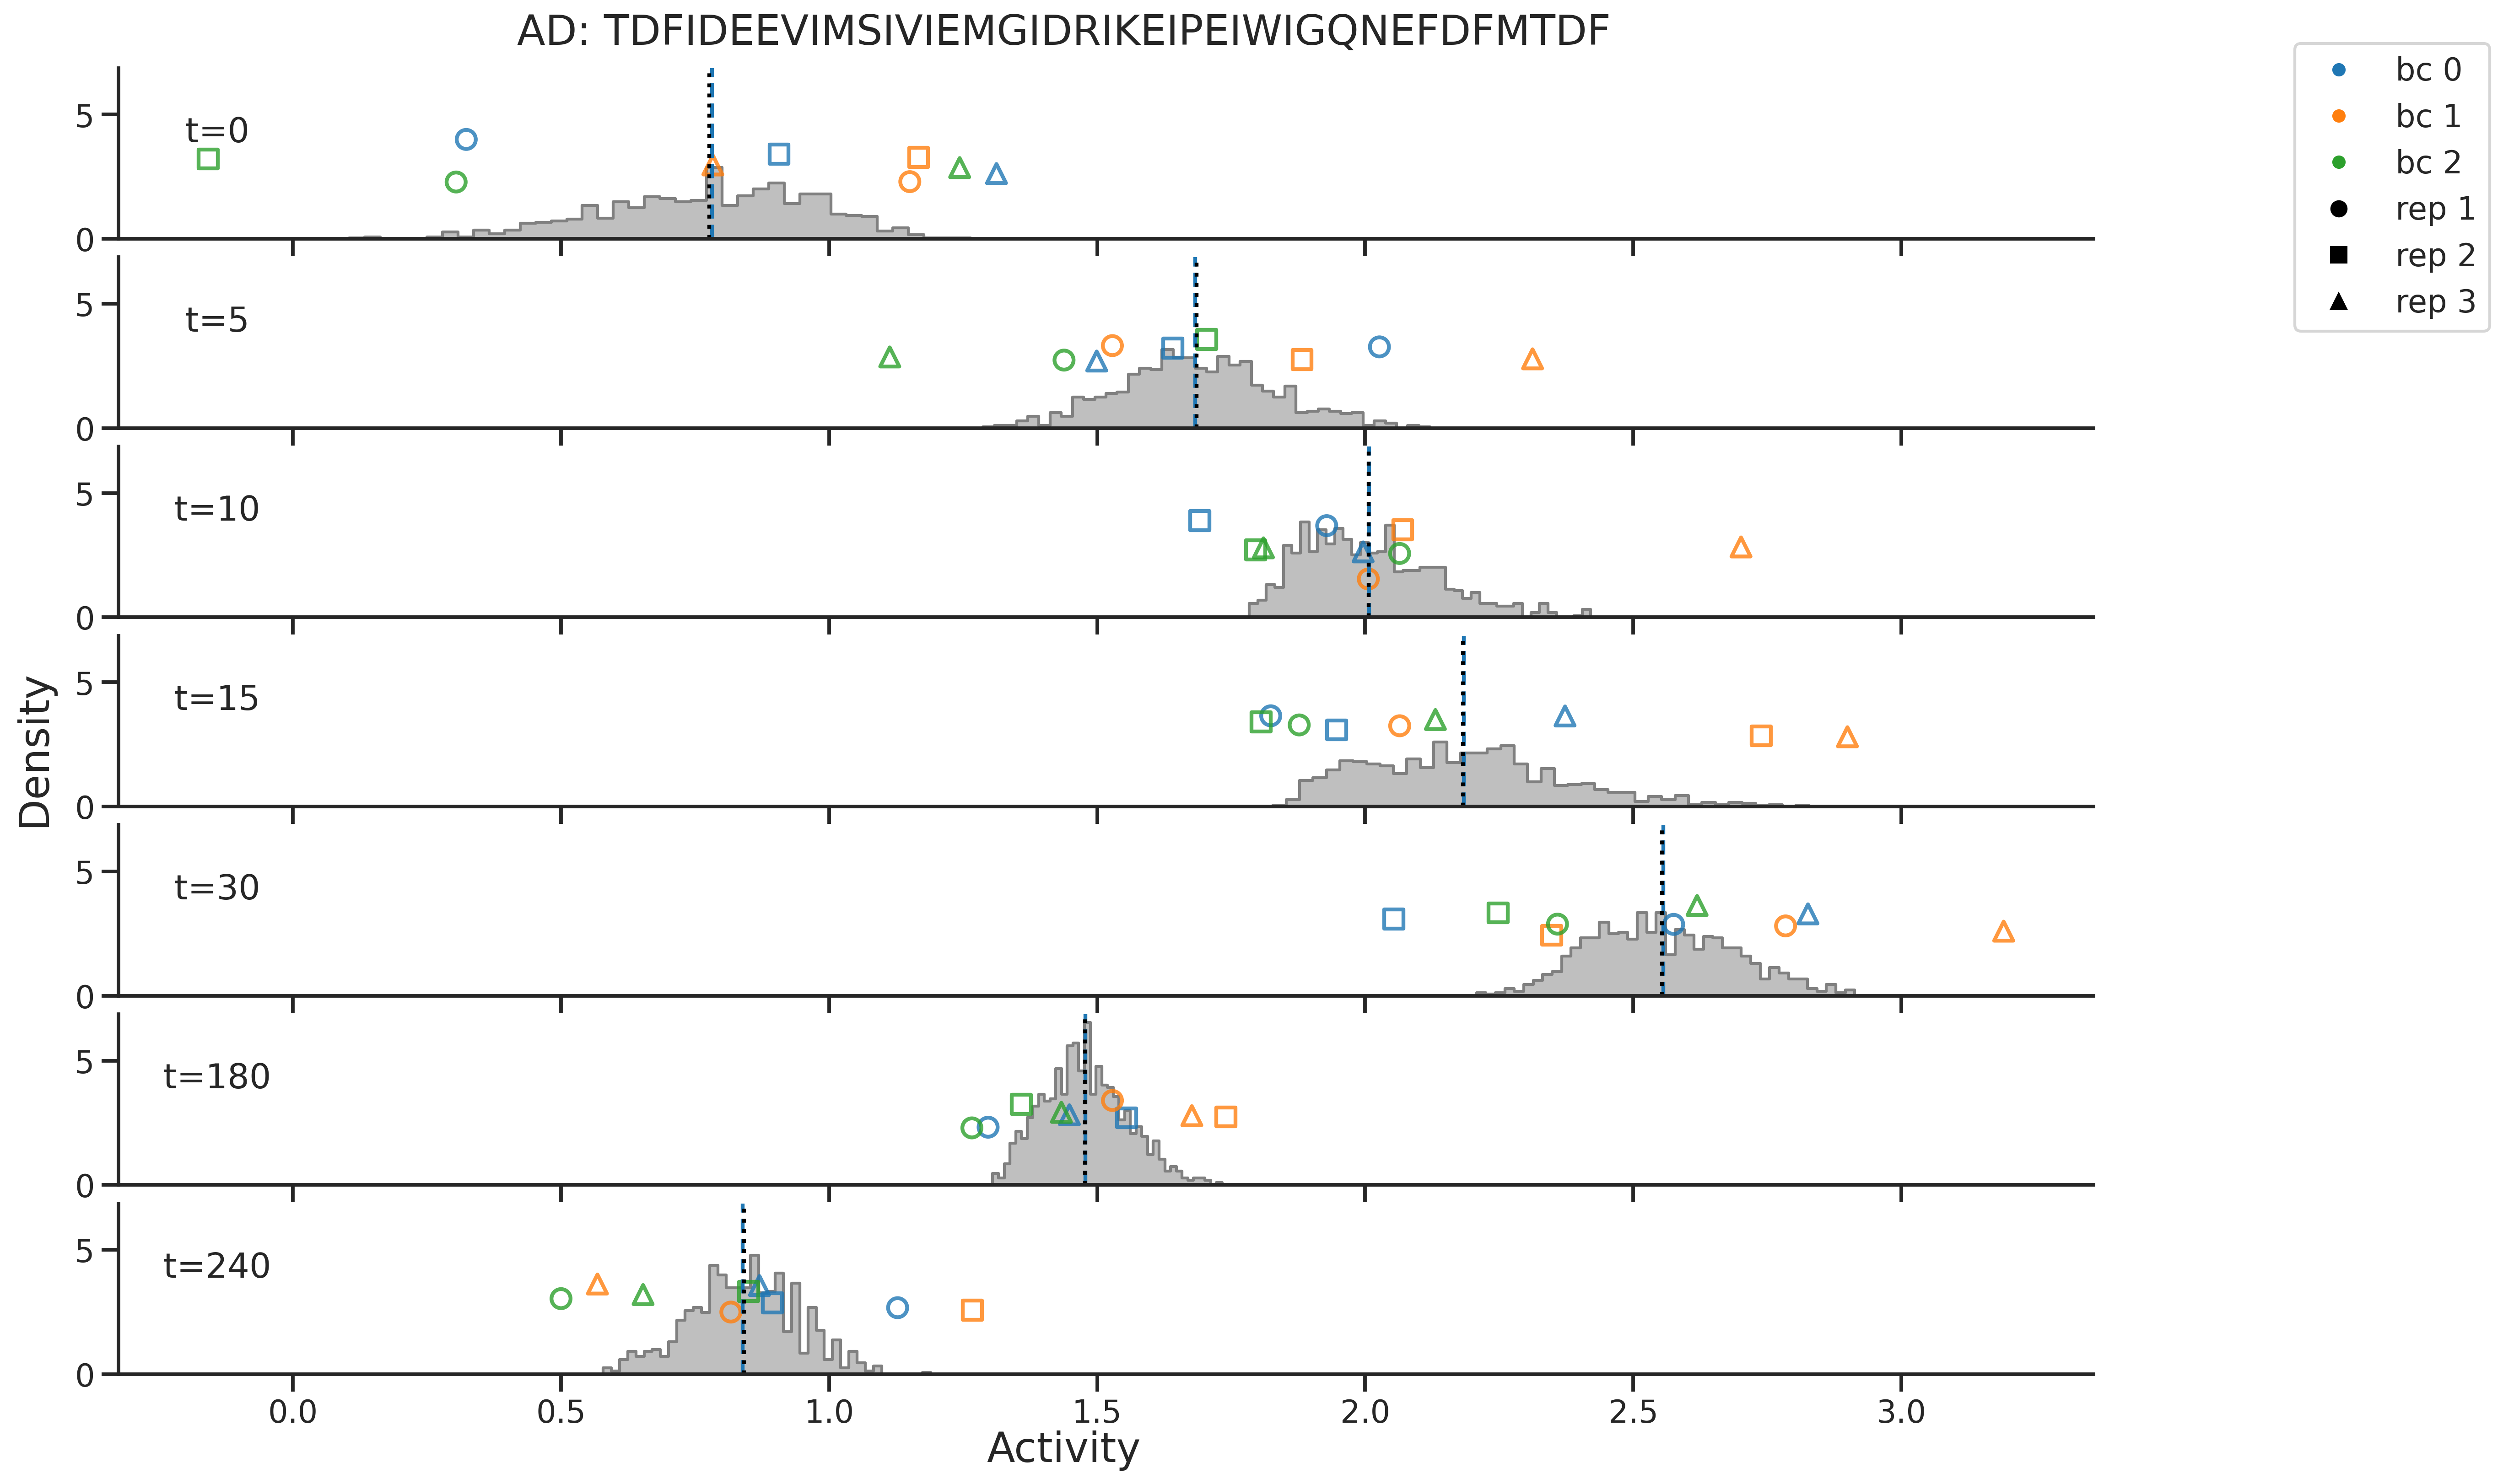

CITED2_LWF2A_0


In [204]:
CITED_controls = chopTF_controls[chopTF_controls["group"] == "CITED2"]

for AD, name in zip(CITED_controls["ADseq"], CITED_controls["Name"]):
    print(name)
    AD_df = dbd_norm_activities[dbd_norm_activities["ADseq"] ==AD]
    _bootstrap_one_ad(AD, AD_df, 1000, 42, plot = True)

In [205]:
chopTF_controls_all_meas = pd.merge(chopTF_controls, dbd_norm_activities).dropna()
chopTF_controls_all_meas

,ADseq,Name,group,AD_BC,RPTR_BC,time,rep,shifted_activity
0,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,CCCGCTAACAC,ATCGTAGCCTTAAA,10,1,4.622520
1,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,ACCTCCGTGTG,TCTGAGTCCAAATC,10,1,4.548640
2,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,ATTCGTGCGAG,CGGCAATCTGACCG,10,1,4.751343
3,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,CCCGCTAACAC,ATCGTAGCCTTAAA,30,1,5.592674
4,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,ACCTCCGTGTG,TCTGAGTCCAAATC,30,1,5.436522
...,...,...,...,...,...,...,...,...
1990,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,Sordariomycetes_jgi|Neucr4830_1|444994|fgenesh...,yeast_orthologs,TATAGCACTCG,TGAGGACCACACCG,180,1,2.919634
1991,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,Sordariomycetes_jgi|Neucr4830_1|444994|fgenesh...,yeast_orthologs,GCTAGTTTAGA,ATGCTTCGTAGCTA,15,1,4.901385
1992,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,Sordariomycetes_jgi|Neucr4830_1|444994|fgenesh...,yeast_orthologs,GAAGATGTCAC,AGAAGCACCTAATG,15,1,4.888989
1993,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,Sordariomycetes_jgi|Neucr4830_1|444994|fgenesh...,yeast_orthologs,AAAACAAGCAC,AAAACTTAGTGGAT,15,1,4.967051


In [206]:
chopTF_controls_meas = pd.merge(chopTF_controls, summary).dropna()
chopTF_controls_meas

,ADseq,Name,group,time,mean,ci_low,ci_hi,boot_samples,n_barcodes,error
0,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,0,0.934307,0.773957,1.139648,"[1.0634799, 0.95429283, 0.9881738, 1.072502, 0...",3,0.365692
1,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,5,3.852252,3.782798,3.947681,"[3.8471982, 3.8339472, 3.8408787, 3.8148444, 3...",3,0.164884
2,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,10,4.738112,4.645004,4.856053,"[4.7803025, 4.725451, 4.7148623, 4.8148804, 4....",3,0.211049
3,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,15,4.994051,4.850524,5.105284,"[5.0827427, 4.900713, 4.9742455, 5.0070353, 4....",3,0.254760
4,TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF,CITED2_0,CITED2,30,5.587602,5.459008,5.766992,"[5.586267, 5.5424104, 5.558352, 5.5533295, 5.6...",3,0.307984
...,...,...,...,...,...,...,...,...,...,...
191,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,Sordariomycetes_jgi|Neucr4830_1|444994|fgenesh...,yeast_orthologs,10,4.600479,4.340860,4.770399,"[4.7215543, 4.7535973, 4.6236725, 4.71623, 4.4...",4,0.429539
192,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,Sordariomycetes_jgi|Neucr4830_1|444994|fgenesh...,yeast_orthologs,15,4.904188,4.783234,5.019527,"[4.9065895, 4.882663, 4.8942633, 5.0009737, 4....",4,0.236293
193,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,Sordariomycetes_jgi|Neucr4830_1|444994|fgenesh...,yeast_orthologs,30,5.329021,5.055631,5.551834,"[5.36861, 5.3396664, 5.2958345, 5.531919, 5.24...",4,0.496203
194,LTALTSPSLFDGSPDFDTFDISPNFGHSDLENPDTWFSLF,Sordariomycetes_jgi|Neucr4830_1|444994|fgenesh...,yeast_orthologs,180,3.362981,3.066945,3.611866,"[3.5198865, 3.4732046, 3.290757, 3.460321, 3.2...",4,0.544921


In [207]:
df_filtered_grouped = pd.DataFrame(df_filtered.groupby(["ADseq", "time", "AD_BC", "RPTR_BC"])["shifted_activity"].mean()).reset_index()
df_filtered_grouped = df_filtered_grouped[df_filtered_grouped["time"] <= 30]
df_filtered_grouped

,ADseq,time,AD_BC,RPTR_BC,shifted_activity
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,ACAGTTAACGT,GCCATTCACCGAAA,-0.323829
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,CTTTGTCCCTT,CTCTCGTCCCTCTC,-0.739655
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,ACAGTTAACGT,GCCATTCACCGAAA,0.385425
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,CTTTGTCCCTT,CTCTCGTCCCTCTC,-0.311501
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,ACAGTTAACGT,GCCATTCACCGAAA,0.551114
...,...,...,...,...,...
65505,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,GCGTGTACGAG,TCCATGTCAGTGAA,-0.025623
65506,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,ATTATAGCATT,TTAAAGTCTCTATG,-0.152937
65507,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,GCGTGTACGAG,TCCATGTCAGTGAA,0.313669
65508,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,30,ATTATAGCATT,TTAAAGTCTCTATG,-0.147659


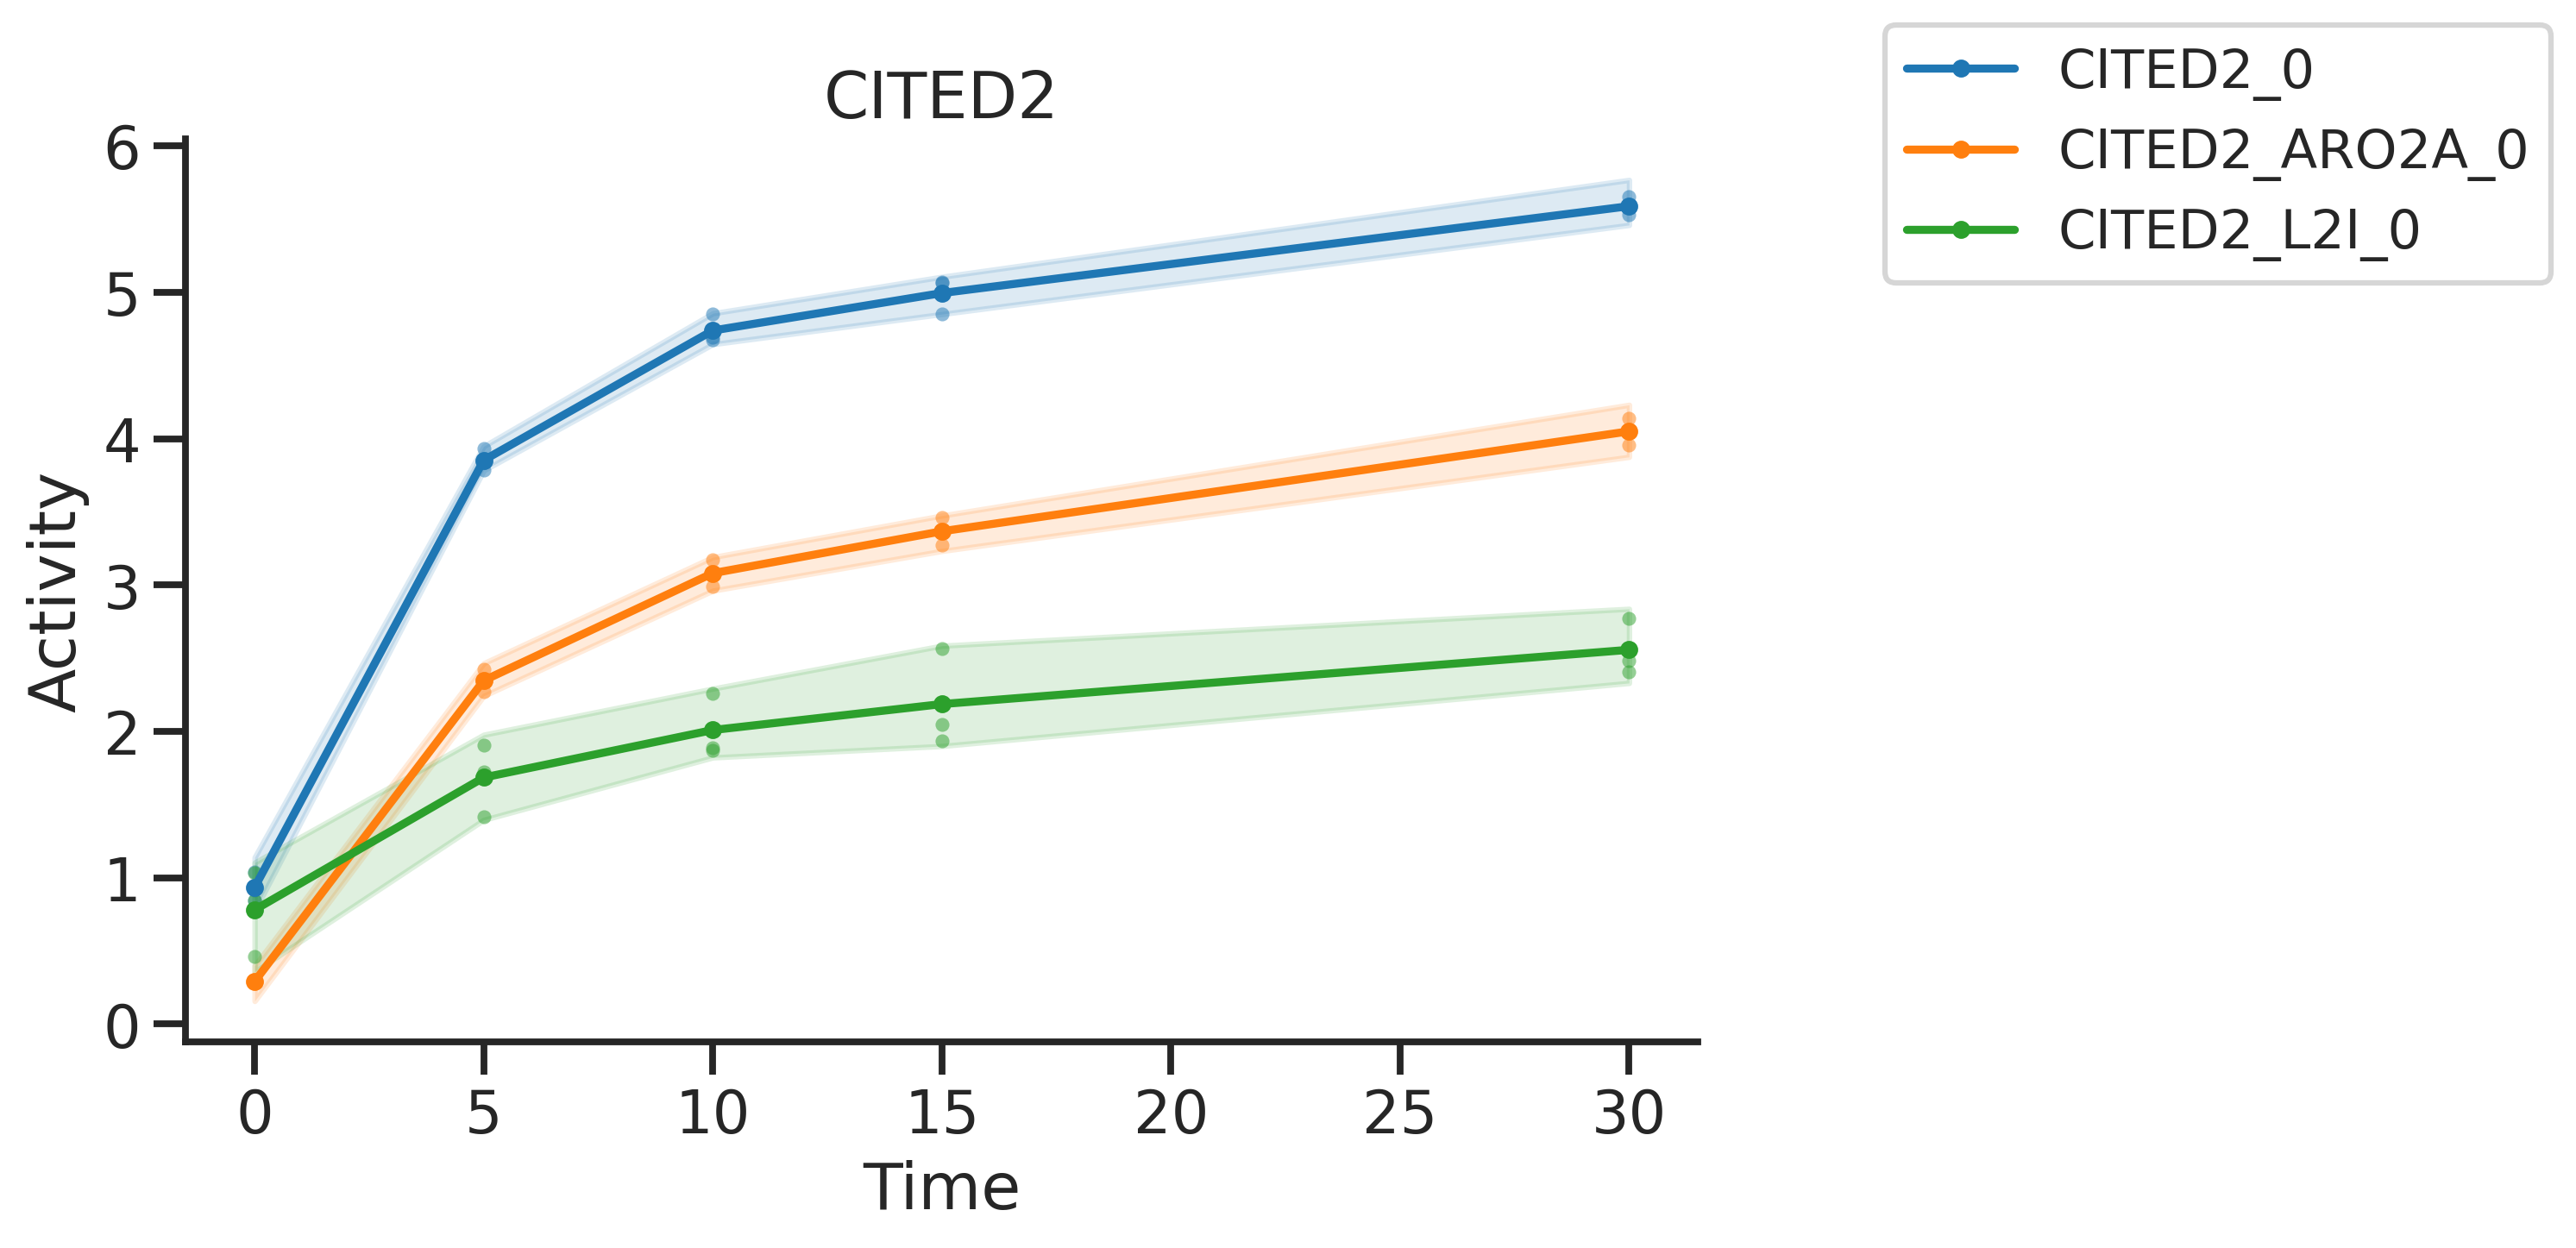

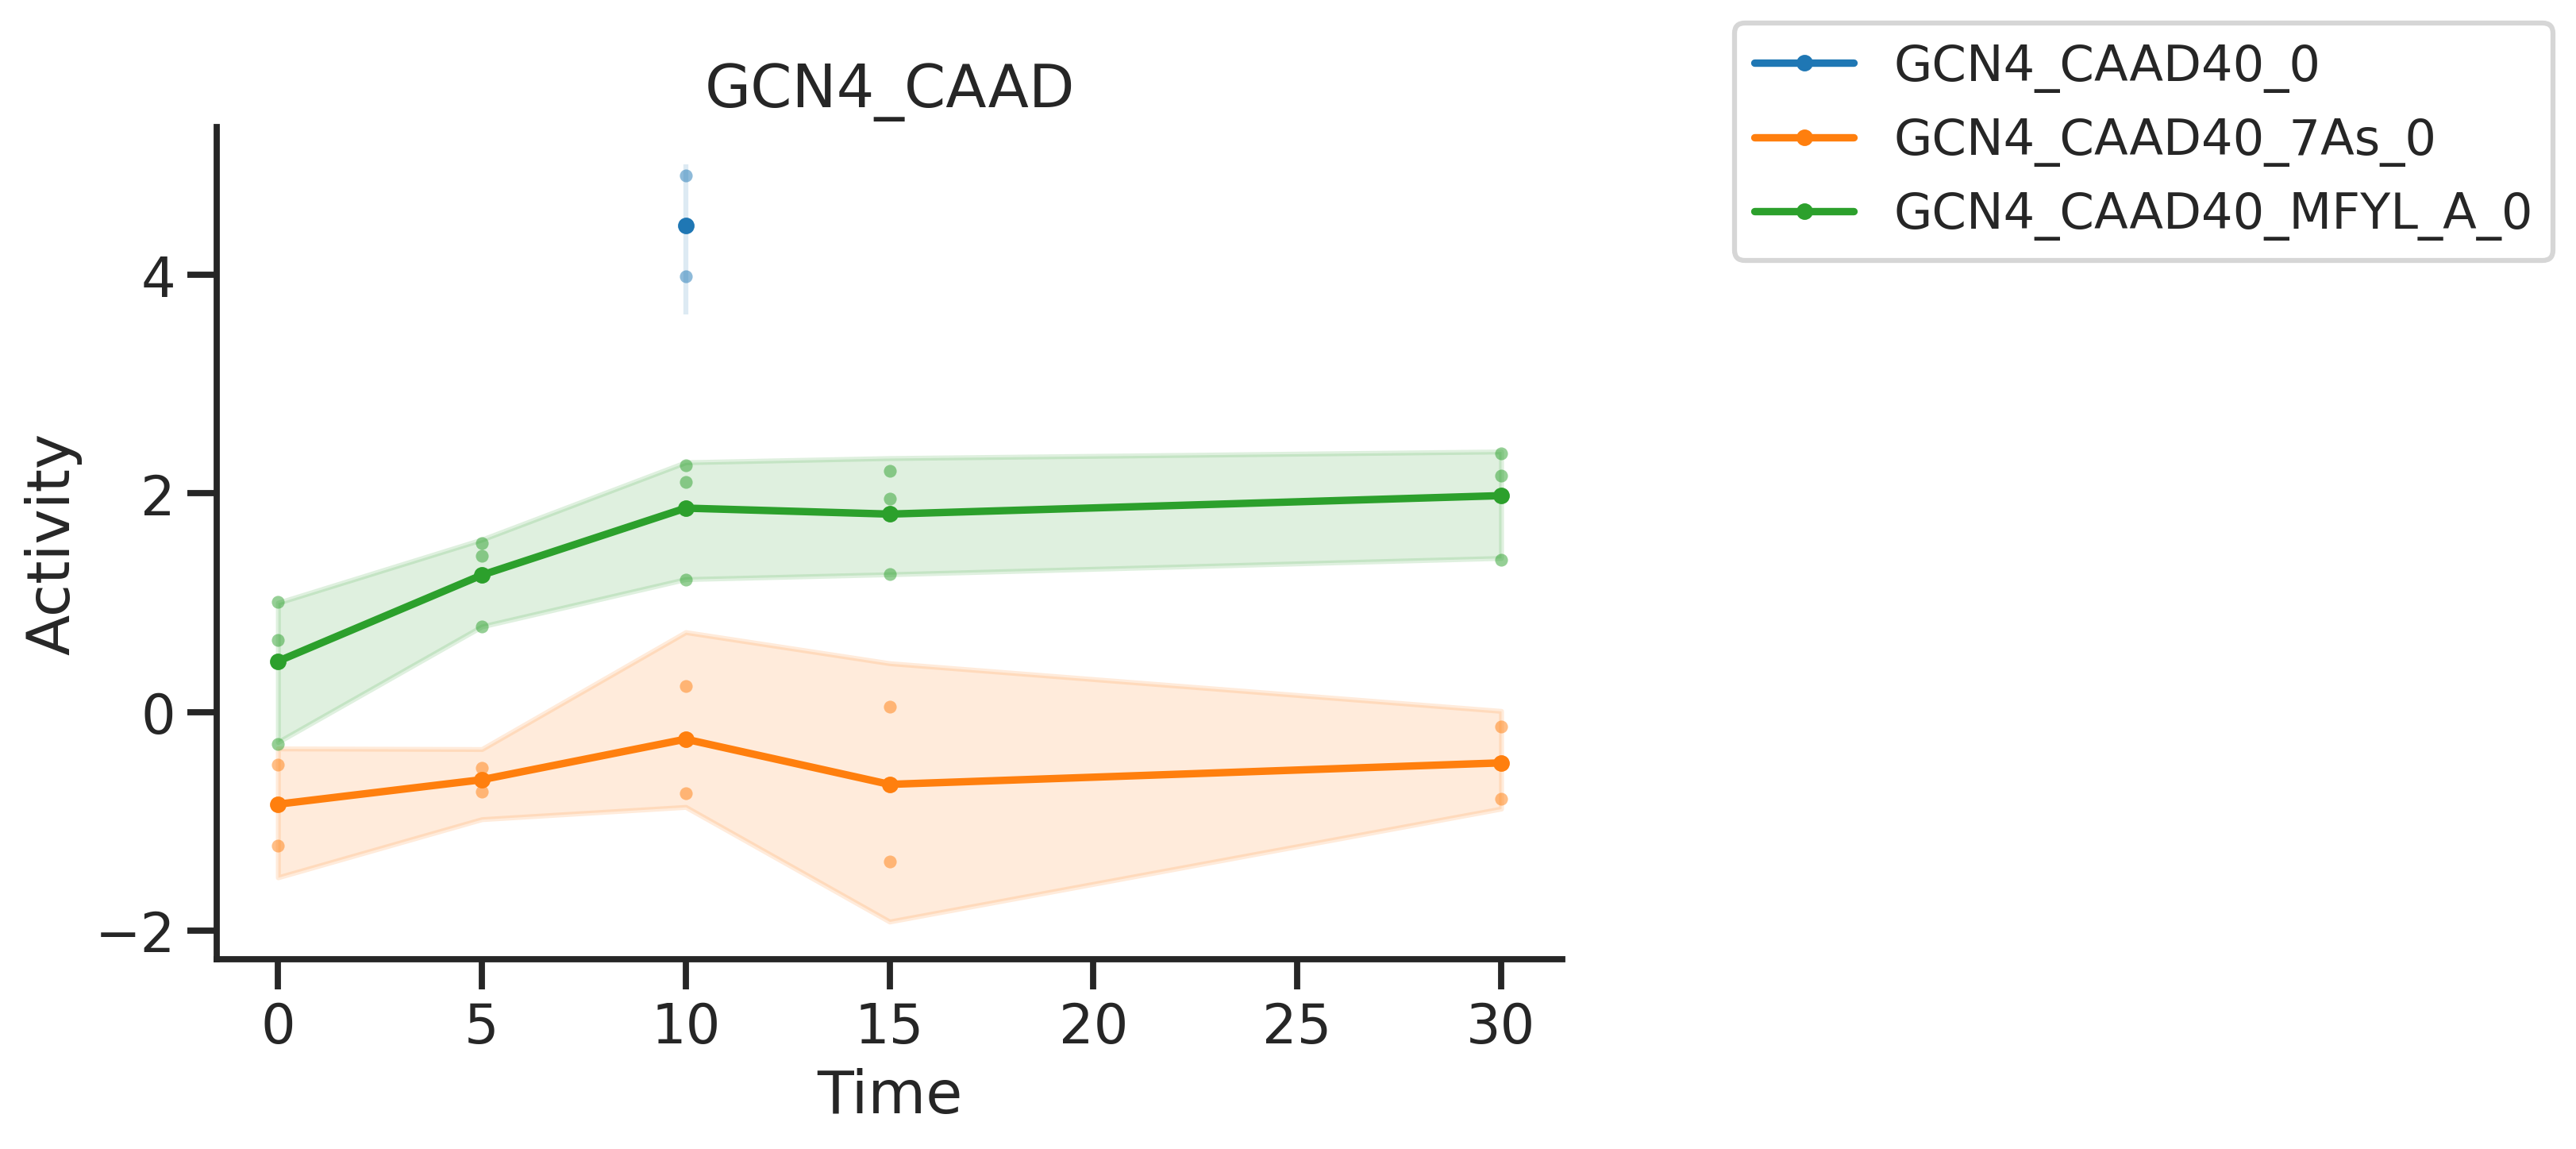

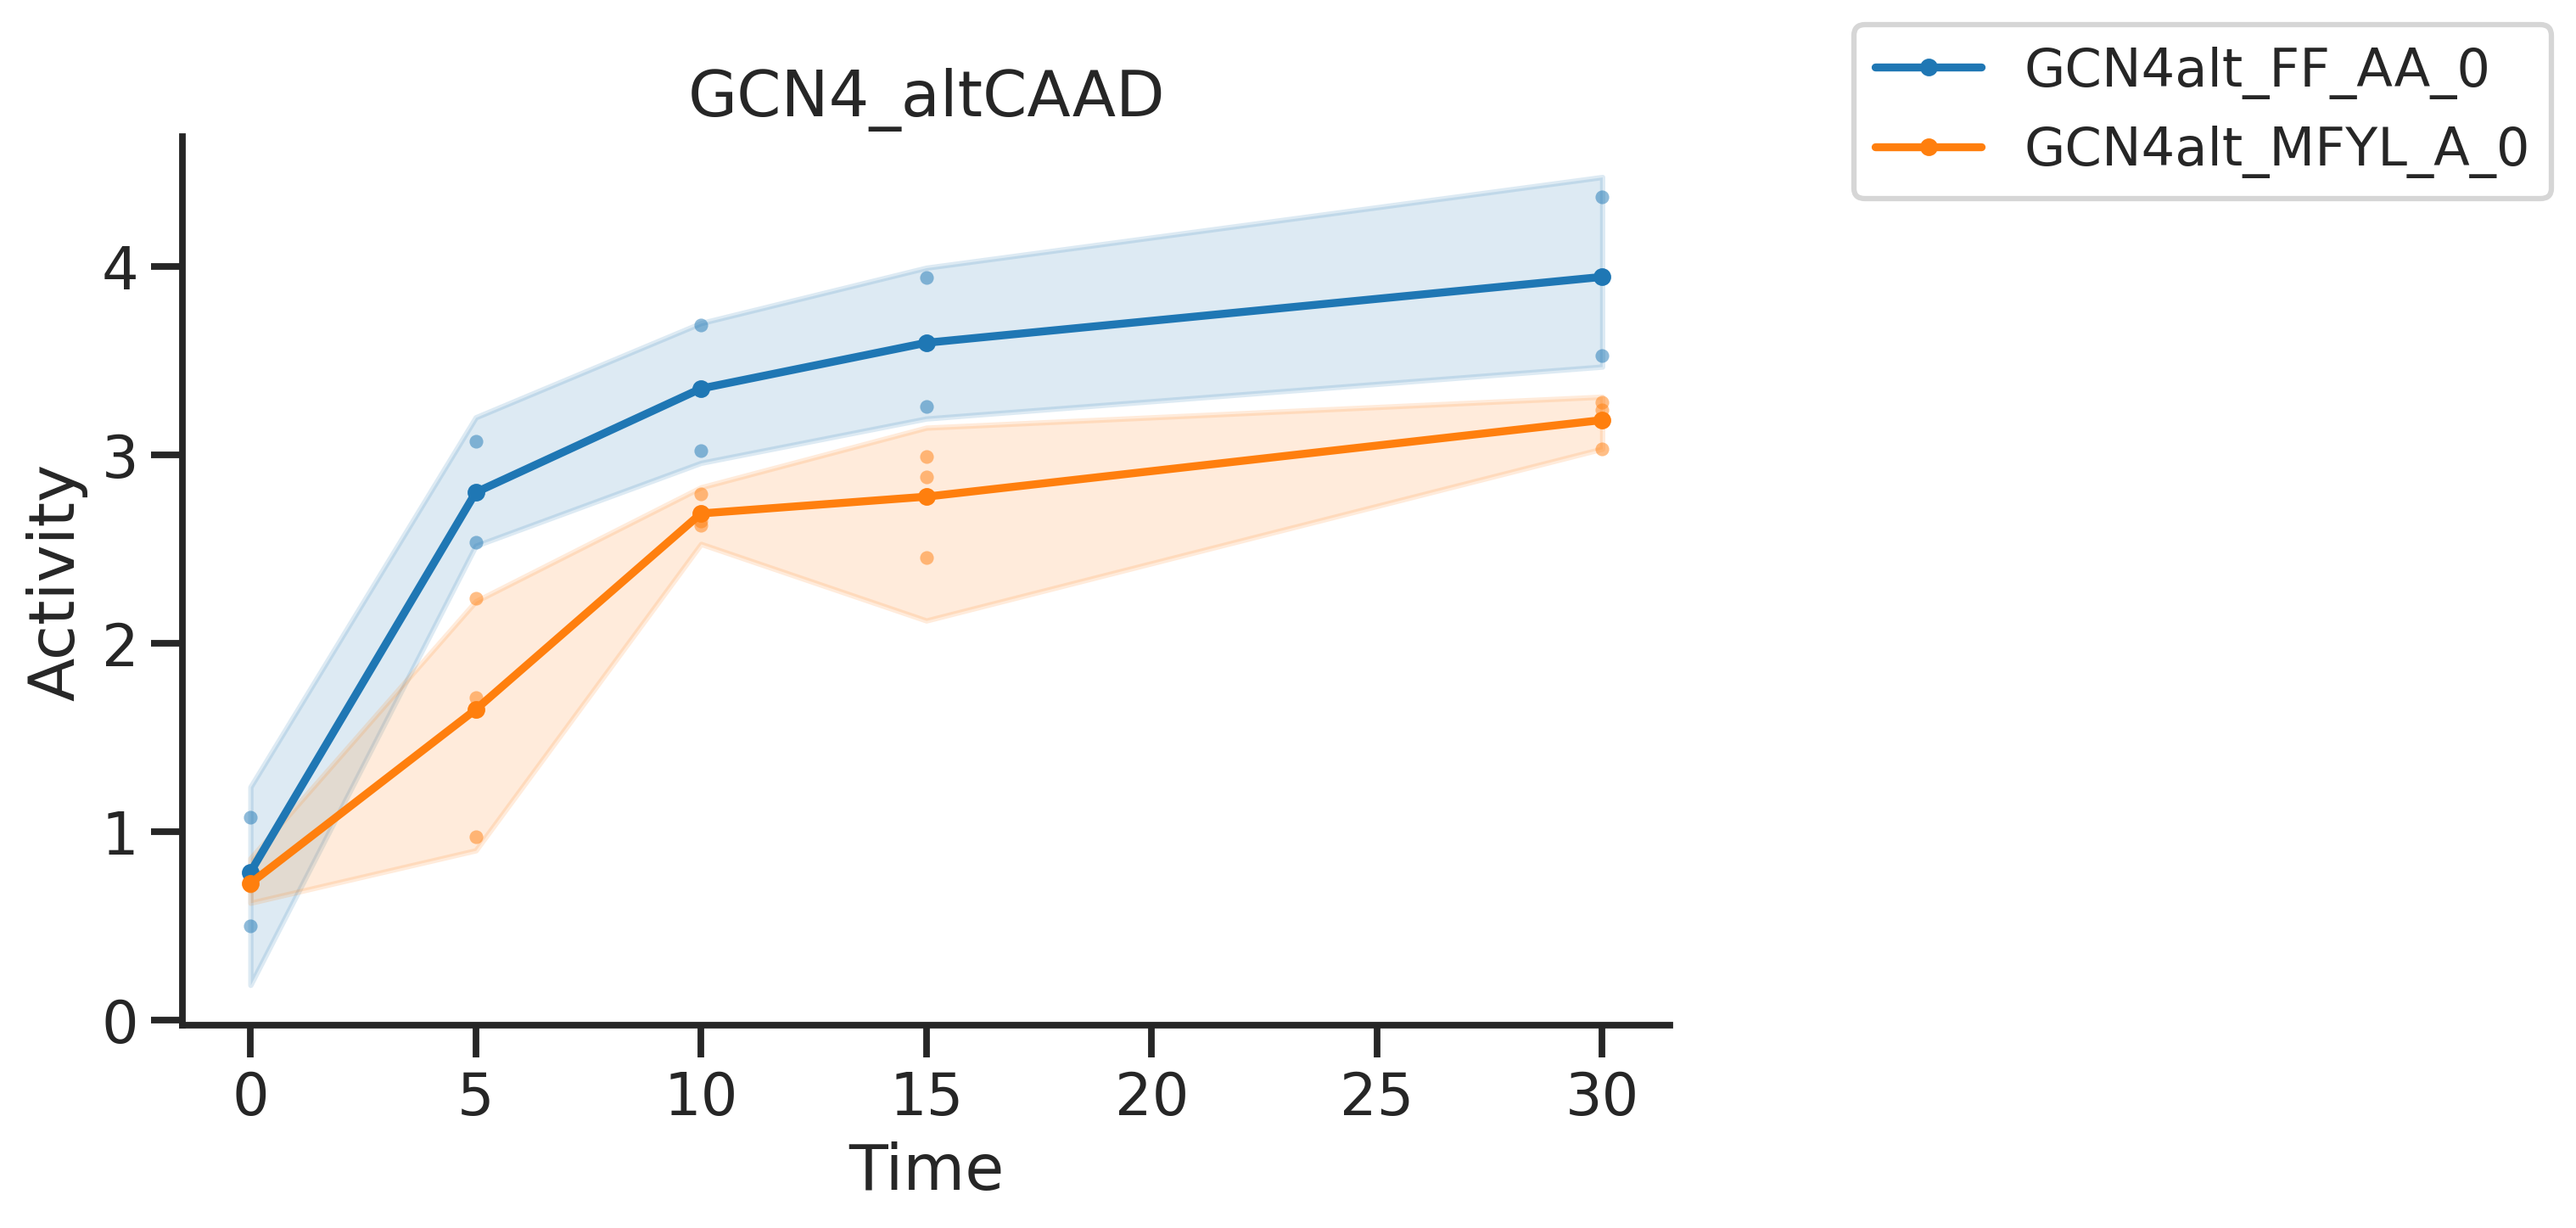

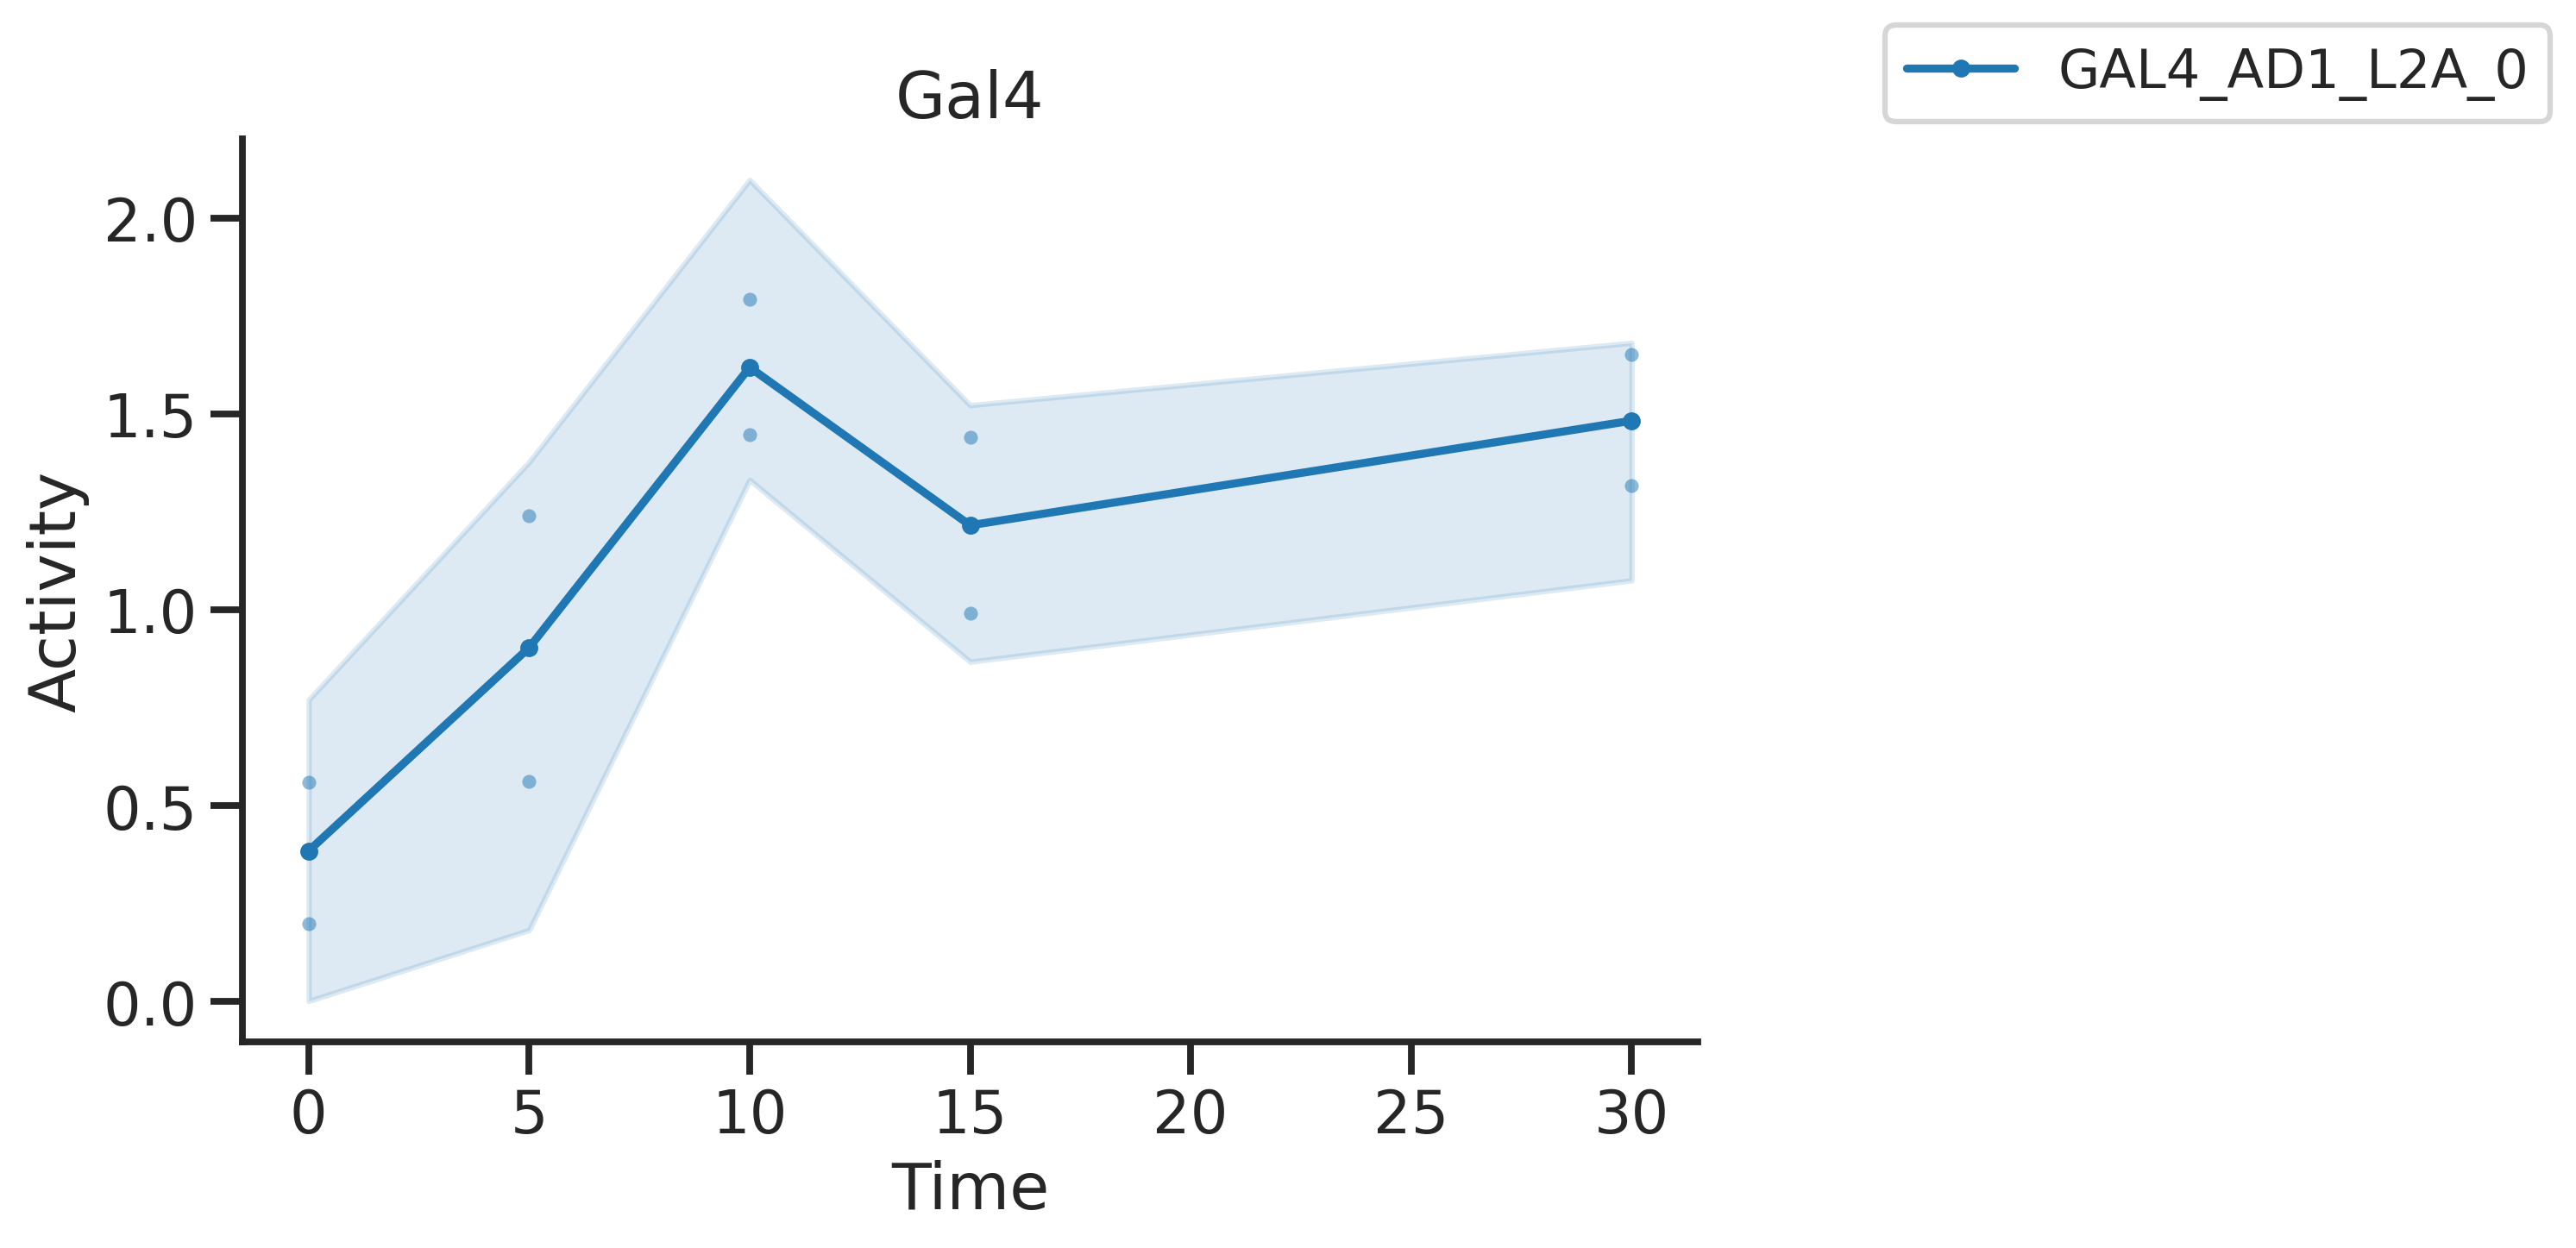

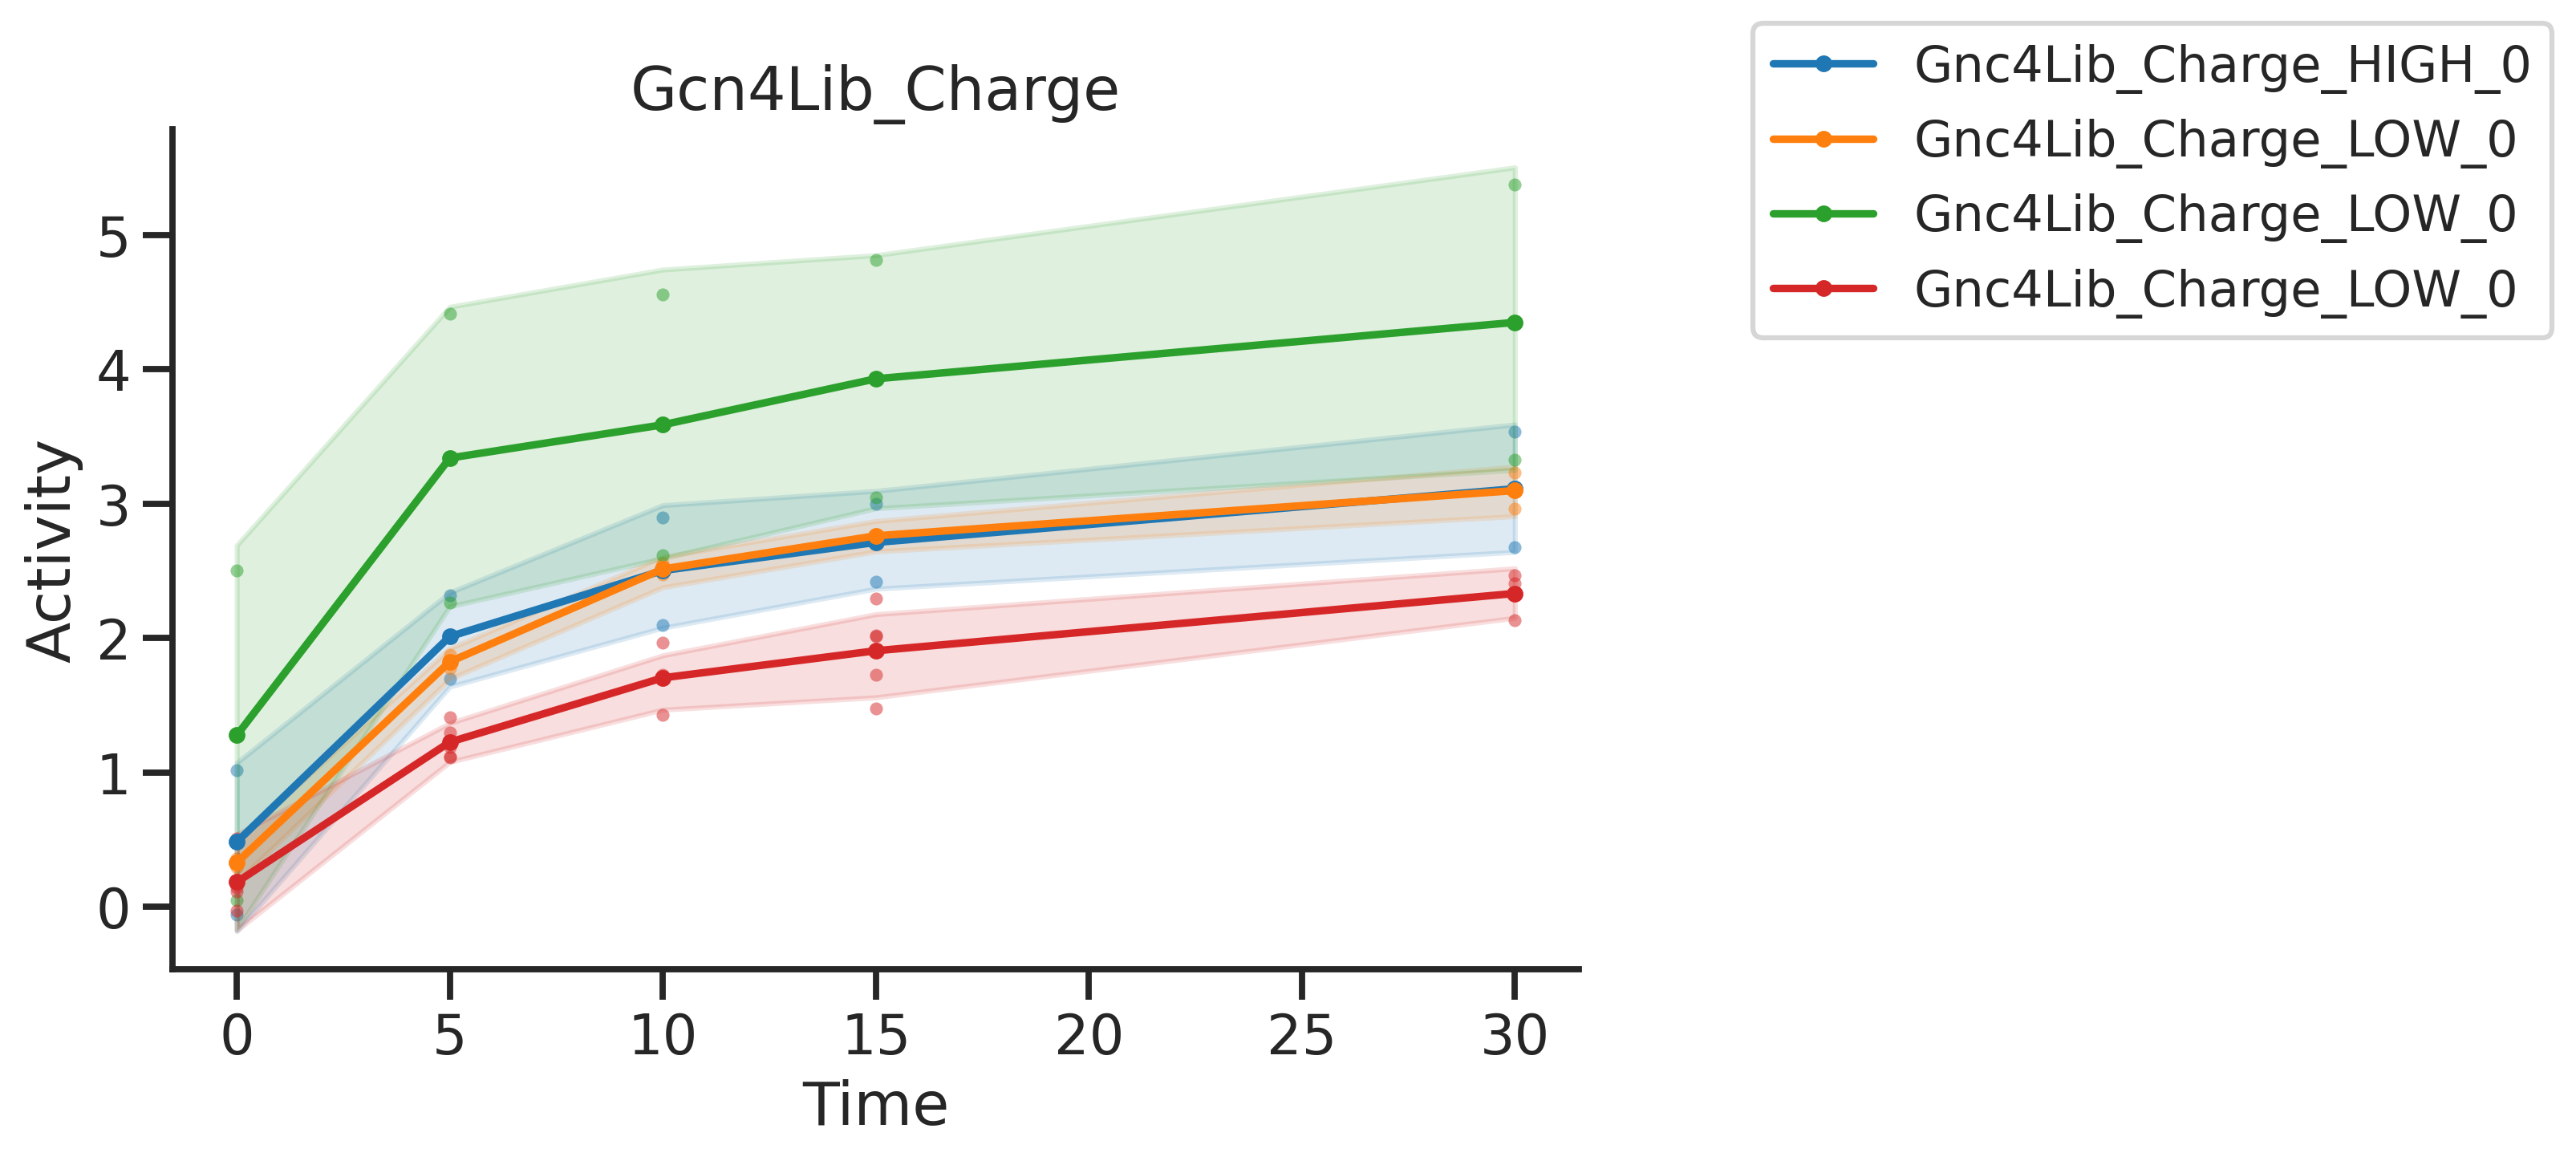

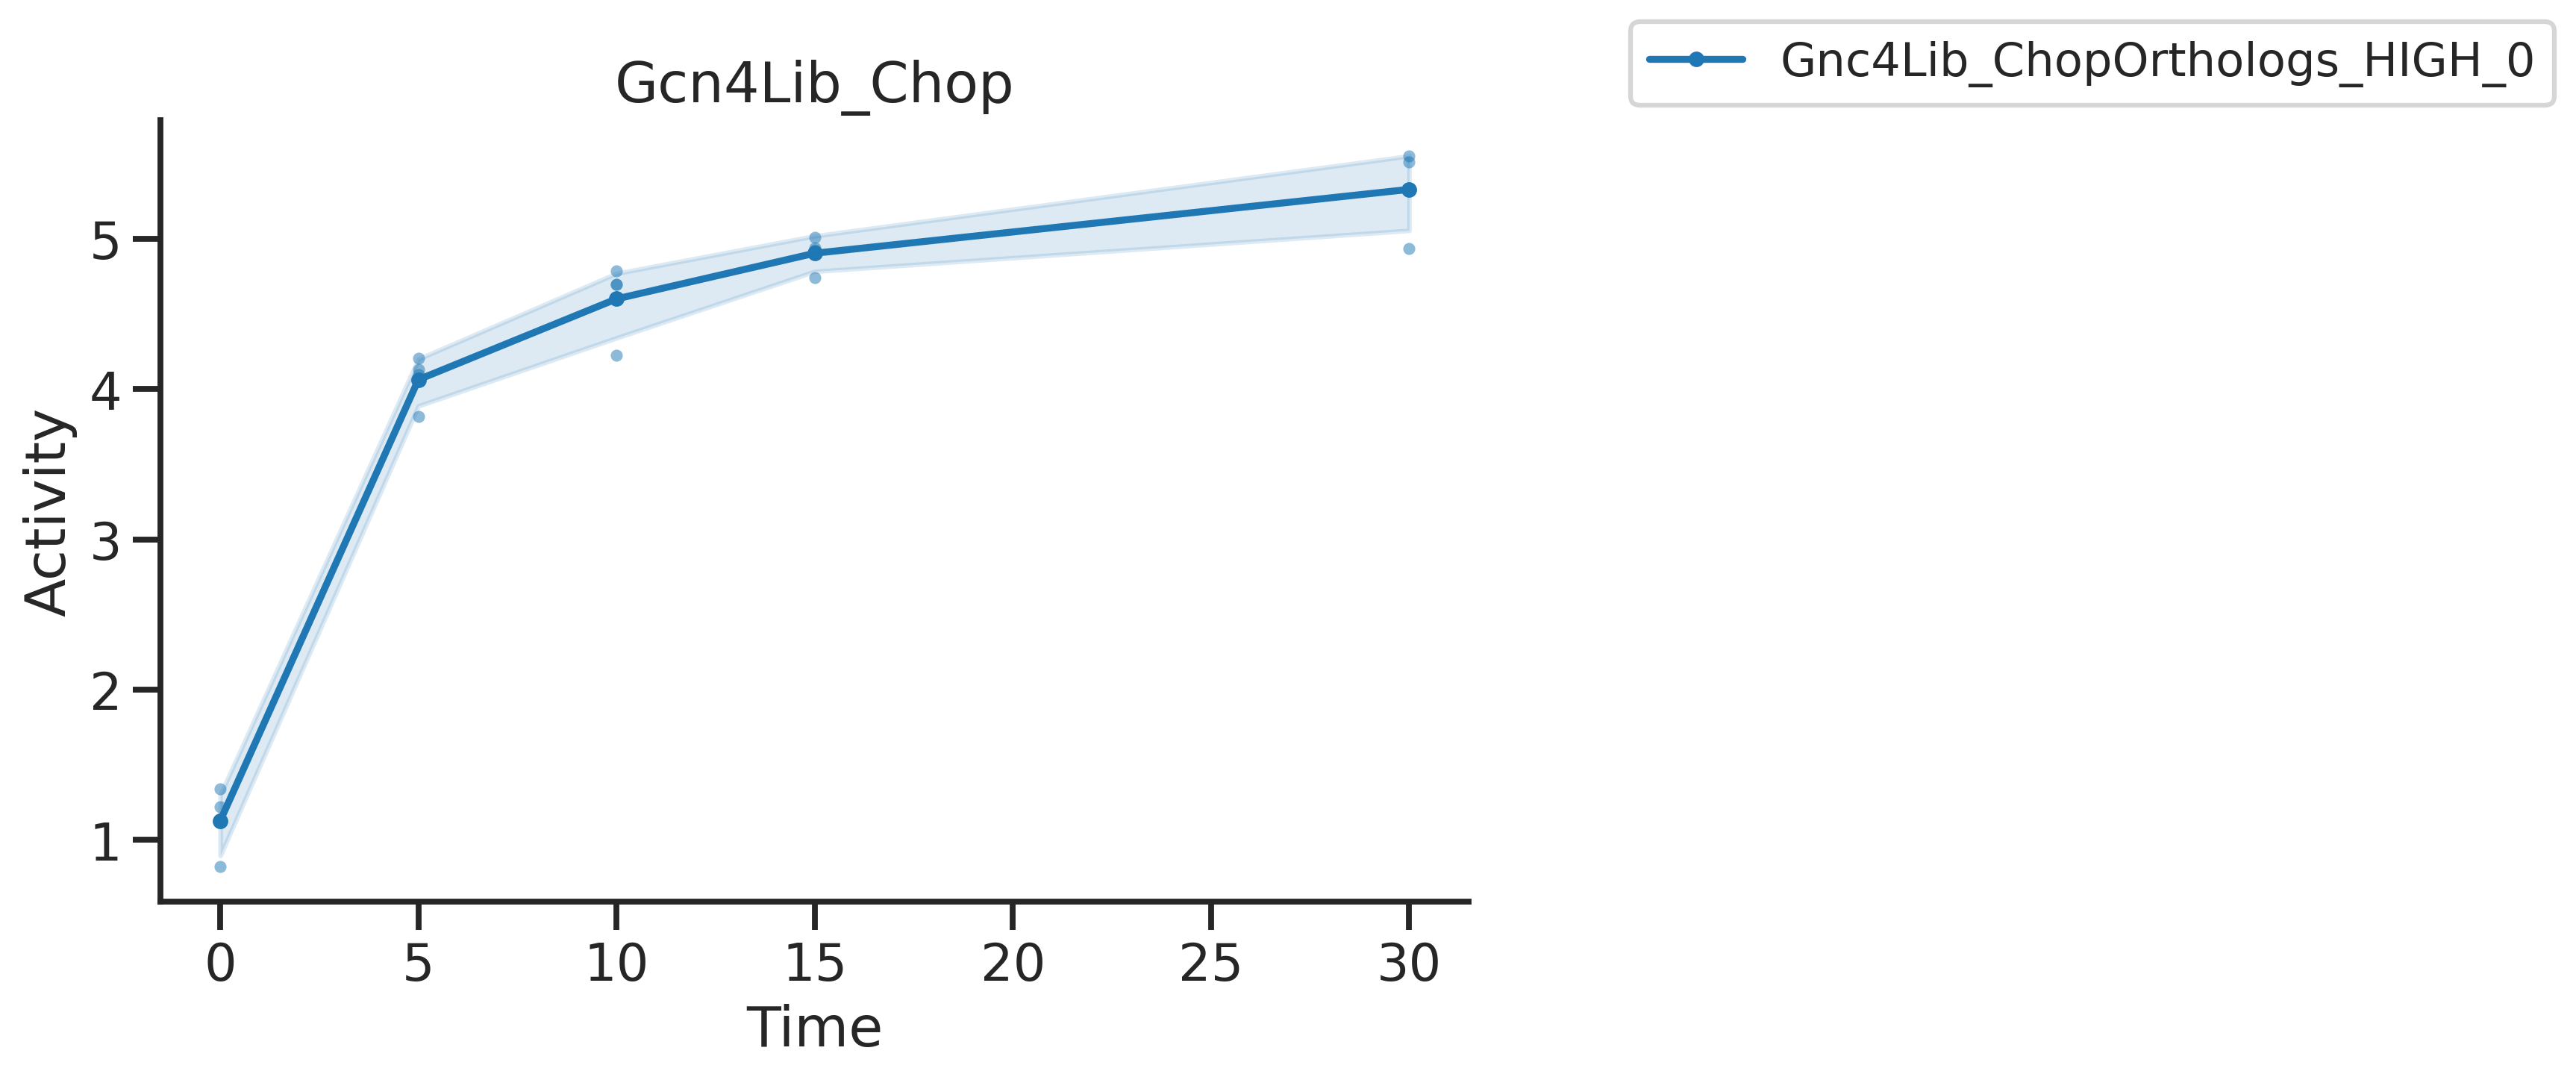

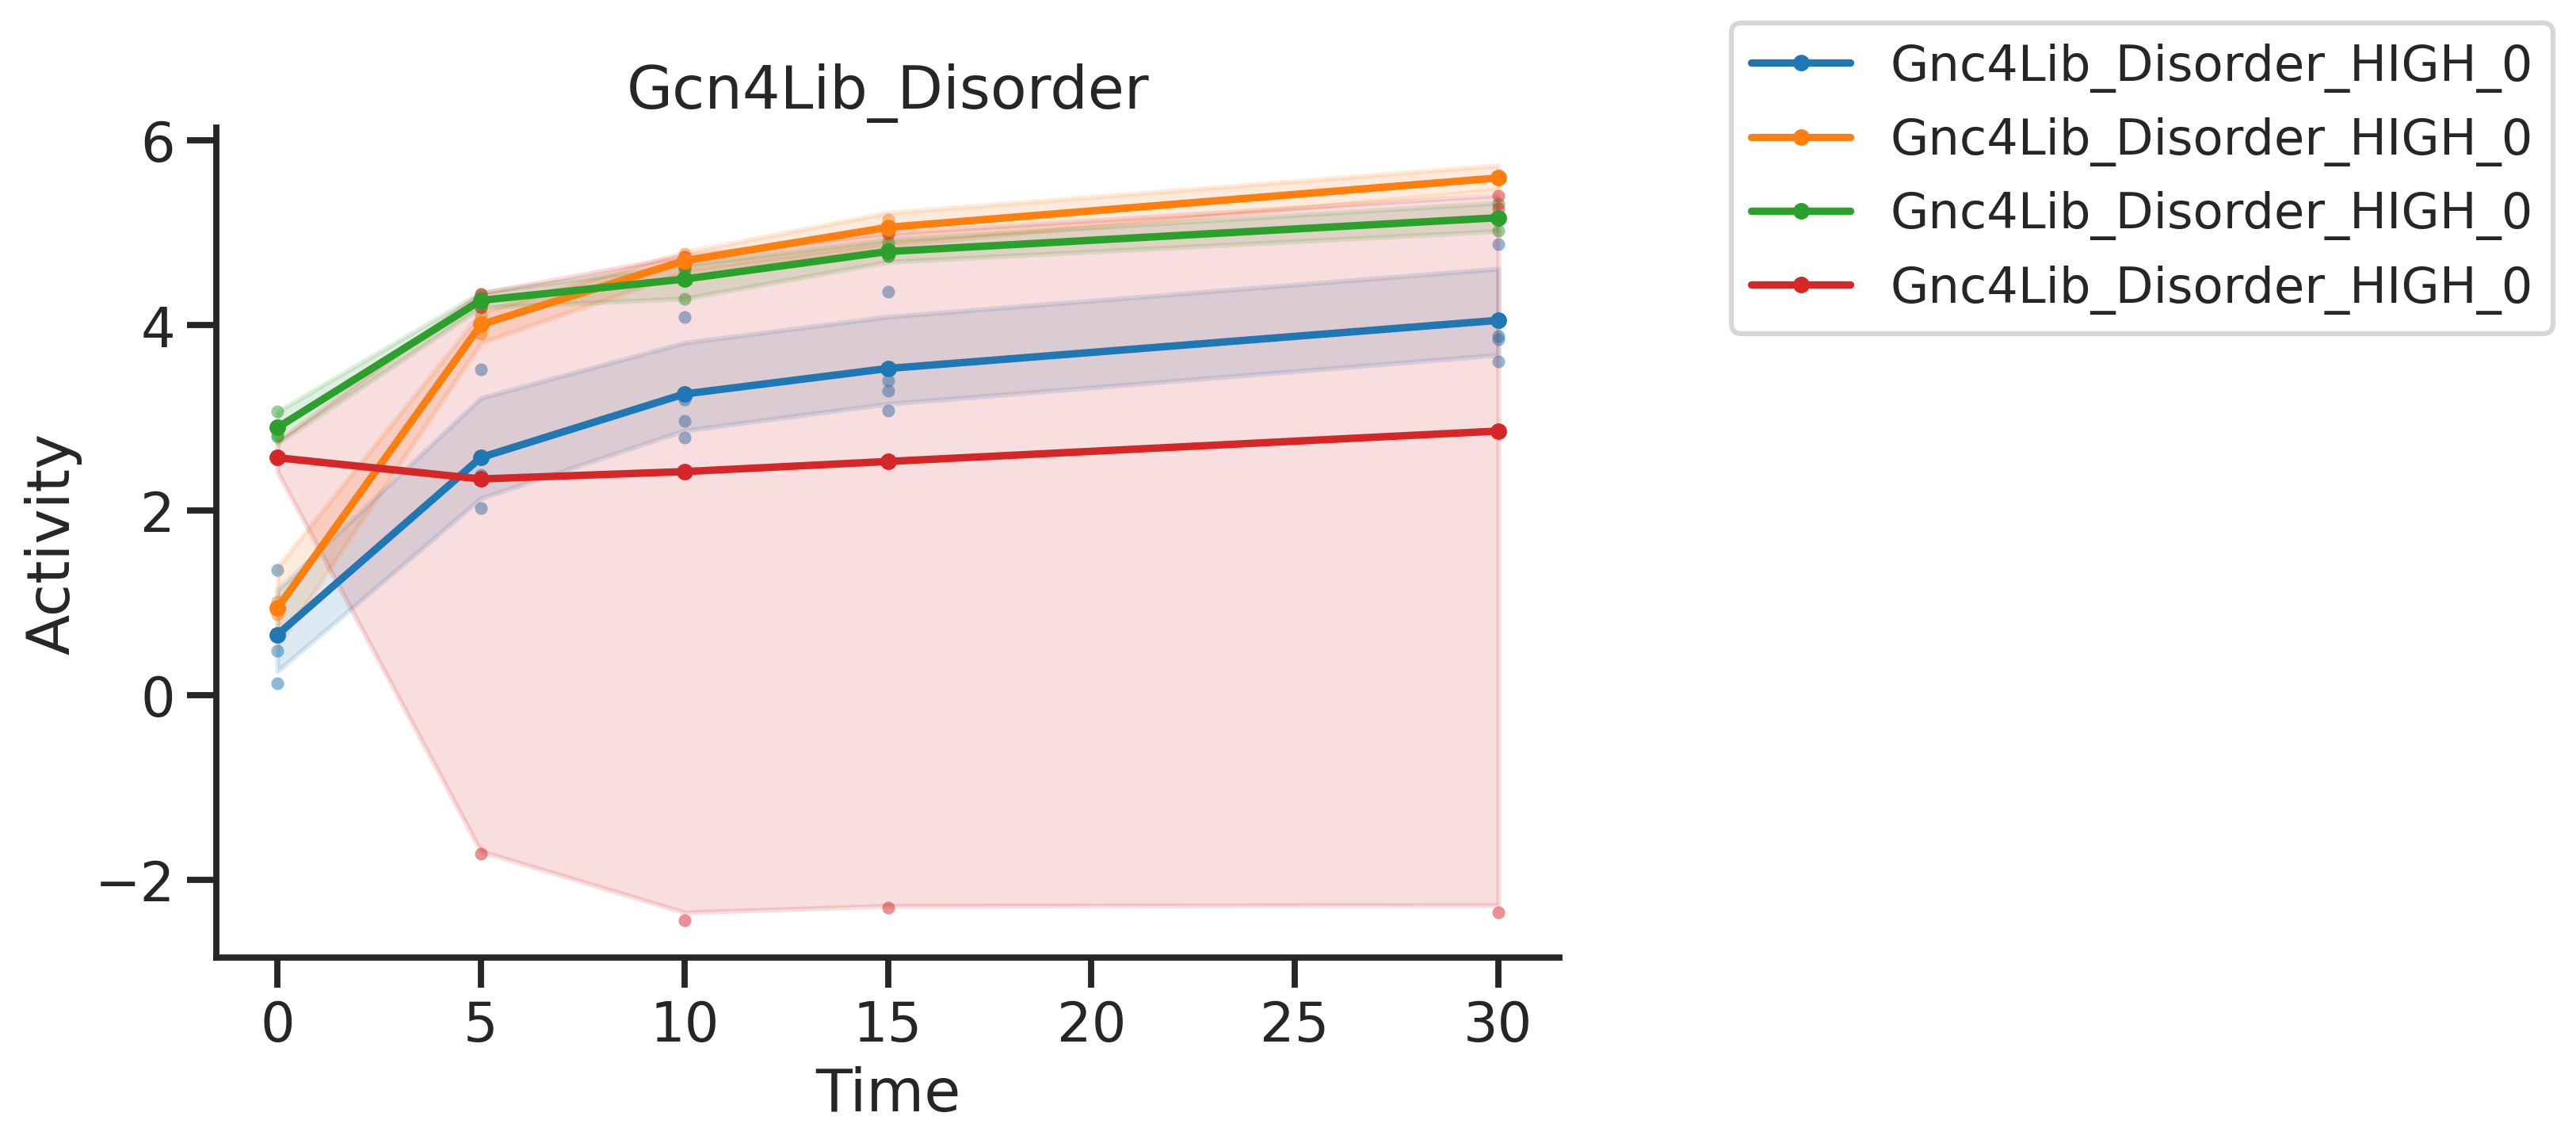

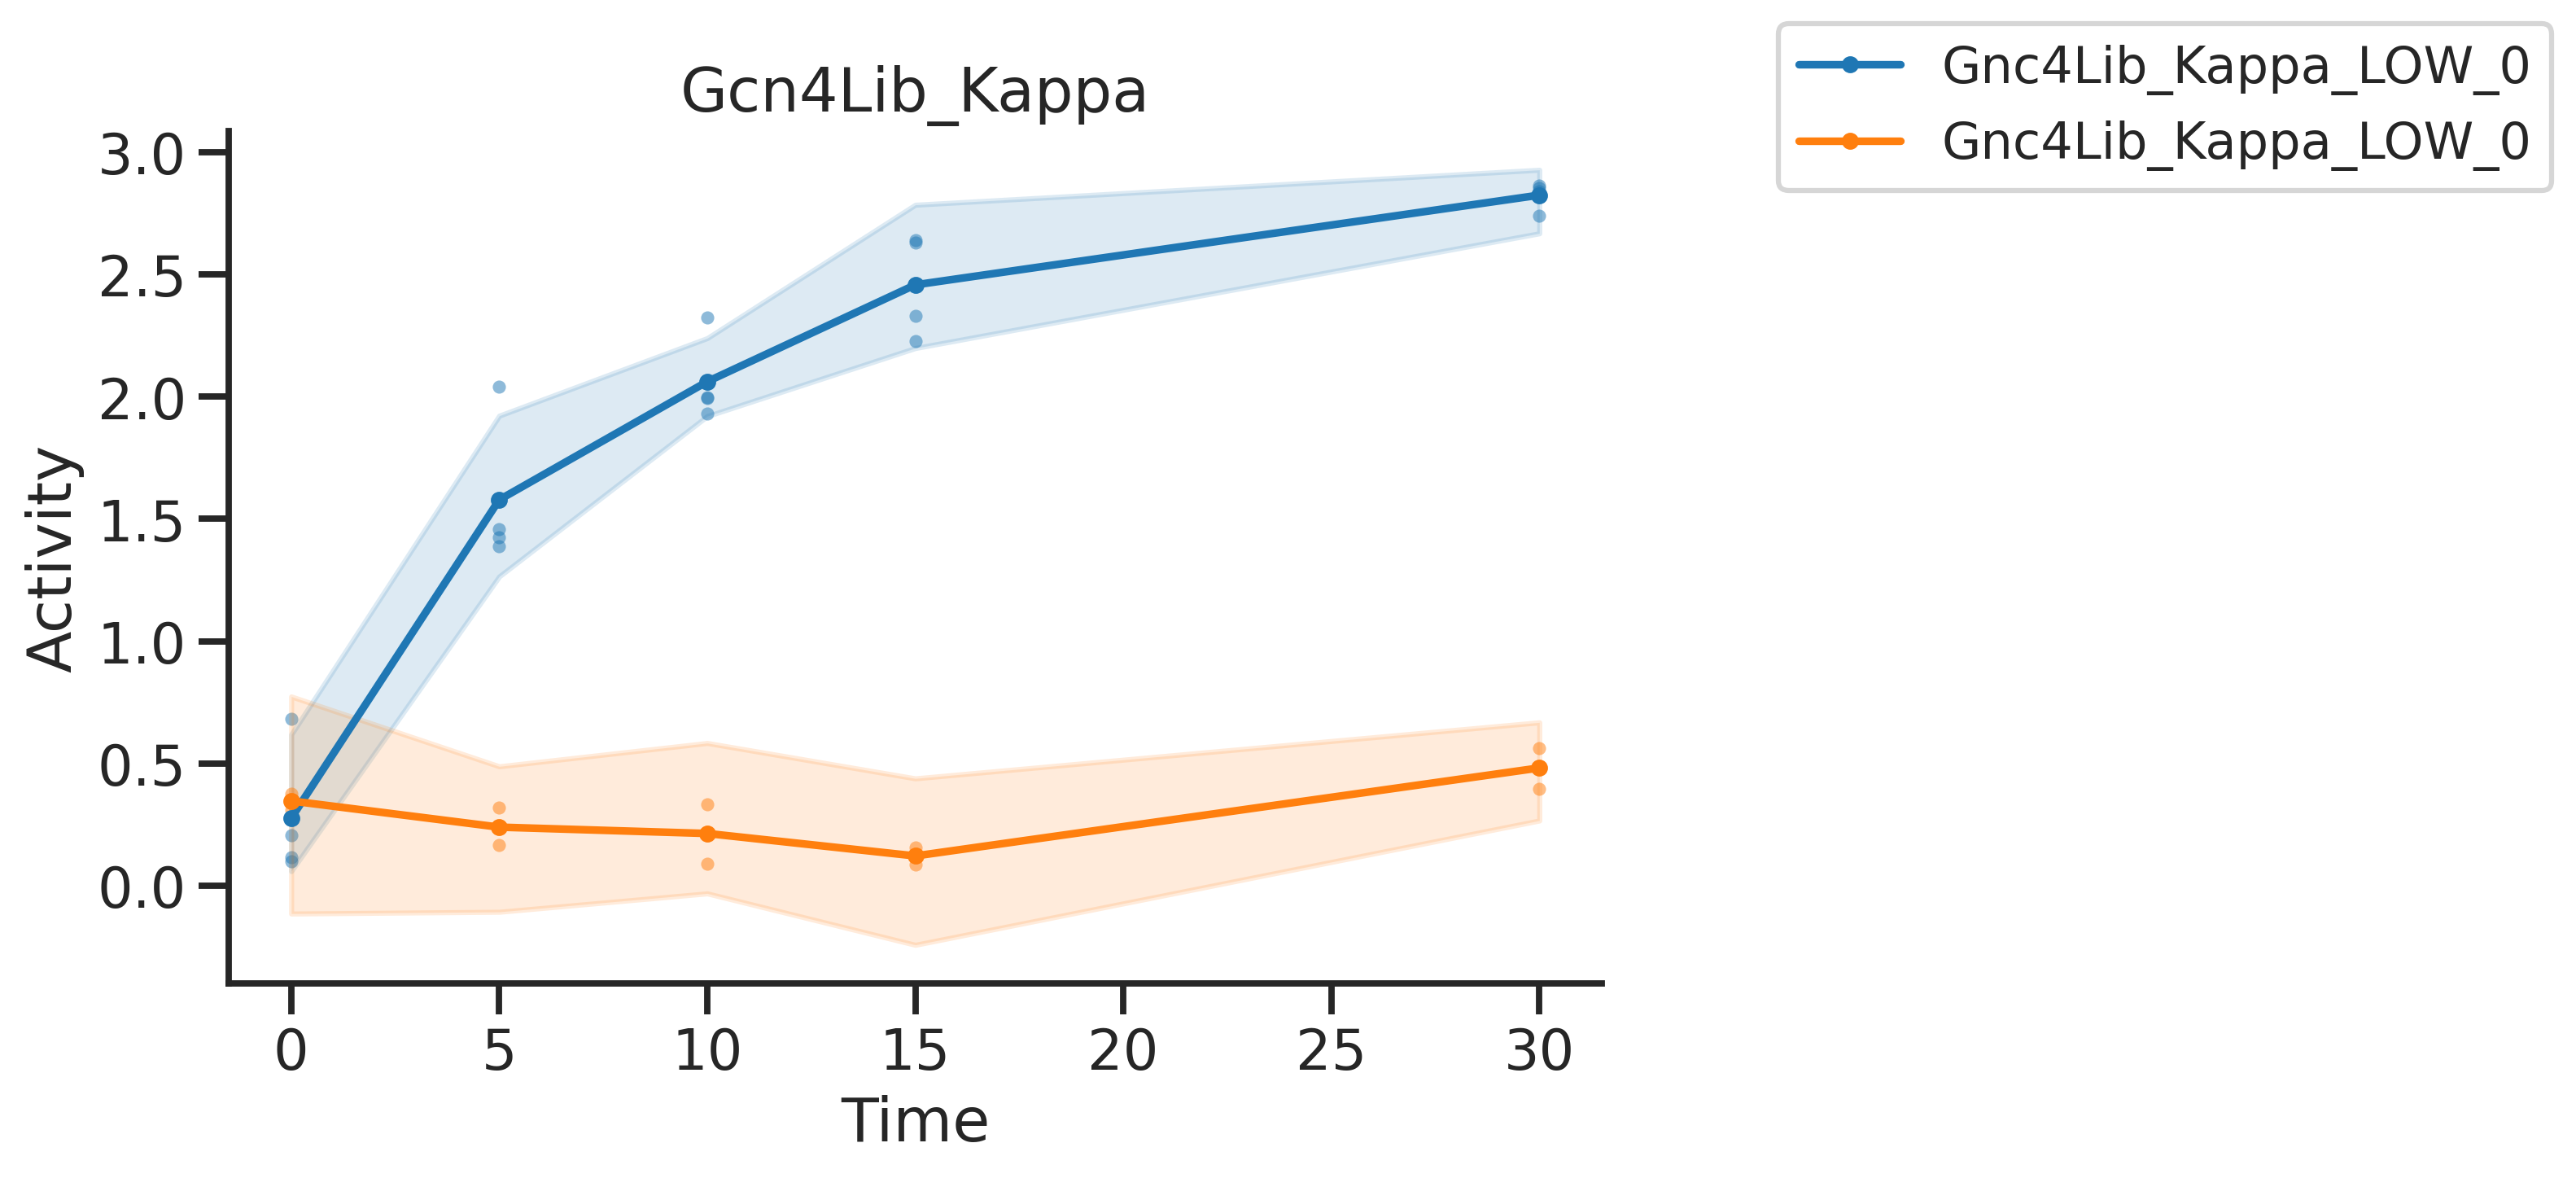

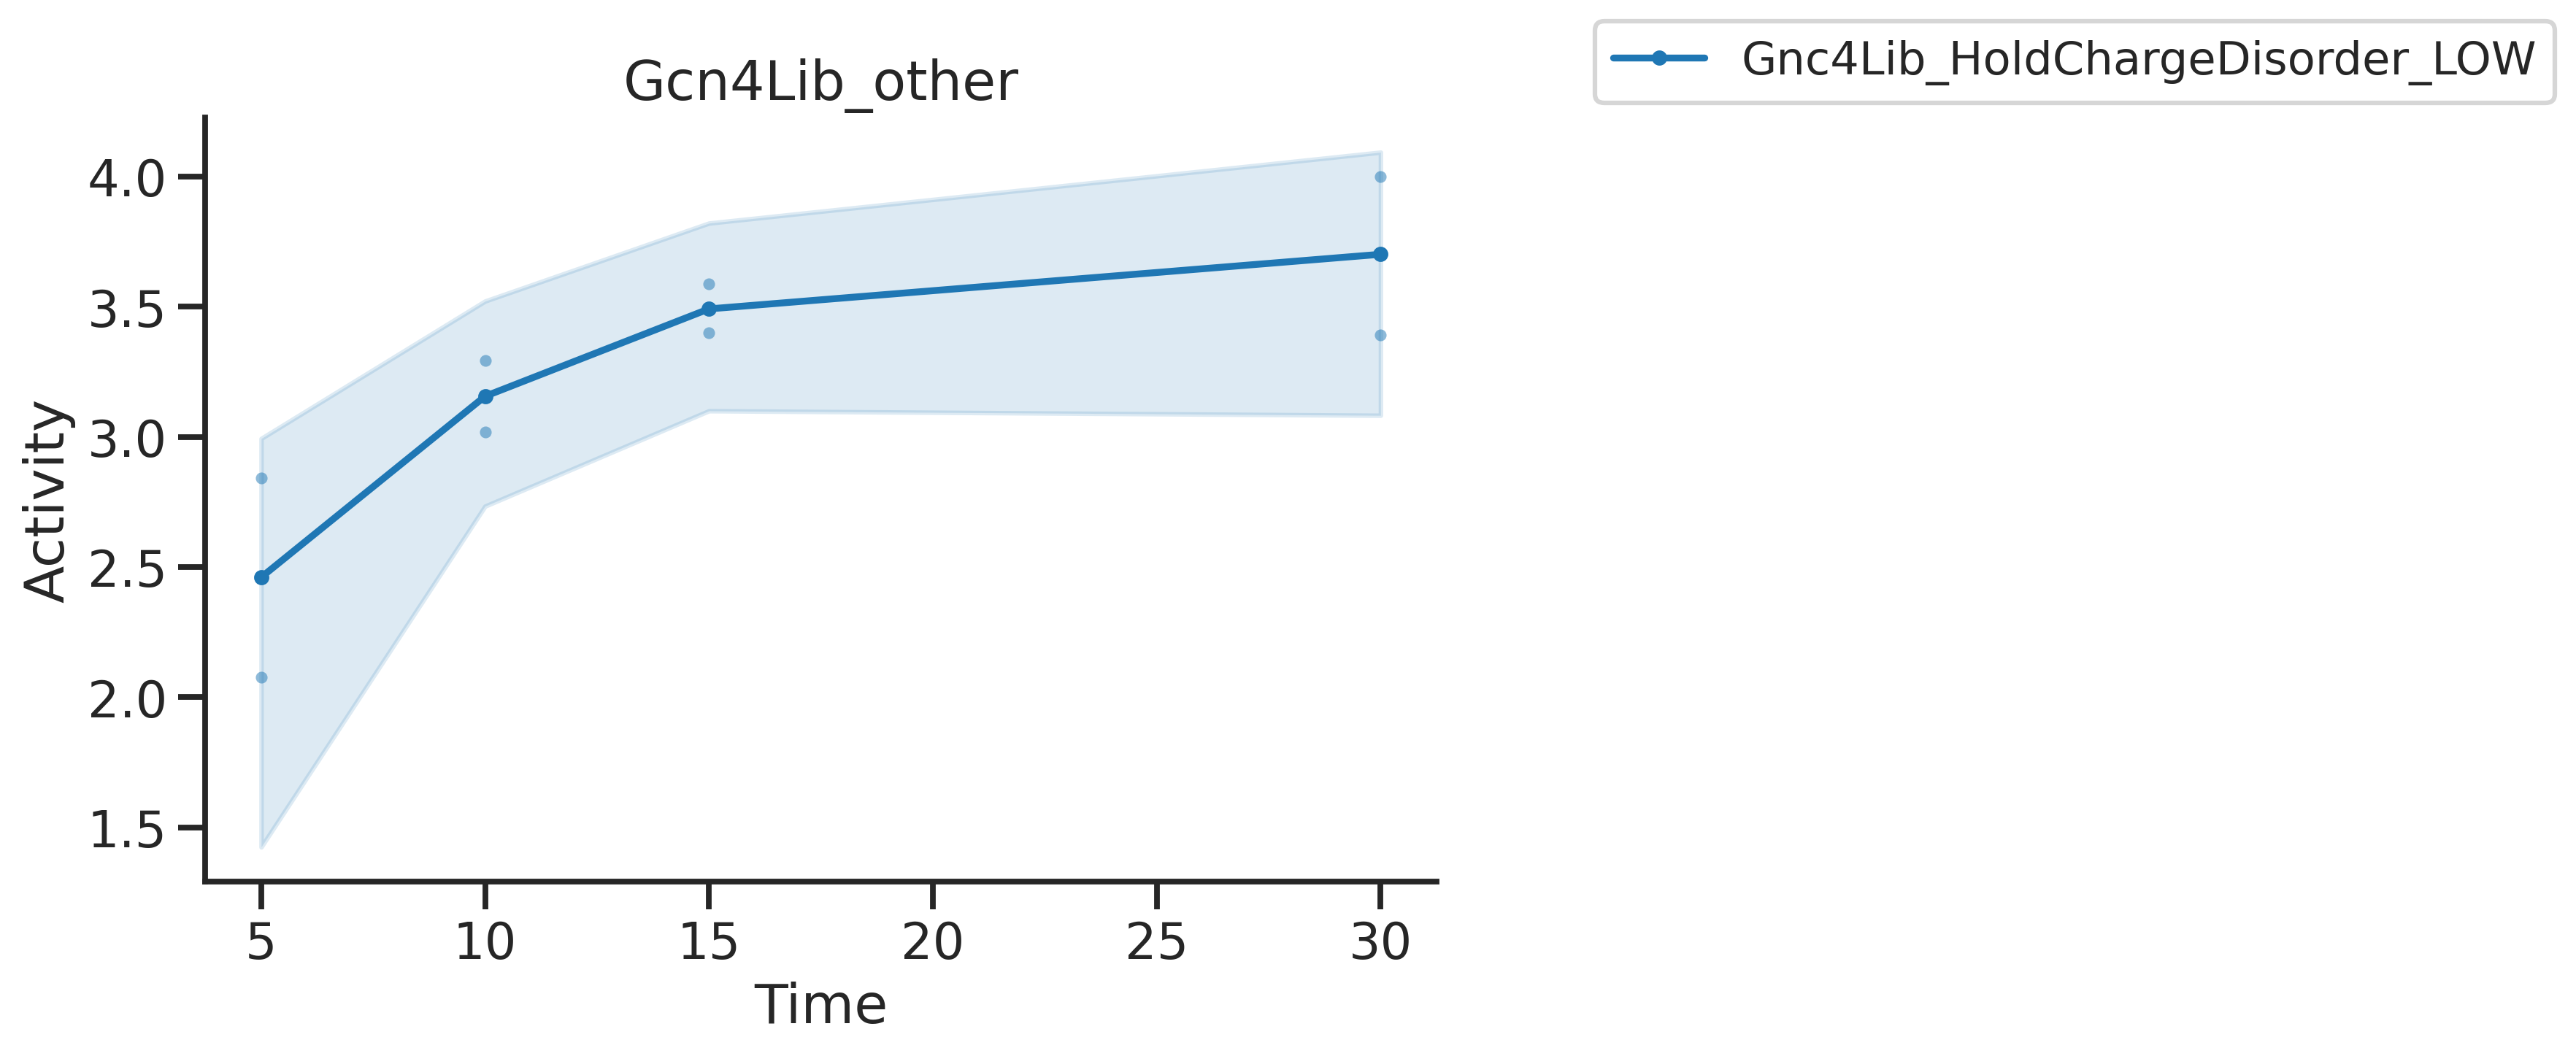

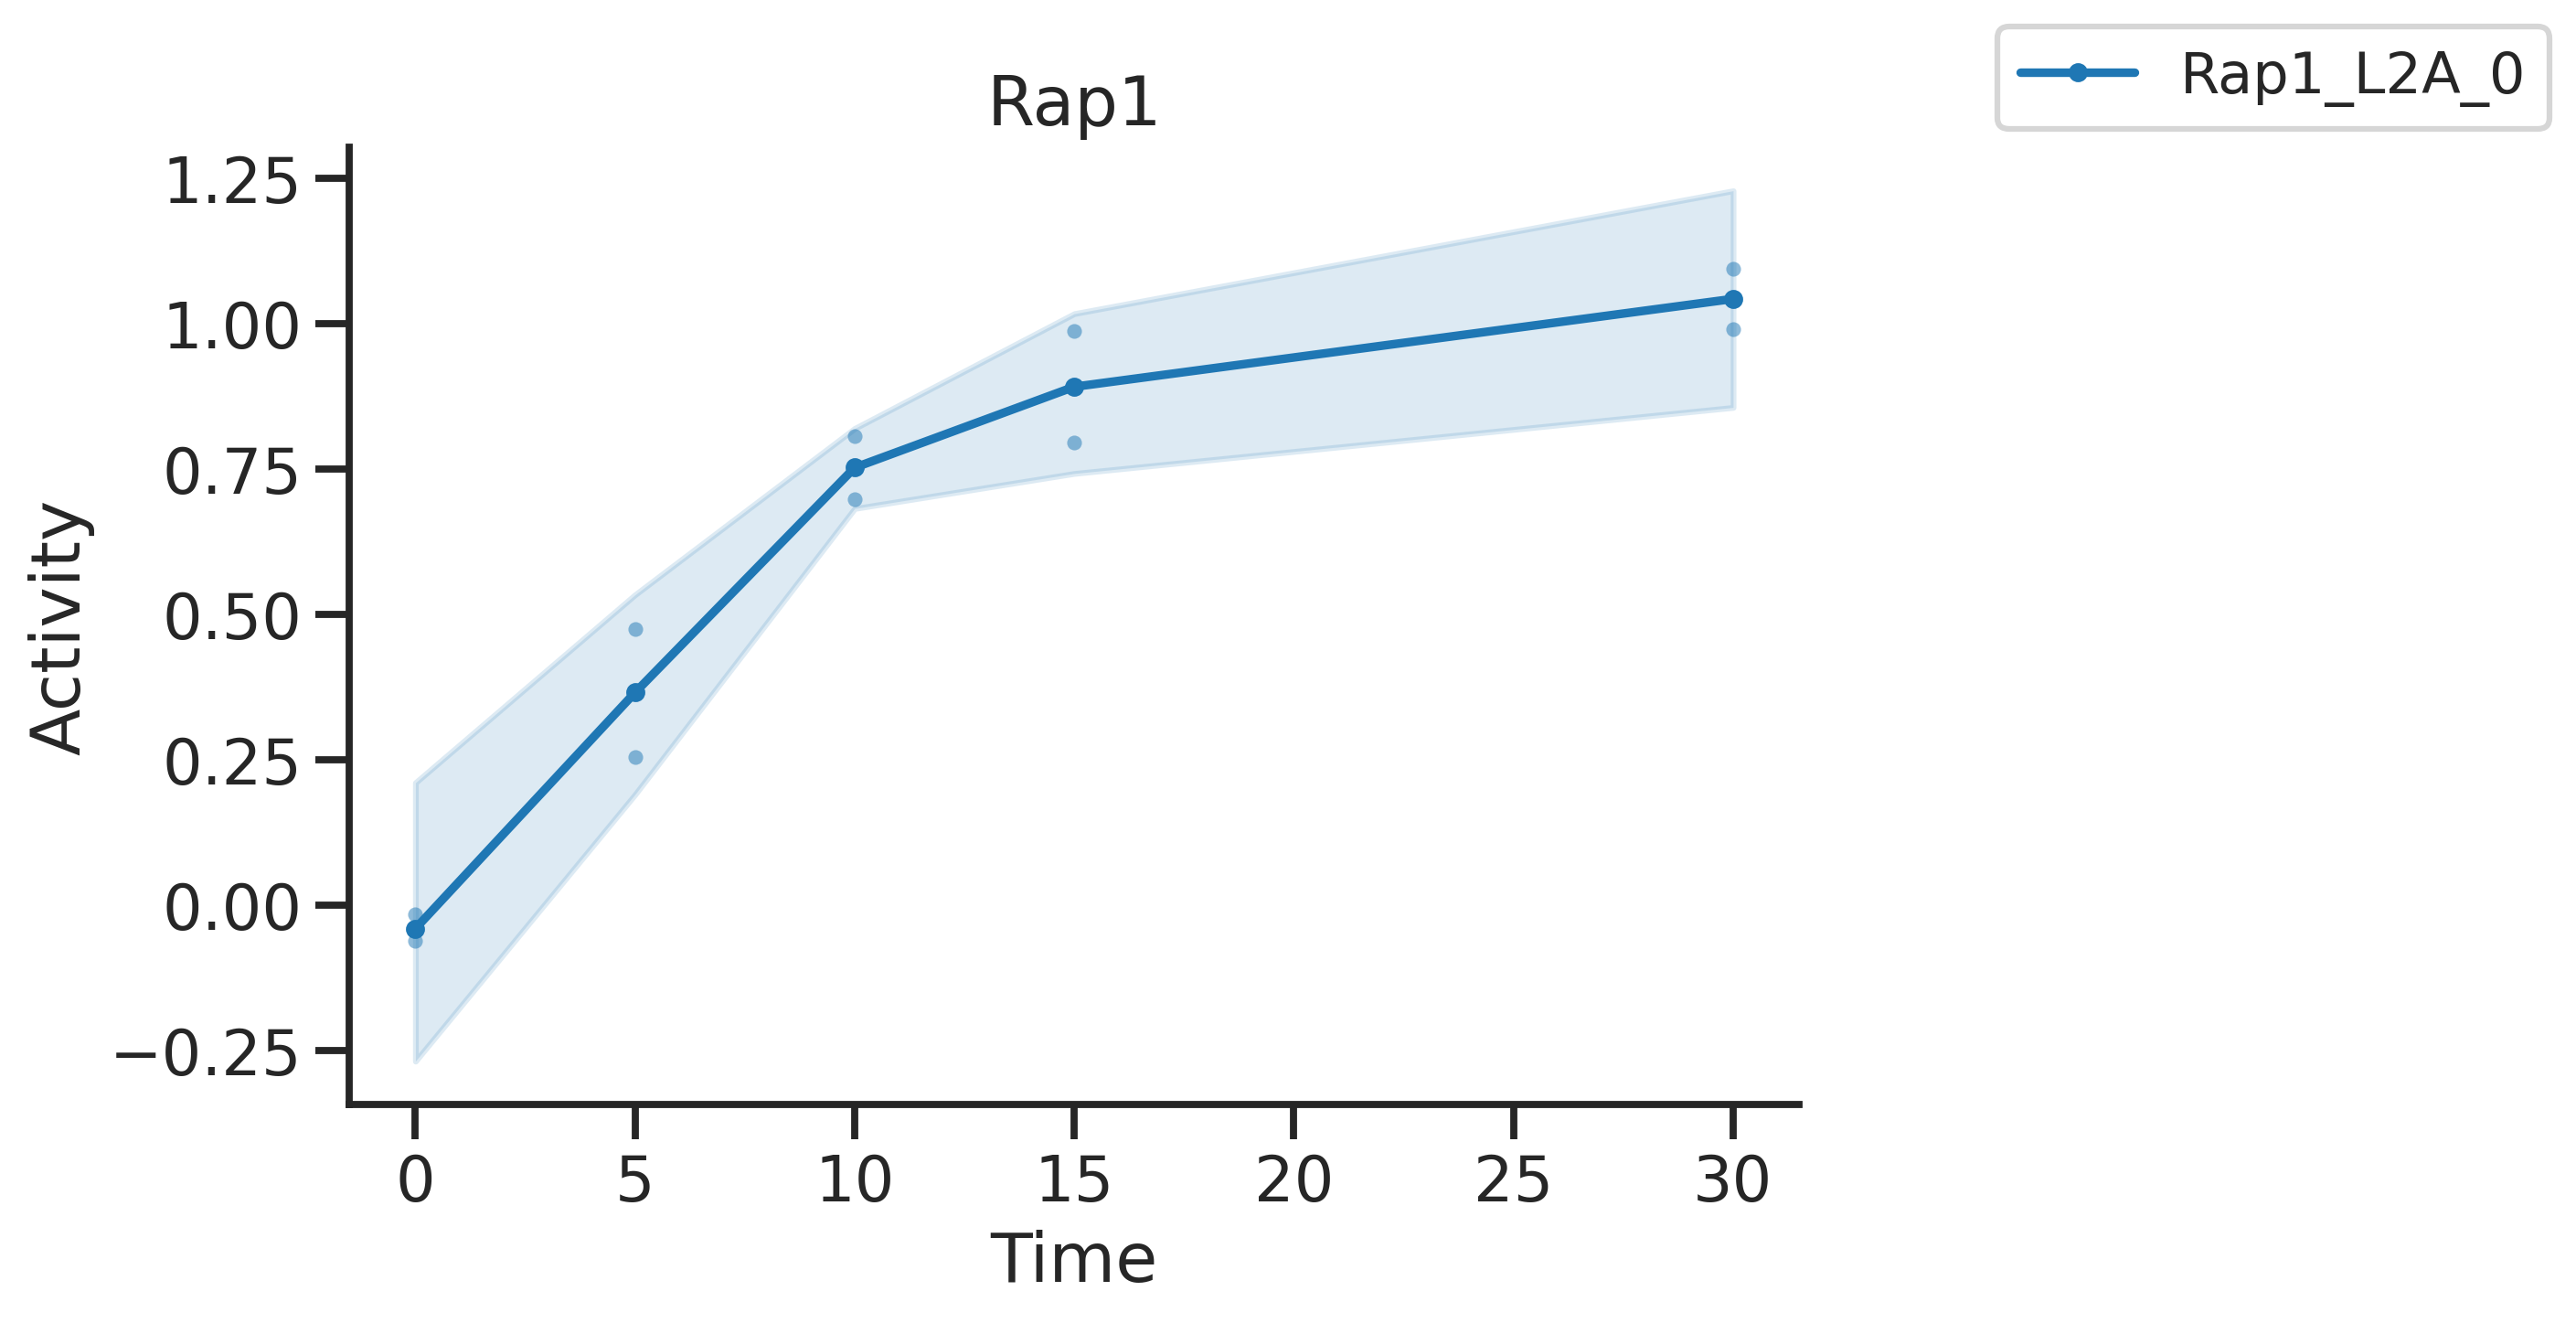

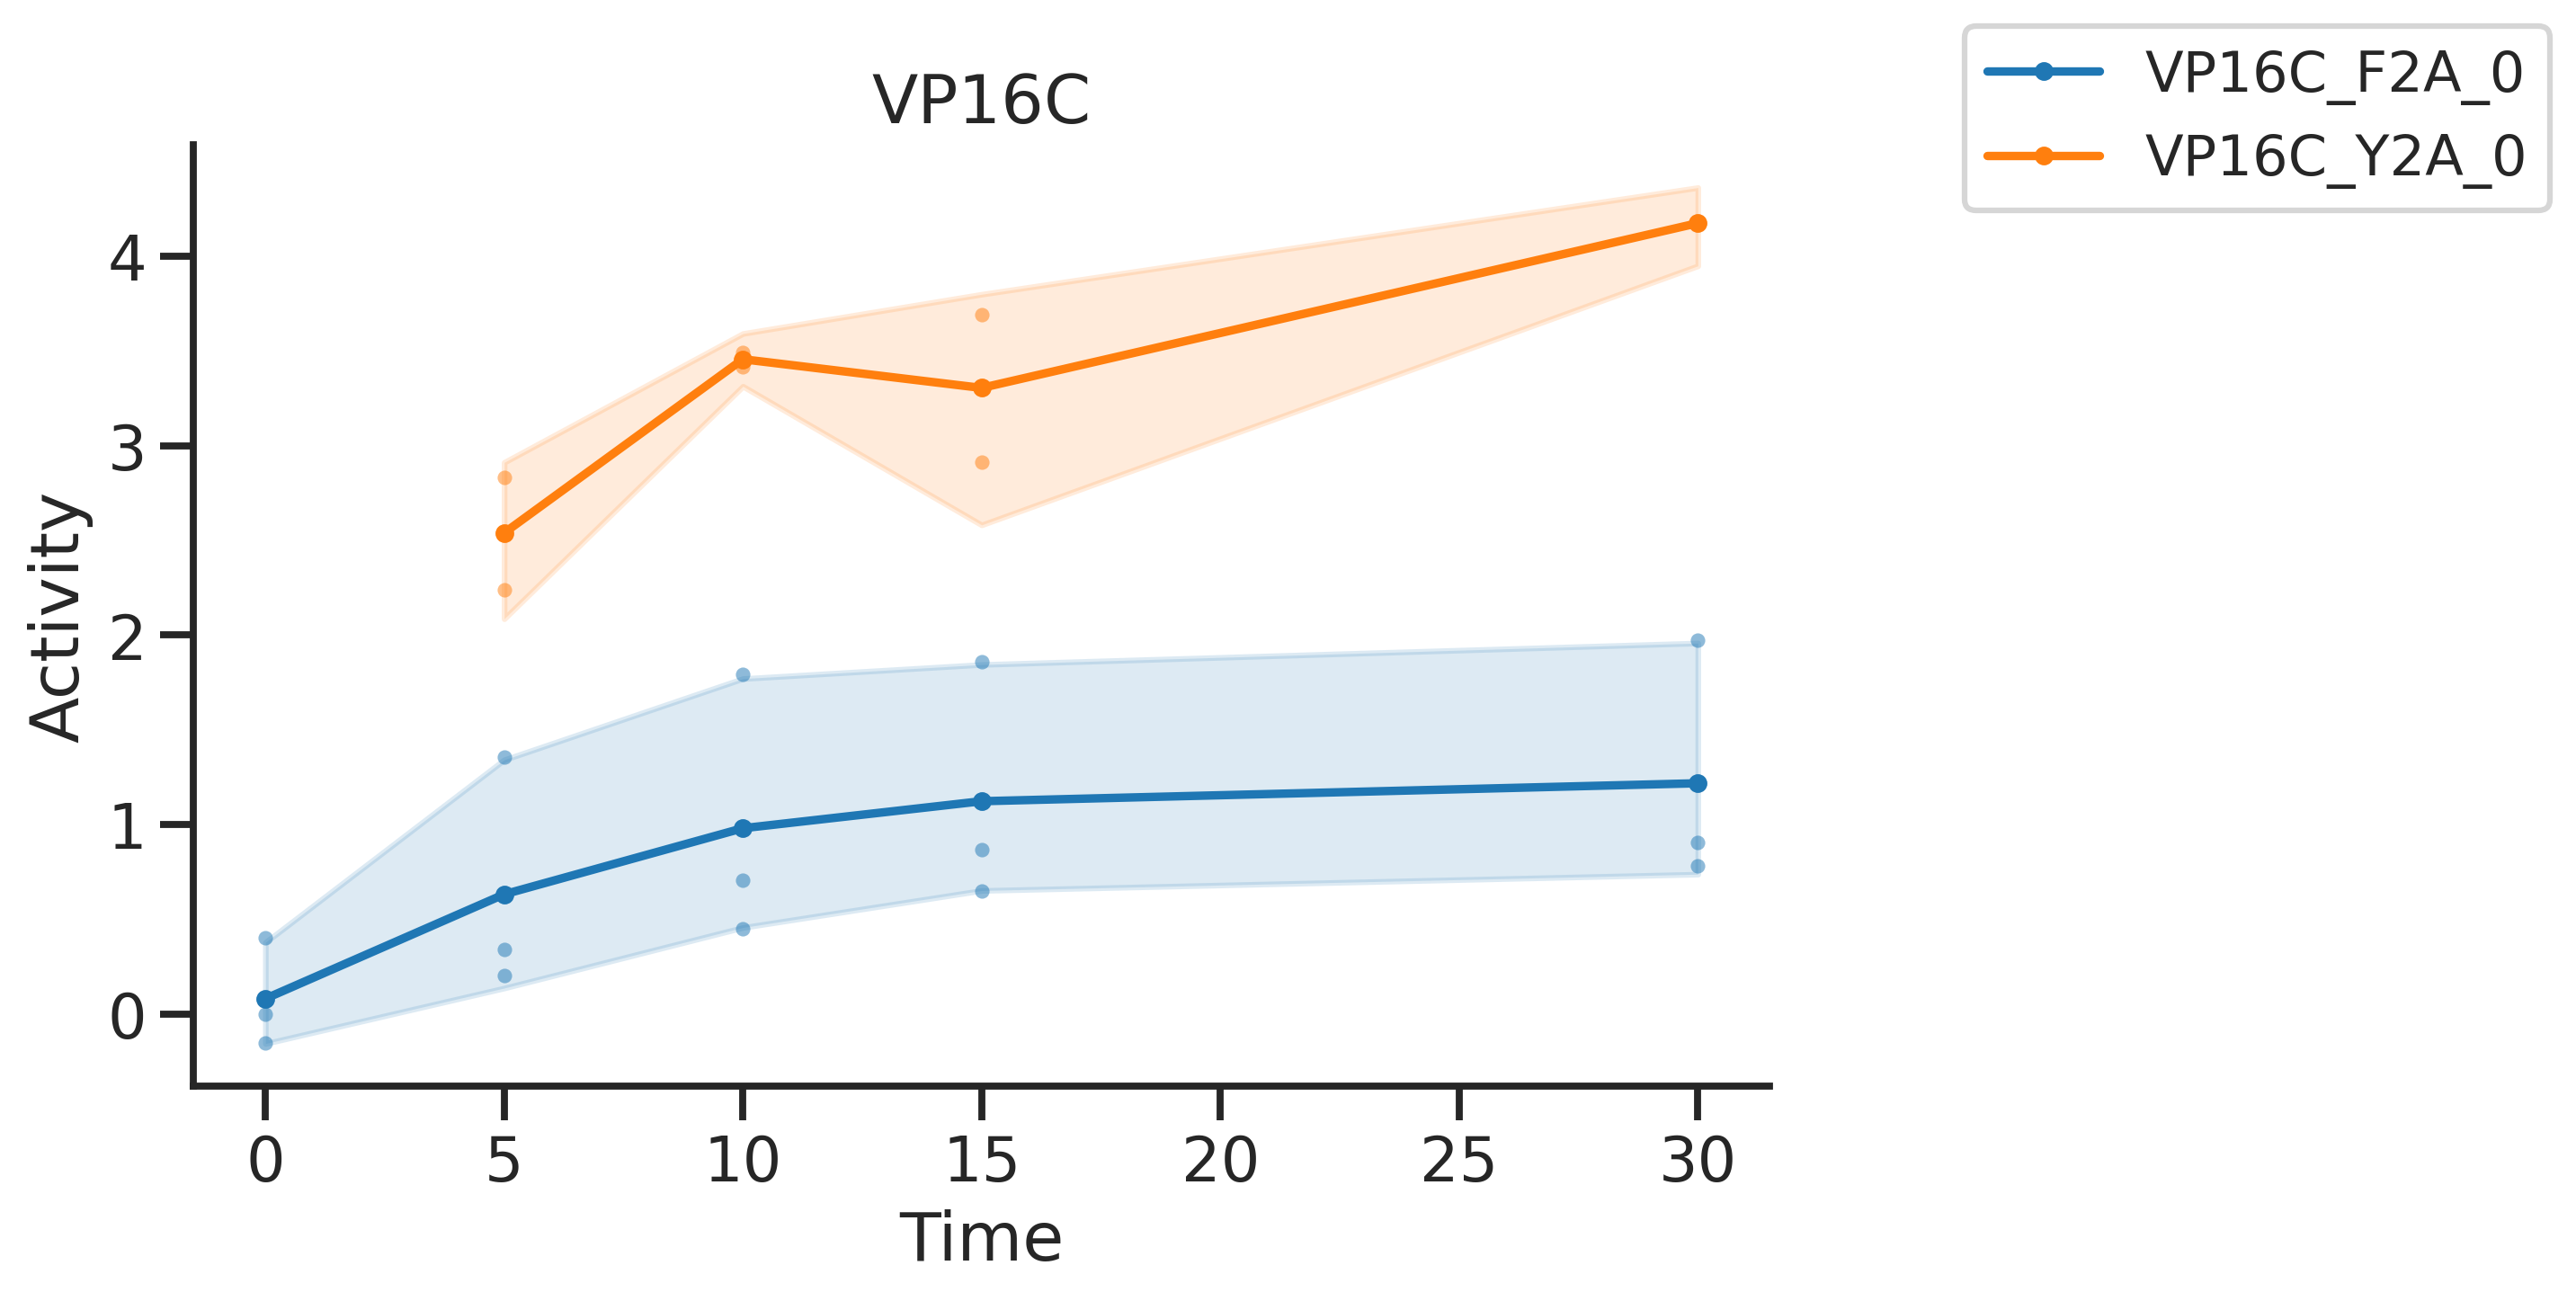

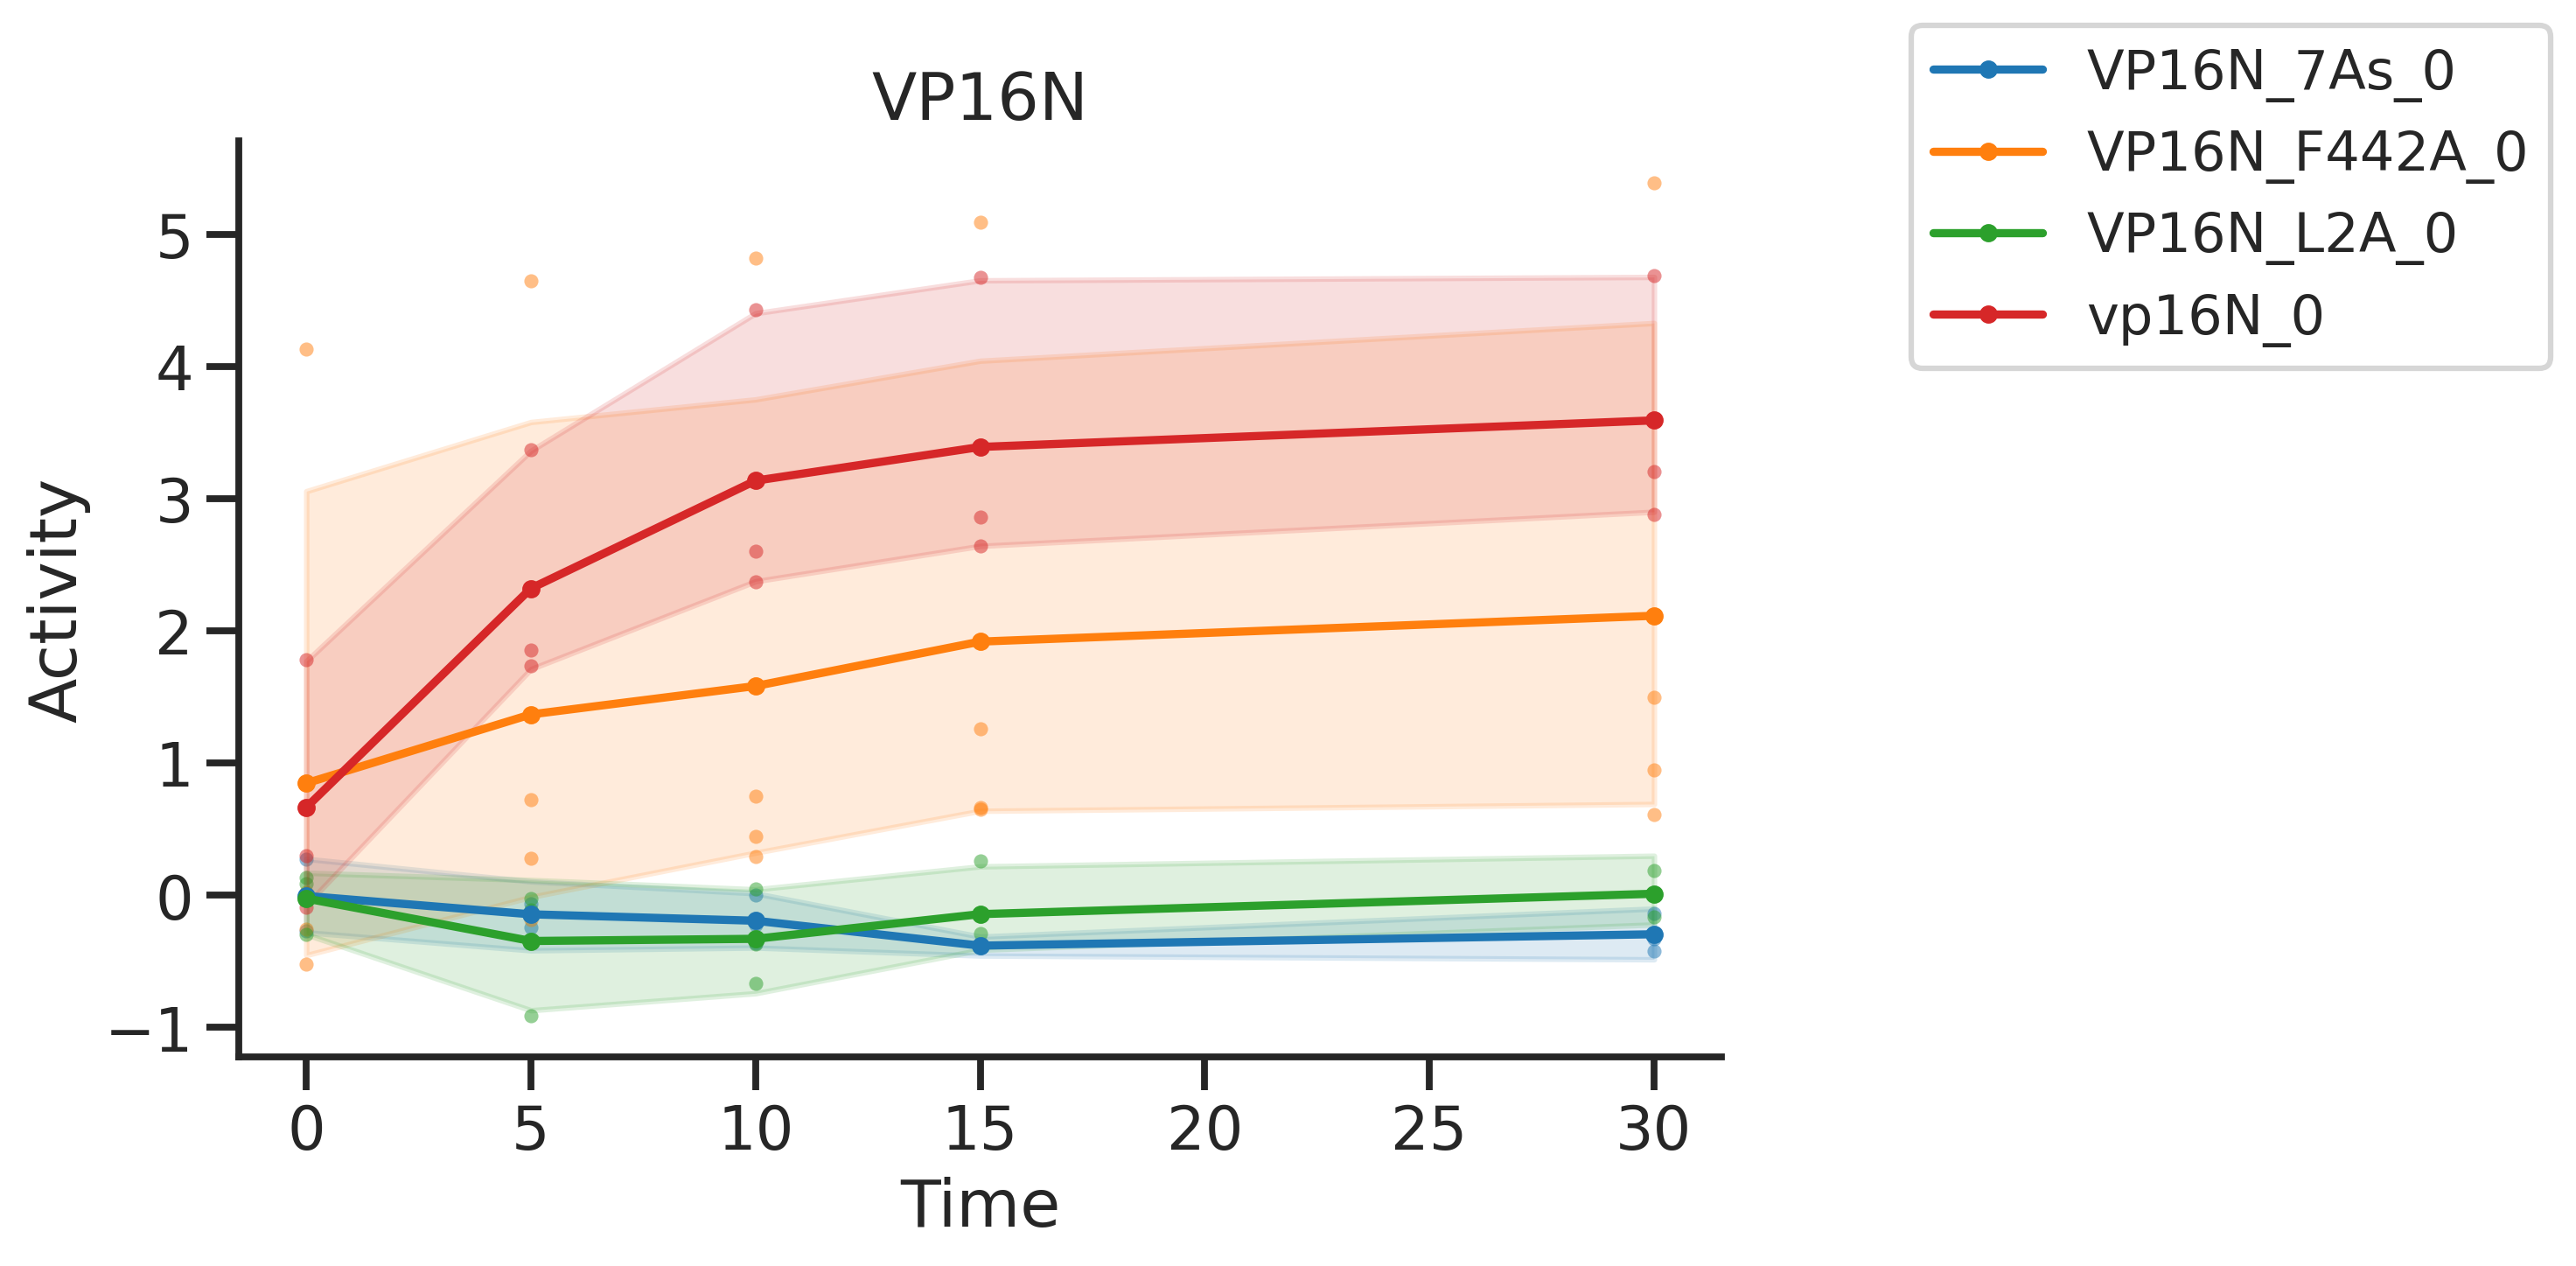

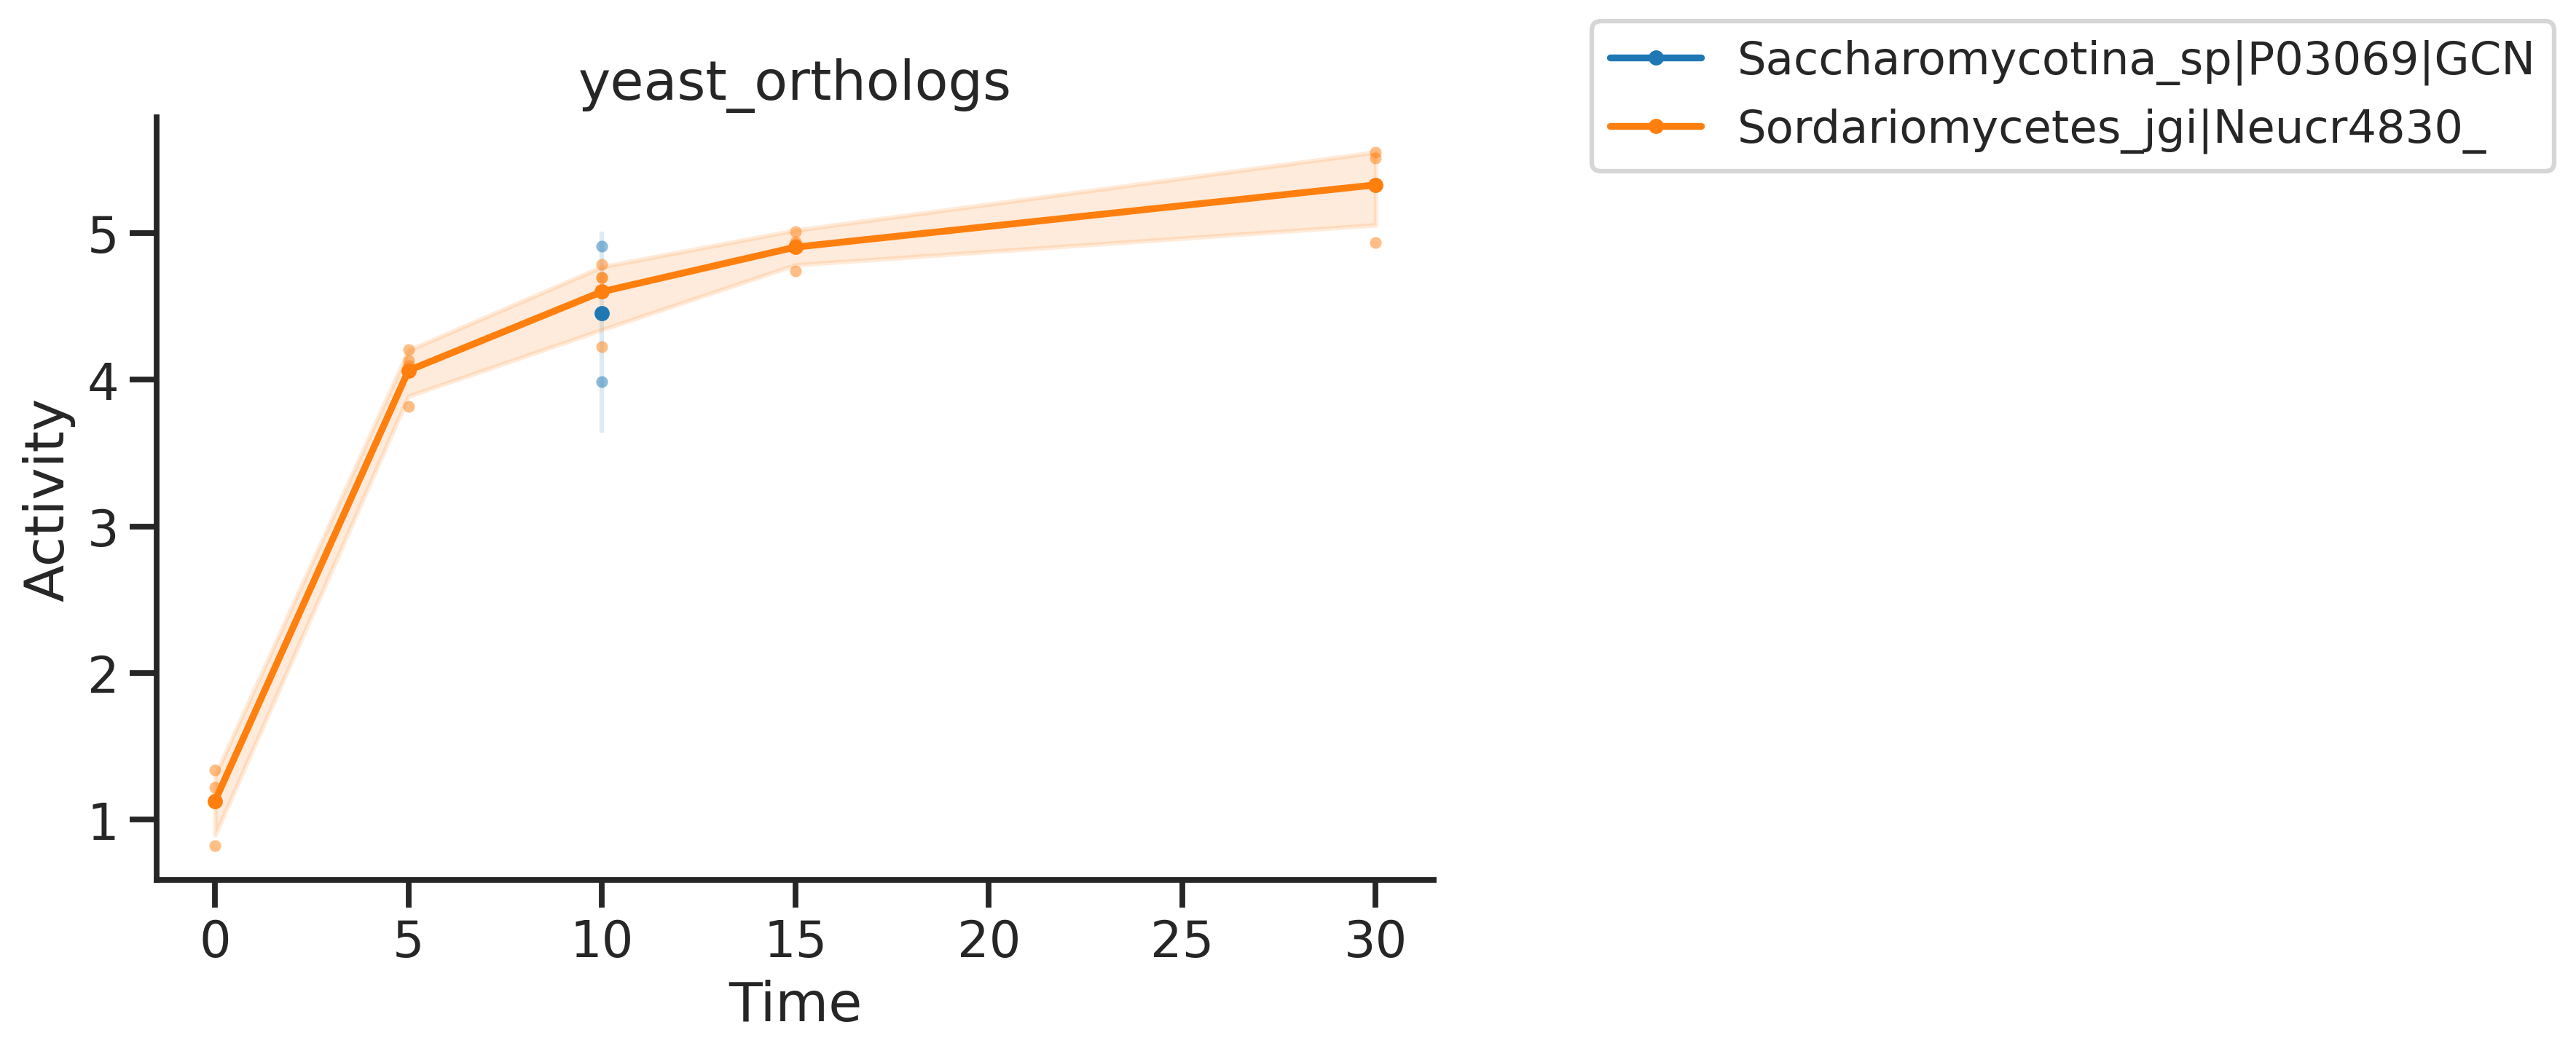

In [208]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks')
sns.set_context('talk')

df = chopTF_controls_meas  # your dataframe
df = df[df["time"] <= 30]

for group_name in df["group"].unique():

    sub = df[df["group"] == group_name].copy()

    fig, ax = plt.subplots(figsize=(7,5), dpi=300)

    # UNIQUE entity = Name + ADseq
    sub["plot_id"] = sub["Name"].astype(str) + " | " + sub["ADseq"].astype(str)

    palette = sns.color_palette("tab10", n_colors=sub["plot_id"].nunique())

    handles = []
    labels = []

    for i, (pid, subdf) in enumerate(sub.groupby("plot_id")):

        subdf = subdf.sort_values("time")

        x = subdf["time"]
        y = subdf["mean"]
        ylow = subdf["ci_low"]
        yhigh = subdf["ci_hi"]

        color = palette[i]

        # keep readable label (just Name)
        label = subdf["Name"].iloc[0]

        line, = ax.plot(x, y, color=color, marker='o', markersize=4)
        ax.fill_between(x, ylow, yhigh, color=color, alpha=0.15)

                # --- RAW SCATTER FROM df_filtered_grouped ---
        adseq = subdf["ADseq"].iloc[0]

        raw = df_filtered_grouped[
            df_filtered_grouped["ADseq"] == adseq
        ]

        ax.scatter(
            raw["time"],
            raw["shifted_activity"],
            color=color,
            alpha=0.5,   # light so it doesn't overpower
            s=15,         # small dots
            linewidth=0
        )

        handles.append(line)
        labels.append(label)

    ax.set_xlabel("Time")
    ax.set_ylabel("Activity")
    ax.set_title(group_name)

    fig.legend(
        handles,
        [l[:30] for l in labels],
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize='small',
        frameon=True
    )

    sns.despine()
    plt.tight_layout()
    plt.show()

In [209]:
df_diff[df_diff["ADseq"] == "SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA"]

,ADseq,time,mean,ci_low,ci_hi,boot_samples,n_barcodes,mean_t0,boot_t0,mean_diff,boot_diff,pval,neglog10p,pval_fdr,reject,class
19457,SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA,5,0.801904,-0.056724,1.492060,"[0.56009525, 0.25168574, 0.19159502, 0.9966423...",2,0.936299,"[0.7733059, 0.7296784, 0.6393994, 0.58972424, ...",-0.134395,"[-0.21321064233779907, -0.4779926538467407, -0...",0.6948,0.158140,0.803872,False,ns
19458,SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA,10,1.232008,0.937804,1.523255,"[1.0327085, 1.0117936, 0.97318697, 0.9587183, ...",2,0.936299,"[0.7733059, 0.7296784, 0.6393994, 0.58972424, ...",0.295709,"[0.25940263271331787, 0.28211522102355957, 0.3...",0.0001,4.000000,0.000222,True,activator
19459,SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA,15,1.118944,0.803792,1.396082,"[0.82519275, 0.8565513, 0.9406692, 1.0148293, ...",2,0.936299,"[0.7733059, 0.7296784, 0.6393994, 0.58972424, ...",0.182644,"[0.05188685655593872, 0.12687289714813232, 0.3...",0.2020,0.694649,0.283476,False,ns
19460,SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA,30,1.290153,0.888346,1.631454,"[1.0945582, 1.0939779, 1.0248536, 0.8883459, 1...",2,0.936299,"[0.7733059, 0.7296784, 0.6393994, 0.58972424, ...",0.353854,"[0.32125234603881836, 0.3642995357513428, 0.38...",0.0001,4.000000,0.000193,True,activator
19461,SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA,180,1.392334,1.081930,1.674922,"[1.2332641, 1.1955166, 1.1324892, 1.1196771, 1...",2,0.936299,"[0.7733059, 0.7296784, 0.6393994, 0.58972424, ...",0.456035,"[0.45995819568634033, 0.4658381938934326, 0.49...",0.0001,4.000000,0.000166,True,activator
19462,SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA,240,1.159838,0.802382,1.533678,"[0.8920697, 0.83896637, 0.82244766, 0.9487203,...",2,0.936299,"[0.7733059, 0.7296784, 0.6393994, 0.58972424, ...",0.223539,"[0.11876380443572998, 0.10928797721862793, 0.1...",0.0001,4.000000,0.000178,True,activator


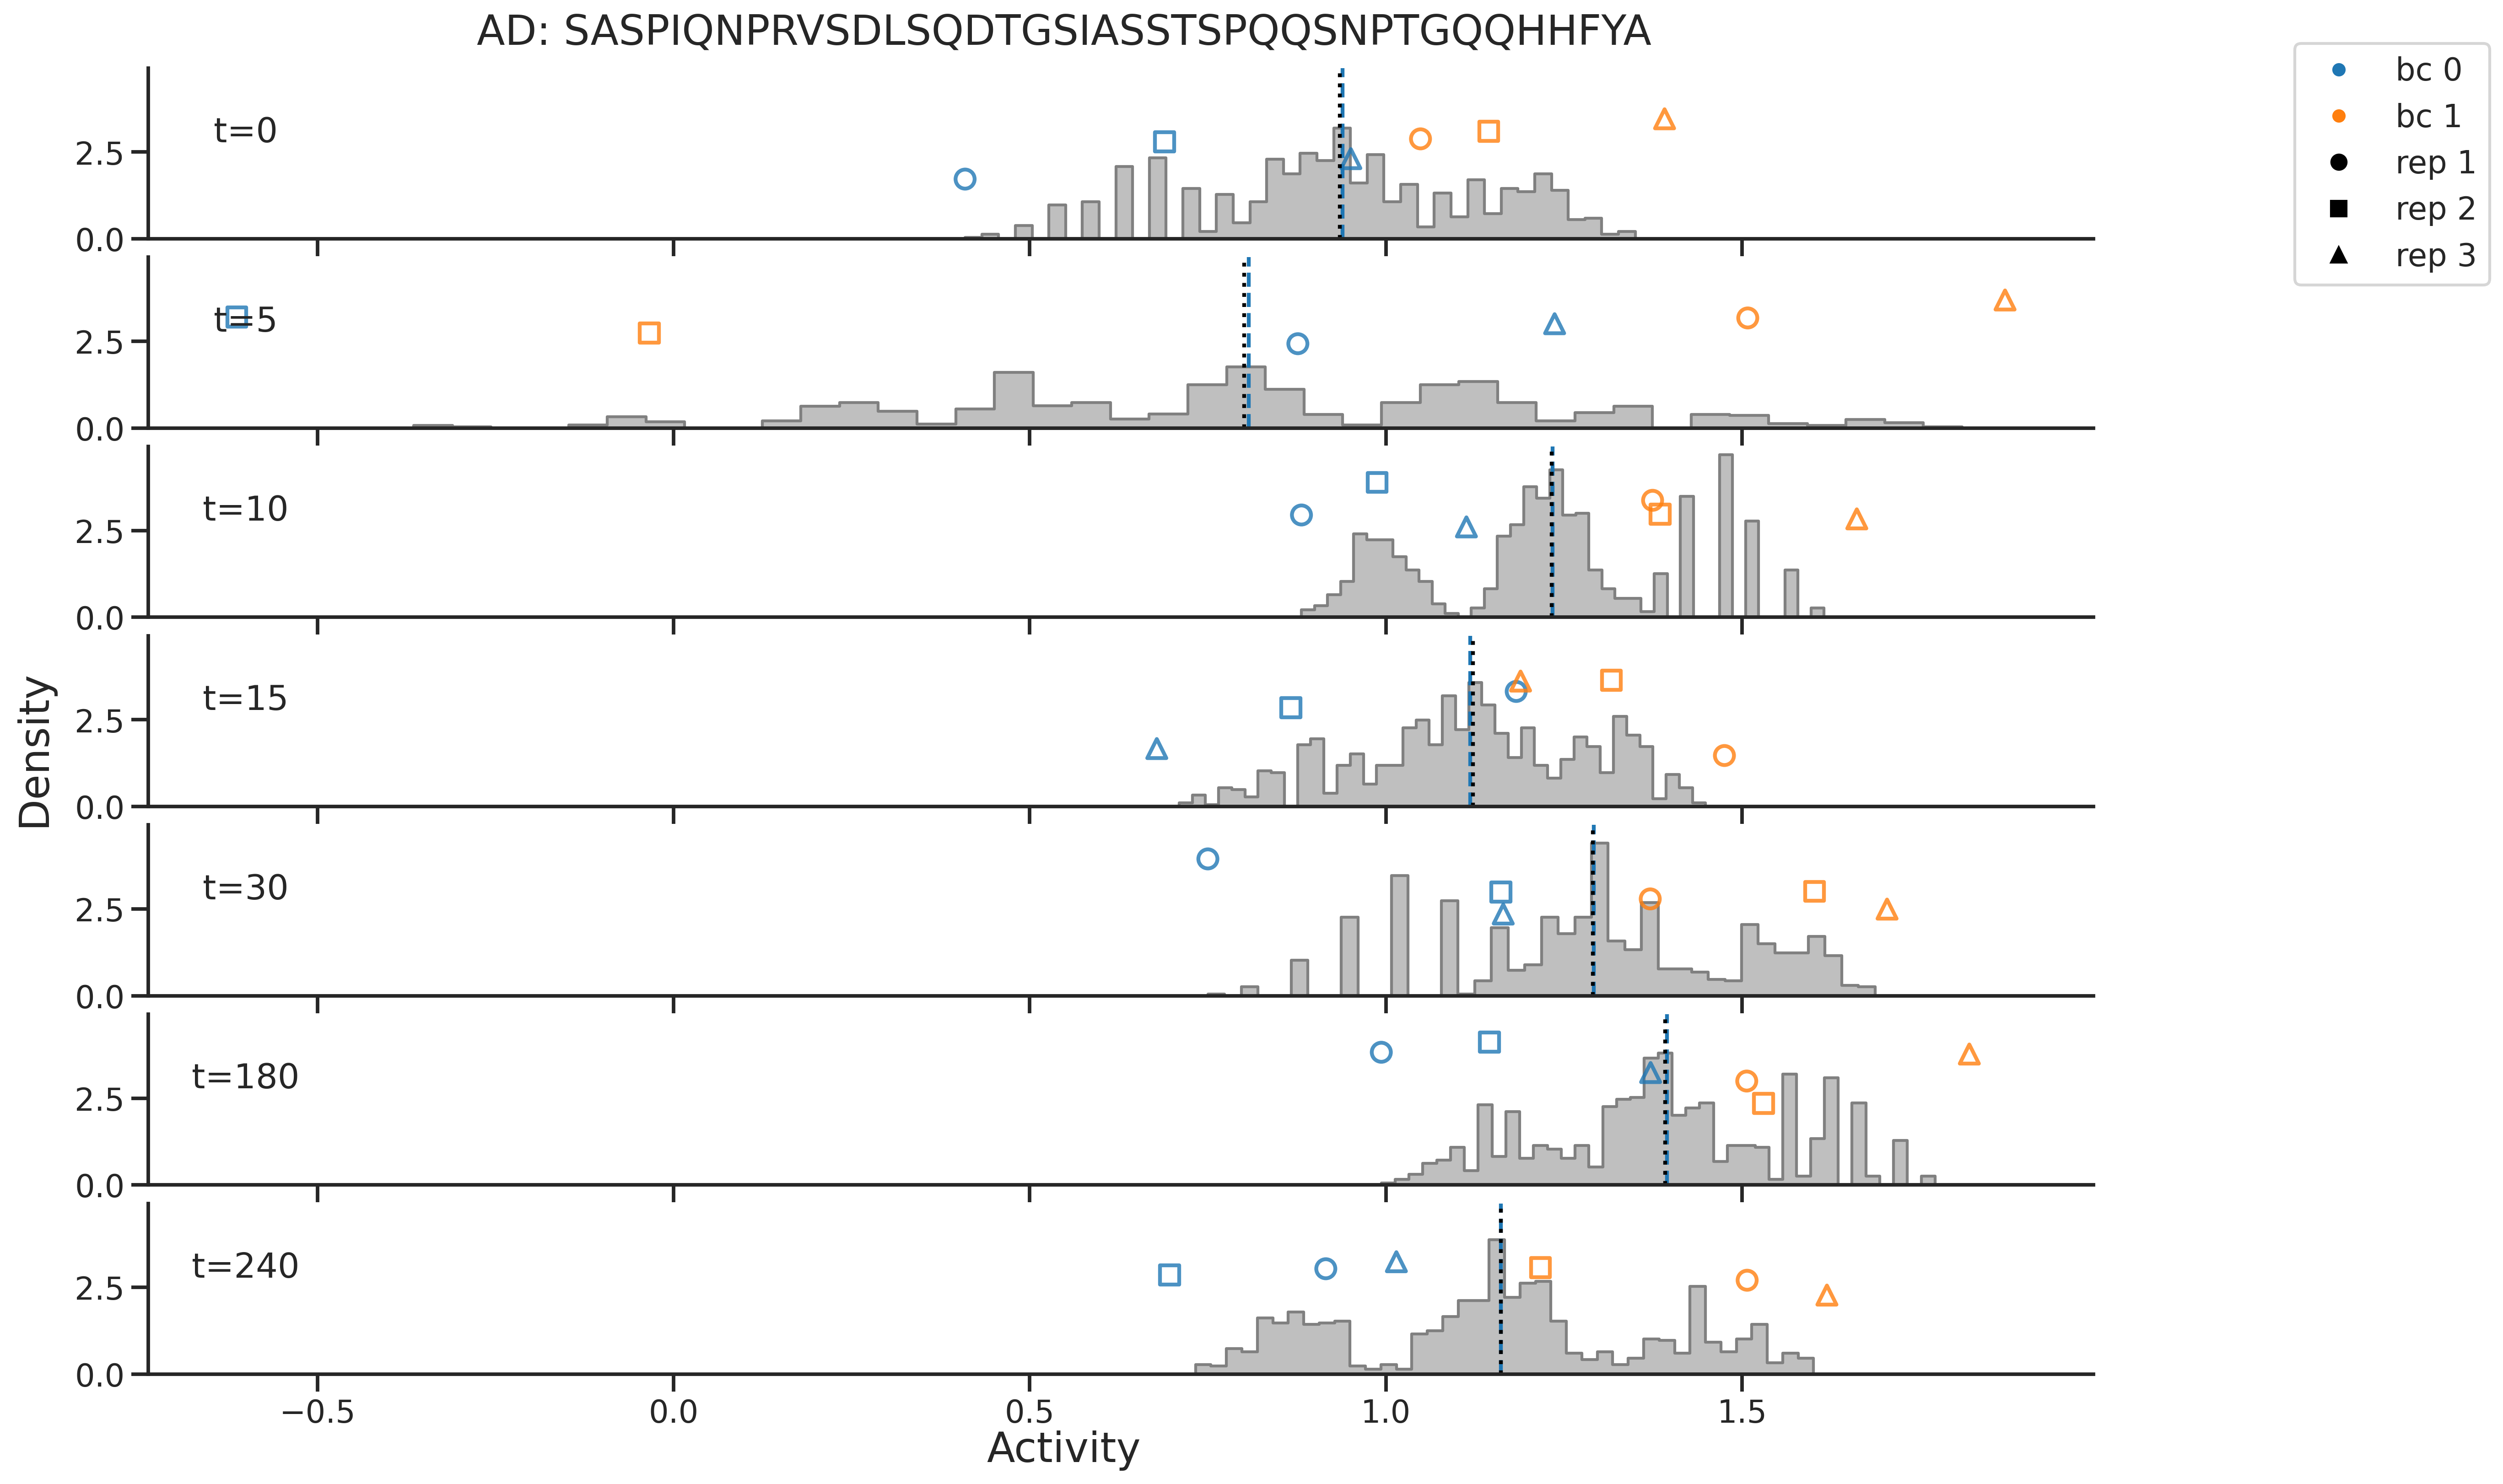

,ADseq,time,mean,ci_low,ci_hi,boot_samples,n_barcodes
0,SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA,0,0.935664,0.546097,1.277151,"[0.8075281, 0.98311293, 1.0267406, 0.9960706, ...",2
1,SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA,5,0.801051,-0.056724,1.628669,"[0.42990476, 0.5678229, 0.8762324, 0.86748815,...",2
2,SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA,10,1.232633,0.937804,1.565769,"[1.1492605, 1.2767124, 1.2976272, 1.2816957, 1...",2
3,SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA,15,1.122091,0.793834,1.396082,"[1.2235855, 1.075558, 1.0441993, 1.0705014, 0....",2
4,SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA,30,1.290470,0.887766,1.631454,"[1.2061692, 1.3771722, 1.3777525, 1.3476791, 1...",2
5,SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA,180,1.392149,1.081930,1.715175,"[1.2833848, 1.4302381, 1.4679856, 1.446653, 1....",2
6,SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA,240,1.161230,0.785863,1.552349,"[1.0782014, 1.1391106, 1.1922139, 1.1804307, 0...",2


In [210]:
AD = "SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA"
AD_df = df_filtered[df_filtered["ADseq"] ==AD]
_bootstrap_one_ad(AD, AD_df, 1000, 42, plot = True)

In [211]:
# 3. Look at how many bootstrap samples are actually > 0
row = df_diff_classified[
    (df_diff_classified["ADseq"] == "SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA") &
    (df_diff_classified["time"] == 30)
].iloc[0]
row

ADseq                    SASPIQNPRVSDLSQDTGSIASSTSPQQSNPTGQQHHFYA
time                                                           30
mean                                                     1.290153
ci_low                                                   0.888346
ci_hi                                                    1.631454
boot_samples    [1.0945582, 1.0939779, 1.0248536, 0.8883459, 1...
n_barcodes                                                      2
mean_t0                                                  0.936299
boot_t0         [0.7733059, 0.7296784, 0.6393994, 0.58972424, ...
mean_diff                                                0.353854
boot_diff       [0.32125234603881836, 0.3642995357513428, 0.38...
pval                                                       0.0001
neglog10p                                                     4.0
pval_fdr                                                 0.000193
reject                                                       True
class     

In [212]:
print(np.mean(row["boot_diff"] > 0))  # if this is 0.97 with wide distributions, that's the problem


1.0
